# Social Network Structure

### Setup and Functions

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import math
from networkx.readwrite import json_graph
import matplotlib.pyplot as plt
from scipy.stats import halfnorm
import random
import collections
from statistics import mean, median

random.seed(12345)
np.random.seed(12345)

import warnings
warnings.filterwarnings("ignore")

In [2]:
def get_connections_distribution_halfnormal(target_cdf, upper_bound, end_value):
    """
    Function to get a distribution for the number of connections. The underlying assumption is that most households have few connections, but there are some outliers. 
    This uses a half-normal distribution. 
    
    target_cdf: fraction of households that are supposed to have upper_bound or fewer connections
    upper_bound: value where target_cdf % of connections should be in.
    end_value: end of the tail. Maximum number of connections
    """
    
    # Solve for the scale parameter of the half-normal distribution
    scale = upper_bound / halfnorm.ppf(target_cdf)

    # Generate data points from the half-normal distribution
    x = np.linspace(0, end_value+1, end_value+1)  # Extend to the upper bound, +1 because we want it to still have the end_value 
    pdf = halfnorm.pdf(x, scale=scale)
    pdf = np.array(pdf)
    #probabilities /= pdf.sum()
    return pdf, x

In [3]:
def construct_network(probability_distribution, max_connections, nr_nodes):
    """
    Function to make the network graph given a probability distribution. 
    
    probability_distribution: probability distribution of the node degree
    max_connections: maximun number of connections an agent can have
    nr_nodes: number of nodes wanted for the network
    """
    # get connection values from the probability distribution
    p = np.array(probability_distribution)
    p /= p.sum()  # normalize
    values = np.random.choice(max_connections+1, nr_nodes, p = p) # get values in that distribution
    if sum(values) % 2 == 0:
        pass
    elif sum(values) % 2 != 0: # remove a random odd number from the array so it gets an even sum
        odd_indices = np.where(values % 2 != 0)[0] # find all odd numbers in array
        values = np.delete(values, random.choice(odd_indices)) # remove the a random odd number from the vlaues
    # generate graph based on the values
    G = nx.configuration_model(values)
    G = nx.Graph(G)  # Remove parallel edges and self-loops created by the configuration model
    G.remove_edges_from(nx.selfloop_edges(G)) # remove self-loops
    # Verify the degree distribution
    actual_degrees = [d for _, d in G.degree()]
    return G, actual_degrees

In [4]:
# Rewire edges to enforce preferential attachment based on degree similarity
def rewire_for_preferential_attachment(graph, iterations=5000):
    nodes = list(graph.nodes())
    for _ in range(iterations):
        # Randomly select two edges (u1, v1) and (u2, v2)
        edge1 = random.choice(list(graph.edges()))
        edge2 = random.choice(list(graph.edges()))
        
        u1, v1 = edge1
        u2, v2 = edge2
        
        # Ensure the edges are distinct 
        if u1 != u2 and u1 != v2 and v1 != u2 and v1 != v2:
            # Calculate the degree similarity for the current and potential edges
            current_similarity = abs(graph.degree(u1) - graph.degree(v1)) + abs(graph.degree(u2) - graph.degree(v2))
            potential_similarity = abs(graph.degree(u1) - graph.degree(u2)) + abs(graph.degree(v1) - graph.degree(v2))
            
            # Rewire if the proposed edges have a better (ie more similar) degree similarity
            if potential_similarity < current_similarity:
                graph.remove_edges_from([edge1, edge2])
                graph.add_edges_from([(u1, u2), (v1, v2)])

In [5]:
network_data = pd.DataFrame(columns = ['nr_nodes', 'nr_edges', 'avg_degree', 'avg_clustering', 'density', 'nr_connected_components', 'diameter_connected_components'],
                            index = ['SN1', 'SN2', 'SN3', 'SN4', 'SN5', 'empirical'])
network_data

,nr_nodes,nr_edges,avg_degree,avg_clustering,density,nr_connected_components,diameter_connected_components
SN1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SN2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SN3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SN4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SN5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
empirical,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Social Network 1

In [6]:
# network structure related
max_nr_connections = 20
perc_until_what_nr_conn = 0.8
most_conn_below = 3
nr_households = 1000

In [7]:
pdf, x_linspace = get_connections_distribution_halfnormal(perc_until_what_nr_conn, most_conn_below, max_nr_connections)
social_network_1, degrees_1 = construct_network(pdf, max_nr_connections, nr_households)

# if not enough nodes, add a random, unconnected node
if social_network_1.number_of_nodes() < nr_households:
    nodes_missing = nr_households - social_network_1.number_of_nodes()
    for n in range(nodes_missing):
        social_network_1.add_node(social_network_1.number_of_nodes()+1)
if social_network_1.number_of_nodes() != nr_households:
    raise ValueError('The number of households and number of nodes of the network are not equal.')
print(social_network_1)

# Rewire the graph
rewire_for_preferential_attachment(social_network_1)

Graph with 1000 nodes and 739 edges


In [ ]:
network_data['nr_nodes']['SN1'] = social_network_1.number_of_nodes()
network_data['nr_edges']['SN1'] = social_network_1.number_of_edges()
network_data

,nr_nodes,nr_edges,avg_degree,avg_clustering,density,nr_connected_components,diameter_connected_components
SN1,1000,729,NaN,NaN,NaN,NaN,NaN
SN2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SN3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SN4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SN5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
empirical,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
nx.write_graphml(social_network_1, "../../data/processed/network_structures/social_network1.graphml")

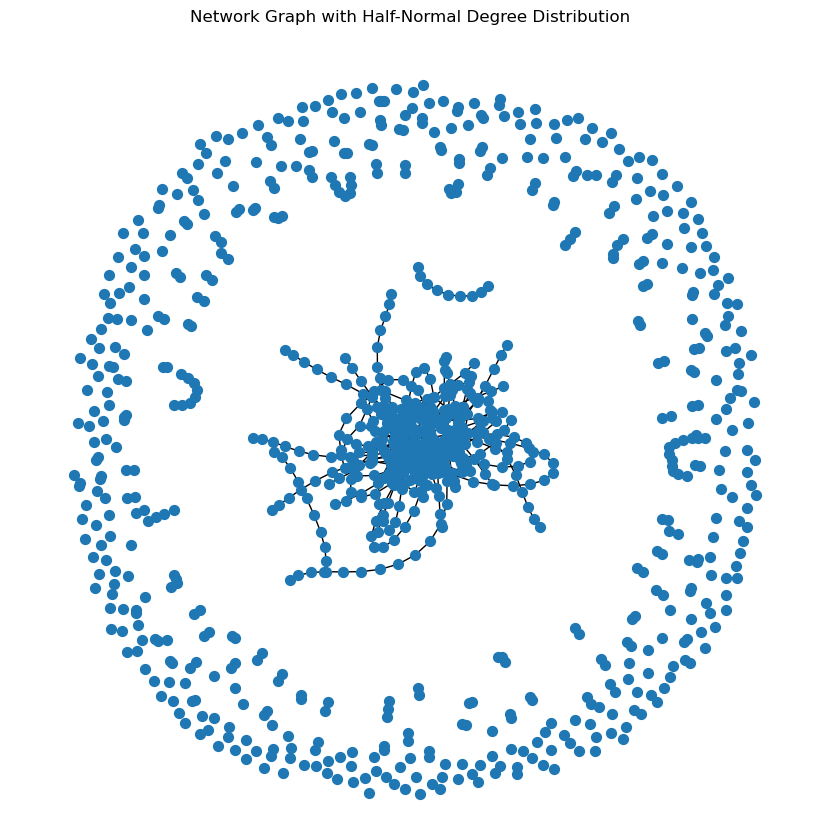

In [ ]:
''' Plot of network structure'''
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(social_network_1)  # Use a spring layout for visualization
nx.draw(social_network_1, pos, node_size=50, with_labels=False)
plt.title("Network Graph with Half-Normal Degree Distribution")
plt.show()

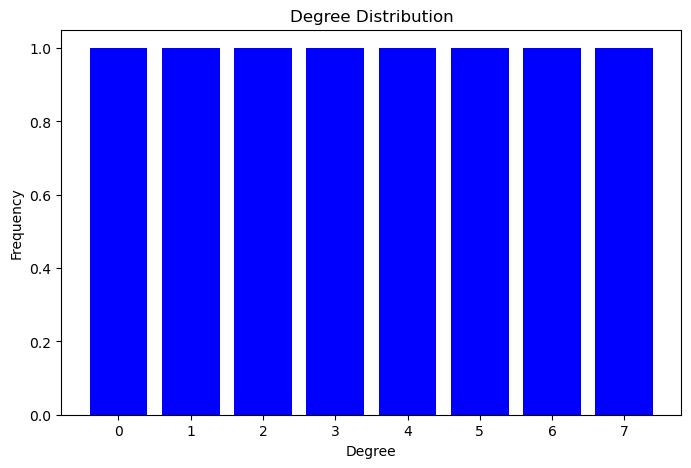

In [ ]:
''' Plot of degree distribution'''
plt.figure(figsize=(8, 5))
degree_count = collections.Counter(degrees_1)
degrees_1, counts = zip(*degree_count.items())
plt.bar(degrees_1, counts, color = 'b')
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.savefig('../../reports/figures/network_structure/degree_distribution_SN1.png')
plt.show()

In [ ]:
num_nodes = social_network_1.number_of_nodes()
num_edges = social_network_1.number_of_edges()
is_directed = nx.is_directed(social_network_1)

In [ ]:
num_connected_components = nx.number_connected_components(social_network_1) if not is_directed else nx.number_strongly_connected_components(social_network_1)
network_data['nr_connected_components']['SN1'] = num_connected_components
num_connected_components

418

In [ ]:
connected_components = list(nx.connected_components(social_network_1)) if not is_directed else list(nx.strongly_connected_components(social_network_1))
connected_components

[{0,
  5,
  6,
  7,
  9,
  10,
  11,
  15,
  16,
  17,
  18,
  21,
  25,
  26,
  27,
  28,
  31,
  32,
  36,
  38,
  39,
  40,
  42,
  48,
  53,
  54,
  58,
  59,
  65,
  66,
  68,
  69,
  70,
  71,
  73,
  77,
  79,
  80,
  83,
  87,
  88,
  91,
  92,
  93,
  95,
  97,
  98,
  102,
  105,
  106,
  107,
  109,
  110,
  112,
  115,
  118,
  120,
  124,
  125,
  132,
  133,
  134,
  135,
  137,
  138,
  140,
  141,
  145,
  147,
  150,
  151,
  155,
  156,
  157,
  159,
  163,
  164,
  165,
  166,
  167,
  168,
  169,
  170,
  172,
  173,
  174,
  176,
  177,
  178,
  182,
  185,
  187,
  190,
  191,
  200,
  203,
  207,
  208,
  210,
  213,
  214,
  217,
  223,
  226,
  227,
  228,
  229,
  238,
  239,
  241,
  245,
  247,
  249,
  251,
  252,
  253,
  257,
  260,
  261,
  262,
  264,
  266,
  269,
  270,
  273,
  276,
  277,
  278,
  280,
  283,
  284,
  289,
  296,
  297,
  301,
  303,
  305,
  307,
  308,
  312,
  316,
  319,
  322,
  324,
  326,
  330,
  332,
  334,
  335,
  340,
  

In [ ]:
degree_sequence = [d for n, d in social_network_1.degree()]
avg_degree = sum(degree_sequence) / num_nodes
network_data['avg_degree']['SN1'] = avg_degree
avg_degree

1.458

In [ ]:
avg_clustering = nx.average_clustering(social_network_1)
network_data['avg_clustering']['SN1'] = avg_clustering
avg_clustering

0.0028476190476190476

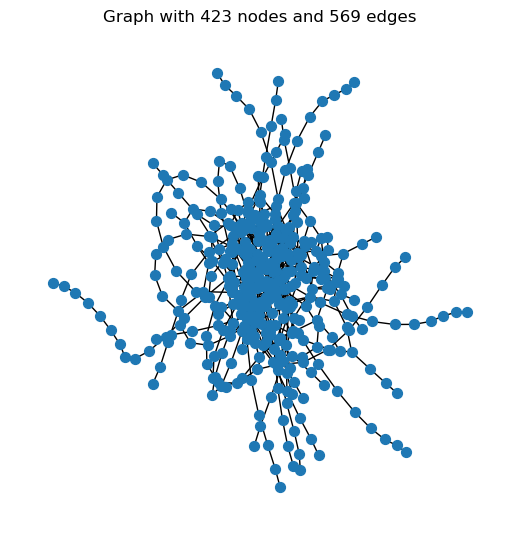

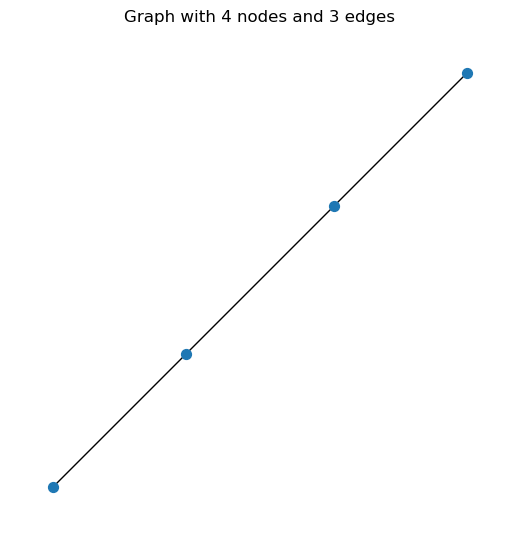

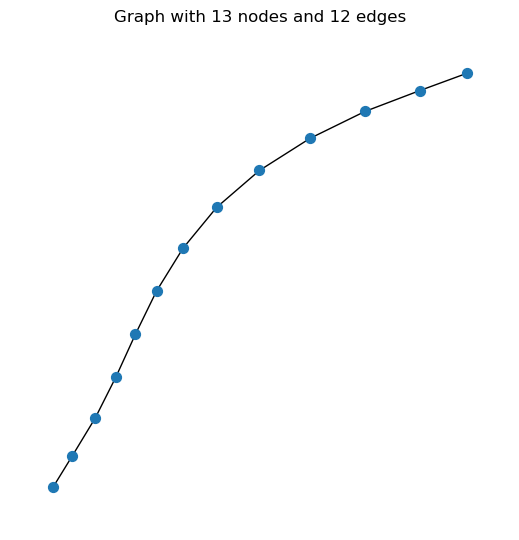

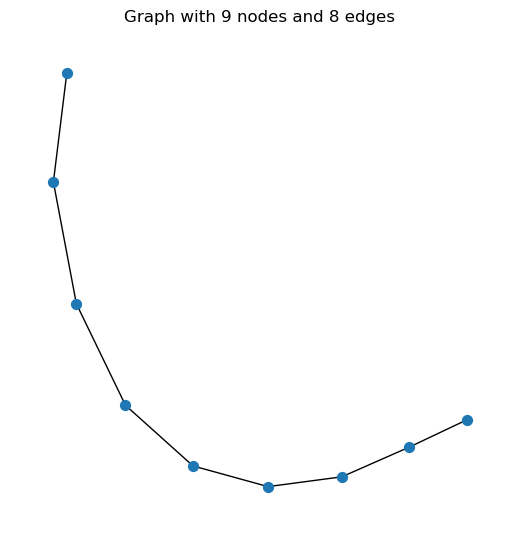

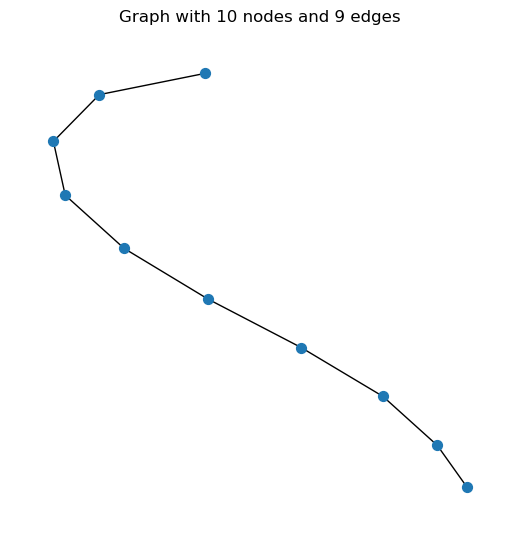

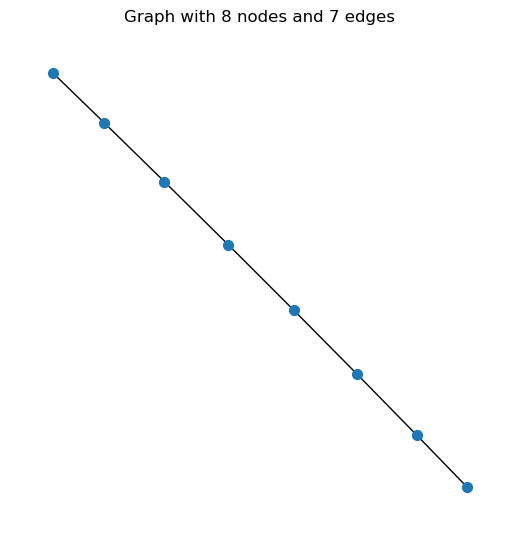

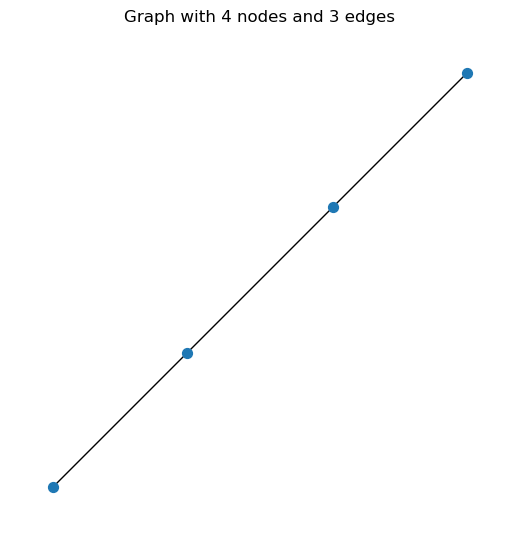

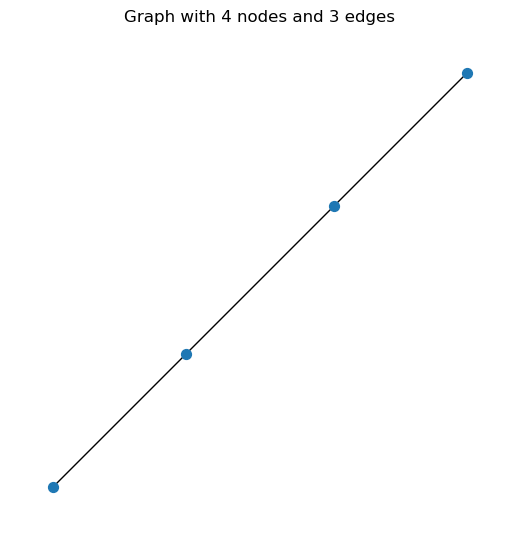

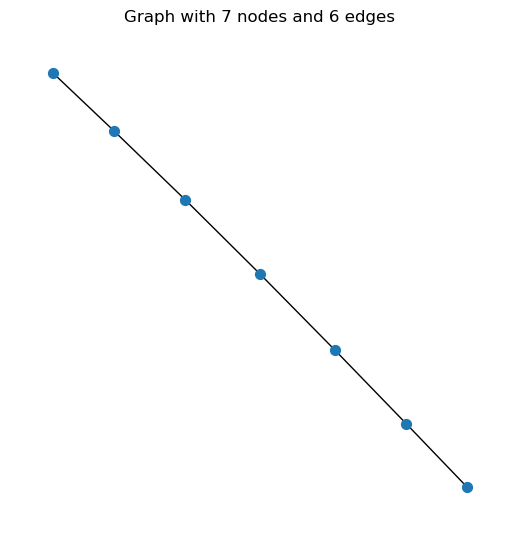

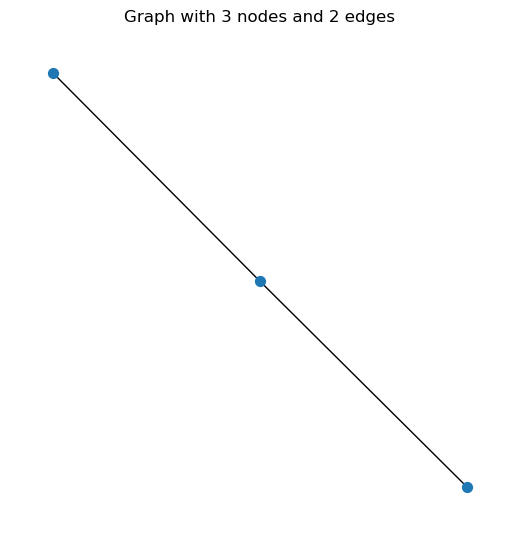

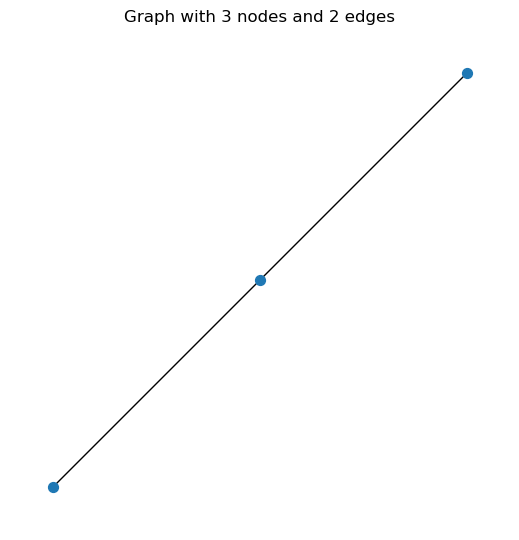

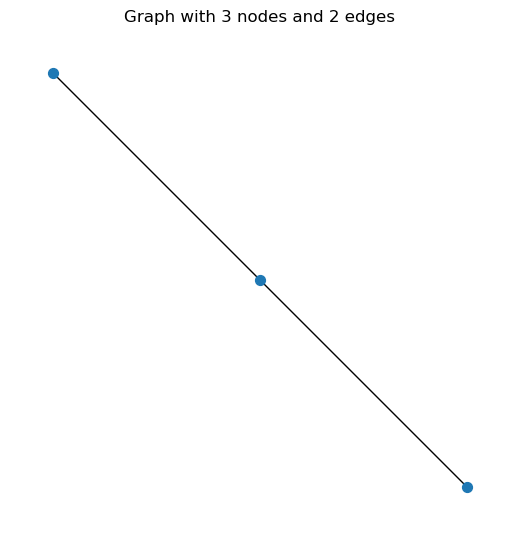

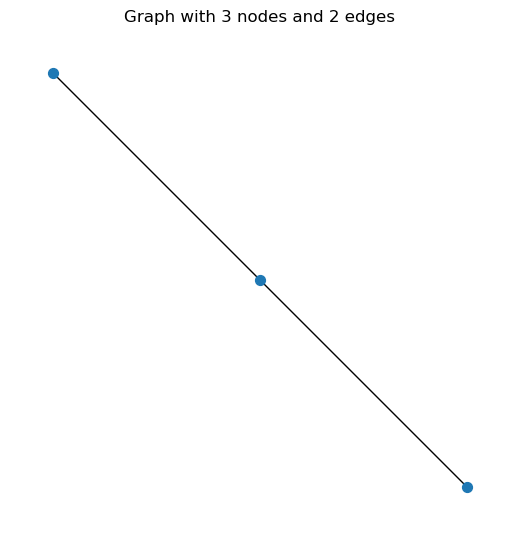

In [ ]:
diameters = []
for component in connected_components:
    subgraph = social_network_1.subgraph(component)
    if subgraph.number_of_nodes() > 2:
        plt.figure(figsize=(5, 5))
        pos = nx.spring_layout(subgraph)  # Use a spring layout for visualization
        nx.draw(subgraph, node_size=50, with_labels=False)
        plt.title(subgraph)
        plt.show()
        #print(subgraph)
    if nx.is_connected(subgraph):  # Ensure the subgraph is connected
        diameters.append(nx.diameter(subgraph))

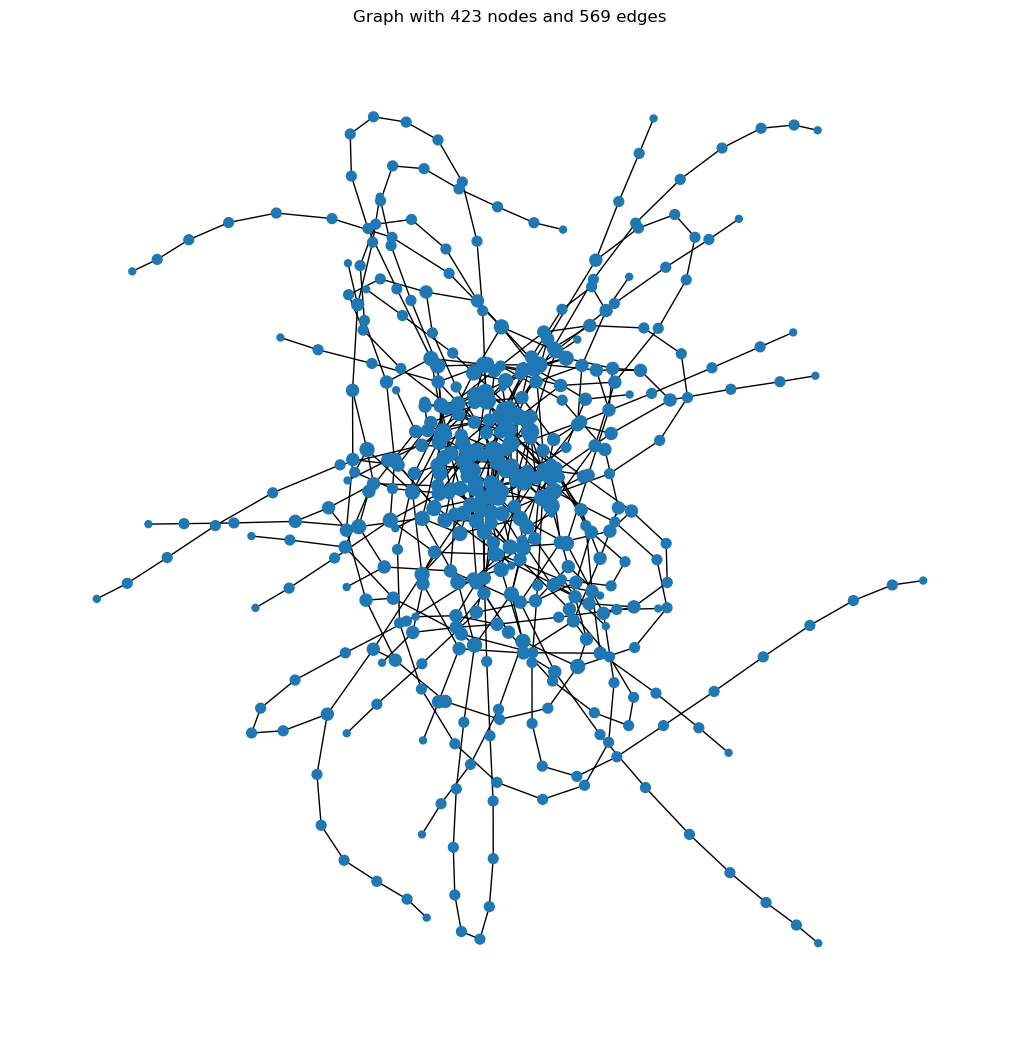

In [ ]:
for component in connected_components:
    subgraph = social_network_1.subgraph(component)
    if subgraph.number_of_nodes() > 20:
        plt.figure(figsize=(10, 10))
        degrees = dict(subgraph.degree())
        node_size = [v * 25 for v in degrees.values()]
        nx.draw(subgraph, pos = nx.spring_layout(subgraph), node_size=node_size, with_labels=False) # spectral_layout, spring_layout, kamada_kawai_layout
        plt.title(subgraph)
        plt.savefig('../../reports/figures/network_structure/biggest_component_SN1.png')
        plt.show()
    

In [ ]:
network_data['diameter_connected_components']['SN1'] = collections.Counter(diameters)
collections.Counter(diameters)

Counter({0: 304, 1: 101, 2: 4, 3: 3, 27: 1, 12: 1, 8: 1, 9: 1, 7: 1, 6: 1})

In [ ]:
density = nx.density(social_network_1)
network_data['density']['SN1'] = density
density

0.0014594594594594594

In [ ]:
degree_centrality = nx.degree_centrality(social_network_1)
degree_centrality

{0: 0.004004004004004004,
 1: 0.001001001001001001,
 2: 0.0,
 3: 0.0,
 4: 0.001001001001001001,
 5: 0.002002002002002002,
 6: 0.004004004004004004,
 7: 0.002002002002002002,
 8: 0.002002002002002002,
 9: 0.002002002002002002,
 10: 0.002002002002002002,
 11: 0.004004004004004004,
 12: 0.0,
 13: 0.0,
 14: 0.0,
 15: 0.002002002002002002,
 16: 0.003003003003003003,
 17: 0.003003003003003003,
 18: 0.003003003003003003,
 19: 0.002002002002002002,
 20: 0.002002002002002002,
 21: 0.002002002002002002,
 22: 0.001001001001001001,
 23: 0.001001001001001001,
 24: 0.001001001001001001,
 25: 0.002002002002002002,
 26: 0.006006006006006006,
 27: 0.002002002002002002,
 28: 0.003003003003003003,
 29: 0.0,
 30: 0.0,
 31: 0.003003003003003003,
 32: 0.003003003003003003,
 33: 0.0,
 34: 0.001001001001001001,
 35: 0.001001001001001001,
 36: 0.002002002002002002,
 37: 0.0,
 38: 0.003003003003003003,
 39: 0.002002002002002002,
 40: 0.003003003003003003,
 41: 0.001001001001001001,
 42: 0.003003003003003003,
 4

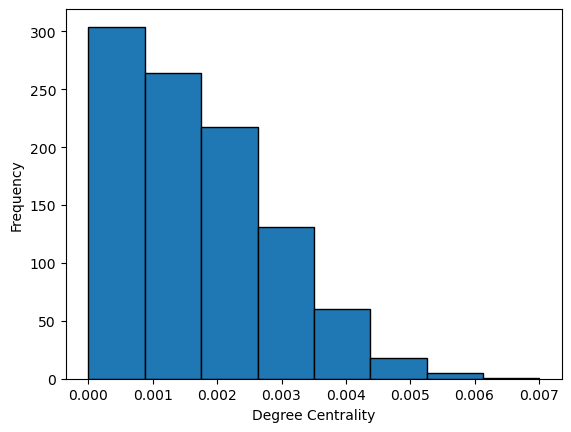

In [ ]:
# Extract the values from the dictionary
values = list(degree_centrality.values())

# Create the histogram
plt.hist(values, bins=8, edgecolor='black')  # You can adjust the number of bins as needed

# Add labels and title
plt.xlabel('Degree Centrality')
plt.ylabel('Frequency')

plt.savefig('../../reports/figures/network_structure/degree_centrality_distribution_SN1.png')
# Show the plot
plt.show()

In [ ]:
betweenness_centrality = nx.betweenness_centrality(social_network_1)
betweenness_centrality

{0: 0.0016356288040178693,
 1: 0.0,
 2: 0.0,
 3: 0.0,
 4: 0.0,
 5: 0.000549393257030754,
 6: 0.010091727574732806,
 7: 0.0006974233705473975,
 8: 4.0120280601242526e-06,
 9: 0.001685051785252186,
 10: 0.0005521386449910162,
 11: 0.006403796845791947,
 12: 0.0,
 13: 0.0,
 14: 0.0,
 15: 0.001685051785252186,
 16: 0.0032852328888846385,
 17: 0.0027128649150470565,
 18: 0.0010476300445126996,
 19: 7.021049105217442e-05,
 20: 2.4072168360745514e-05,
 21: 0.0012348410923338547,
 22: 0.0,
 23: 0.0,
 24: 0.0,
 25: 0.0014556298067765435,
 26: 0.01092466027892436,
 27: 0.001399746439826598,
 28: 0.001763608454768552,
 29: 0.0,
 30: 0.0,
 31: 0.0042674475094871414,
 32: 0.0018530300594428852,
 33: 0.0,
 34: 0.0,
 35: 0.0,
 36: 0.0066439184675657625,
 37: 0.0,
 38: 0.0015447385799200535,
 39: 0.003354055458263875,
 40: 0.003011035241836711,
 41: 0.0,
 42: 0.0032058183527789406,
 43: 0.0,
 44: 0.0,
 45: 0.0,
 46: 0.0,
 47: 0.0,
 48: 0.0008445319066561551,
 49: 0.0,
 50: 0.0,
 51: 0.0,
 52: 0.0,
 53

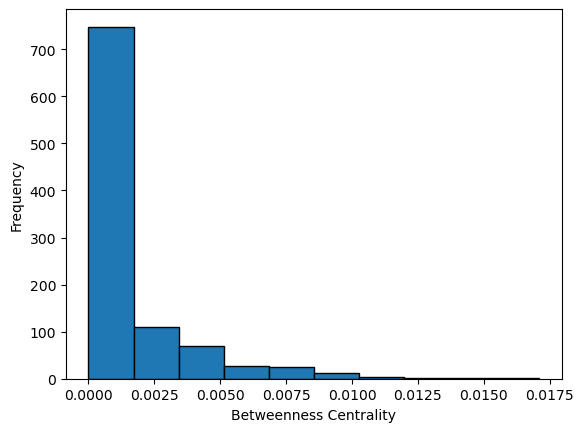

In [ ]:
# Extract the values from the dictionary
values = list(betweenness_centrality.values())

# Create the histogram
plt.hist(values, bins=10, edgecolor='black')  # You can adjust the number of bins as needed

# Add labels and title
plt.xlabel('Betweenness Centrality')
plt.ylabel('Frequency')

plt.savefig('../../reports/figures/network_structure/betweenness_centrality_distribution_SN1.png')
# Show the plot
plt.show()

## Social Network 2

In [28]:
# network structure related
max_nr_connections = 20
perc_until_what_nr_conn = 0.6
most_conn_below = 2
nr_households = 1000

In [29]:
pdf, x_linspace = get_connections_distribution_halfnormal(perc_until_what_nr_conn, most_conn_below, max_nr_connections)
social_network_2, degrees_2 = construct_network(pdf, max_nr_connections, nr_households)

# if not enough nodes, add a random, unconnected node
if social_network_2.number_of_nodes() < nr_households:
    nodes_missing = nr_households - social_network_2.number_of_nodes()
    for n in range(nodes_missing):
        social_network_2.add_node(social_network_2.number_of_nodes()+1)
if social_network_2.number_of_nodes() != nr_households:
    raise ValueError('The number of households and number of nodes of the network are not equal.')
print(social_network_2)

# Rewire the graph
rewire_for_preferential_attachment(social_network_2)

Graph with 1000 nodes and 736 edges


In [30]:
network_data['nr_nodes']['SN2'] = social_network_2.number_of_nodes()
network_data['nr_edges']['SN2'] = social_network_2.number_of_edges()
network_data

,nr_nodes,nr_edges,avg_degree,avg_clustering,density,nr_connected_components,diameter_connected_components
SN1,1000,729,1.458,0.002848,0.001459,418,"{27: 1, 1: 101, 0: 304, 3: 3, 12: 1, 8: 1, 9: ..."
SN2,1000,735,NaN,NaN,NaN,NaN,NaN
SN3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SN4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SN5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
empirical,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
nx.write_graphml(social_network_2, "../../data/processed/network_structures/social_network2.graphml")

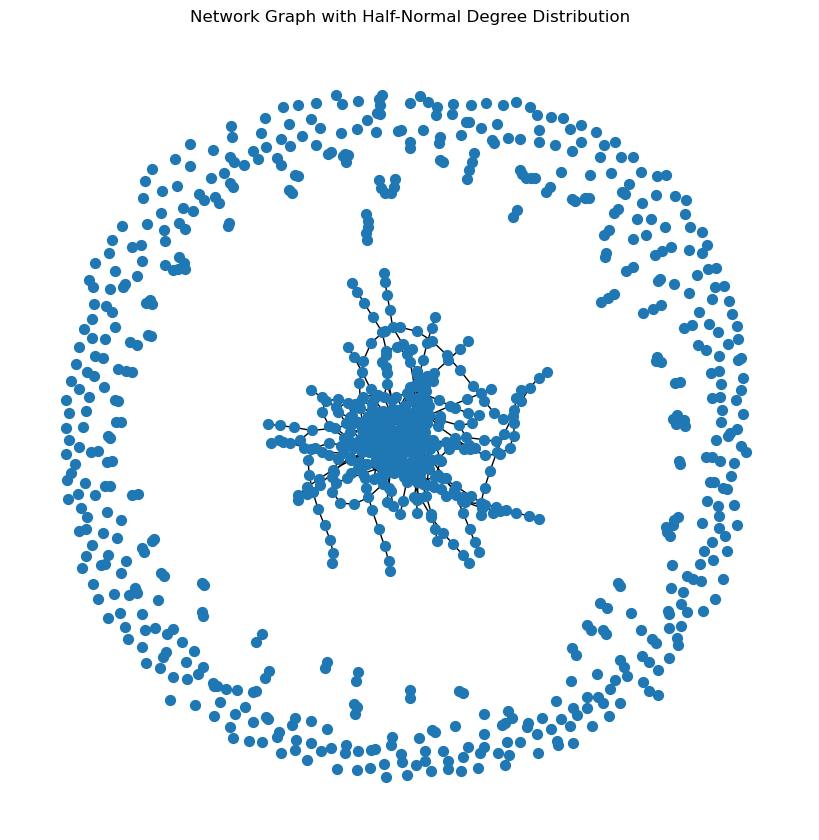

In [32]:
''' Plot of network structure'''
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(social_network_2)  # Use a spring layout for visualization
nx.draw(social_network_2, pos, node_size=50, with_labels=False)
plt.title("Network Graph with Half-Normal Degree Distribution")
plt.show()

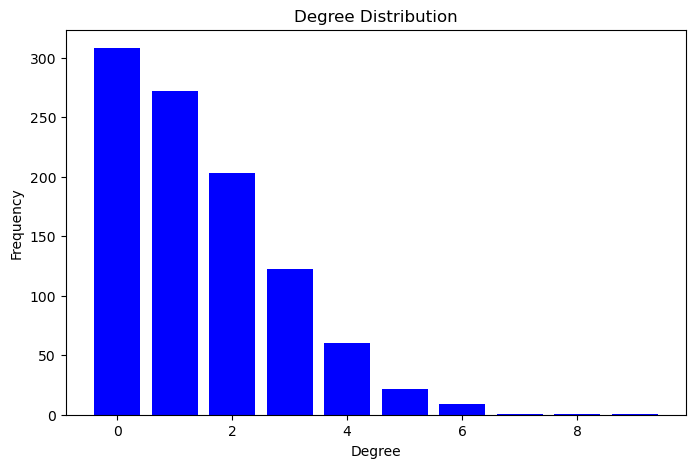

In [33]:
''' Plot of degree distribution'''
plt.figure(figsize=(8, 5))
degree_count = collections.Counter(degrees_2)
degrees_2, counts = zip(*degree_count.items())
plt.bar(degrees_2, counts, color = 'b')
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.savefig('../../reports/figures/network_structure/degree_distribution_SN2.png')
plt.show()

In [34]:
num_nodes = social_network_2.number_of_nodes()
num_edges = social_network_2.number_of_edges()
is_directed = nx.is_directed(social_network_2)

In [35]:
num_connected_components = nx.number_connected_components(social_network_2) if not is_directed else nx.number_strongly_connected_components(social_network_2)
network_data['nr_connected_components']['SN2'] = num_connected_components
num_connected_components

421

In [36]:
connected_components = list(nx.connected_components(social_network_2)) if not is_directed else list(nx.strongly_connected_components(social_network_2))
connected_components

[{0},
 {1,
  3,
  5,
  8,
  9,
  11,
  12,
  16,
  17,
  18,
  22,
  23,
  28,
  29,
  36,
  37,
  40,
  41,
  43,
  45,
  46,
  47,
  49,
  50,
  51,
  52,
  58,
  61,
  63,
  64,
  65,
  67,
  68,
  69,
  72,
  75,
  76,
  77,
  78,
  80,
  81,
  83,
  84,
  90,
  93,
  96,
  98,
  100,
  103,
  107,
  109,
  113,
  118,
  119,
  123,
  124,
  125,
  126,
  127,
  133,
  135,
  136,
  147,
  149,
  152,
  157,
  158,
  159,
  164,
  166,
  172,
  174,
  175,
  176,
  177,
  179,
  187,
  188,
  189,
  190,
  195,
  197,
  201,
  202,
  203,
  204,
  205,
  208,
  209,
  213,
  216,
  217,
  219,
  221,
  223,
  225,
  226,
  230,
  234,
  235,
  236,
  238,
  239,
  240,
  247,
  252,
  257,
  258,
  260,
  261,
  263,
  265,
  266,
  267,
  268,
  269,
  273,
  278,
  283,
  284,
  285,
  289,
  292,
  297,
  298,
  300,
  302,
  303,
  305,
  307,
  308,
  309,
  313,
  315,
  318,
  319,
  321,
  322,
  324,
  325,
  326,
  332,
  333,
  334,
  336,
  340,
  341,
  345,
  346,
  3

In [37]:
degree_sequence = [d for n, d in social_network_2.degree()]
avg_degree = sum(degree_sequence) / num_nodes
network_data['avg_degree']['SN2'] = avg_degree
avg_degree

1.47

In [38]:
avg_clustering = nx.average_clustering(social_network_2)
network_data['avg_clustering']['SN2'] = avg_clustering
avg_clustering

0.005042063492063492

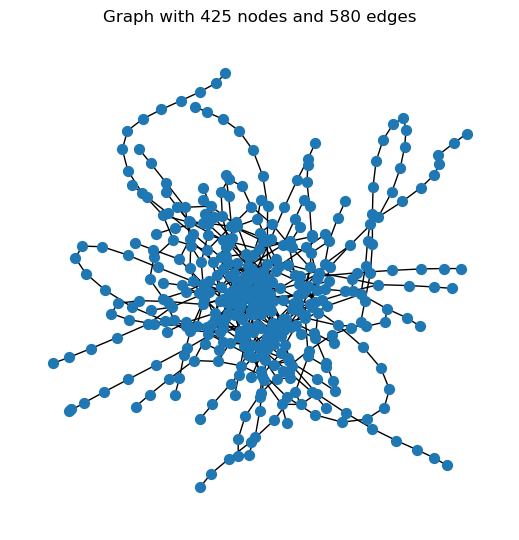

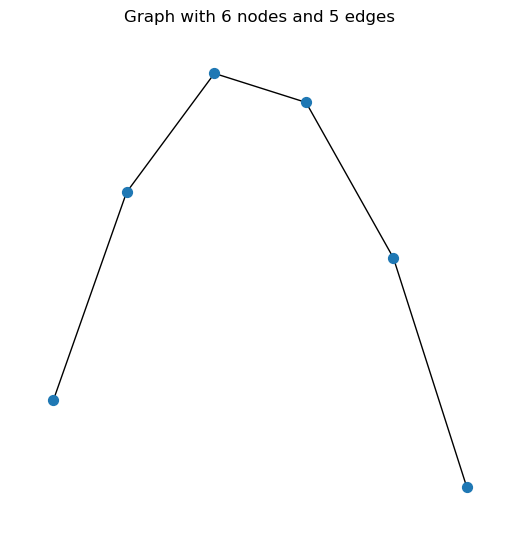

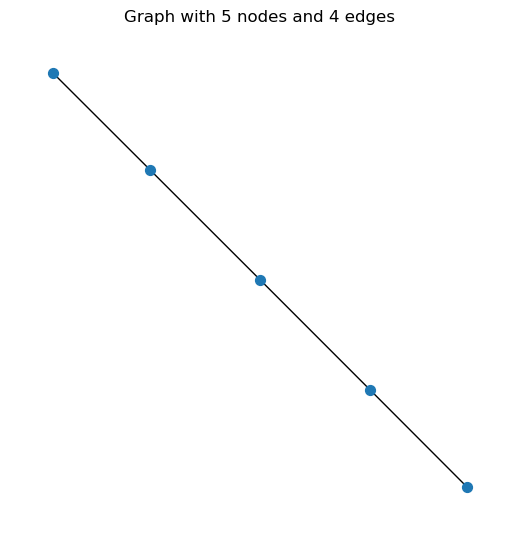

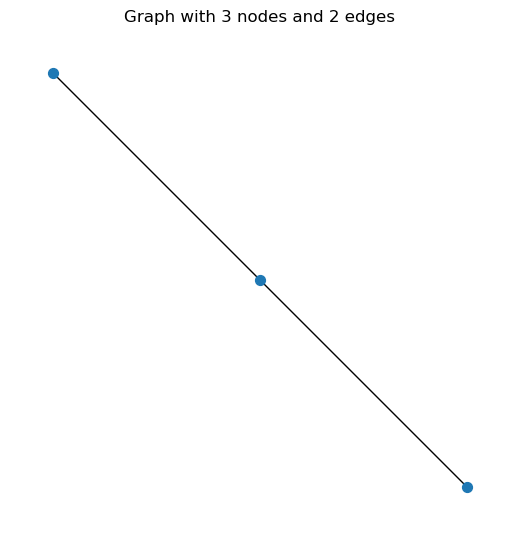

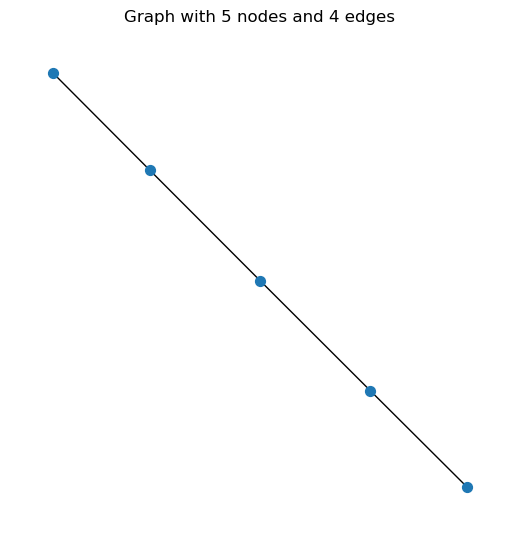

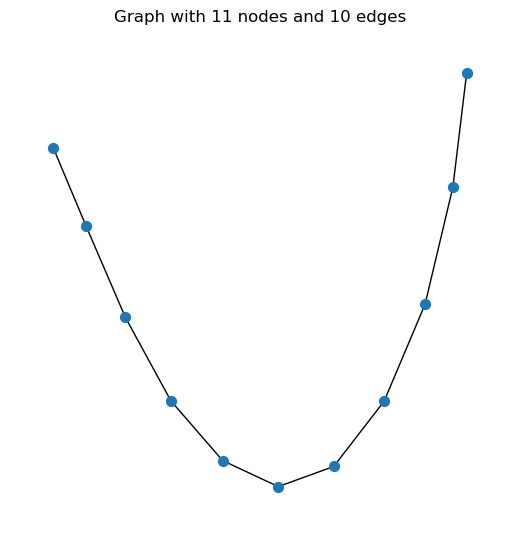

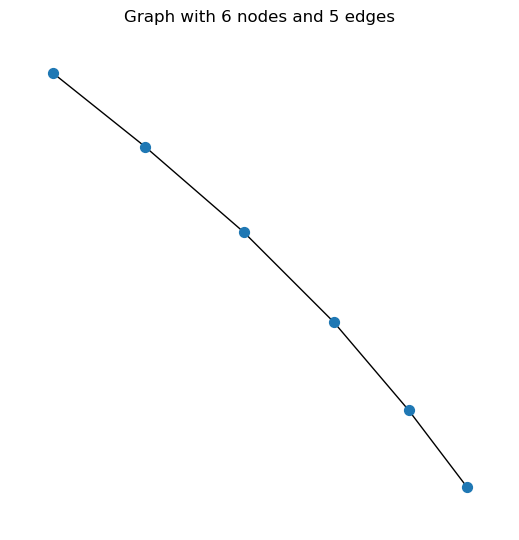

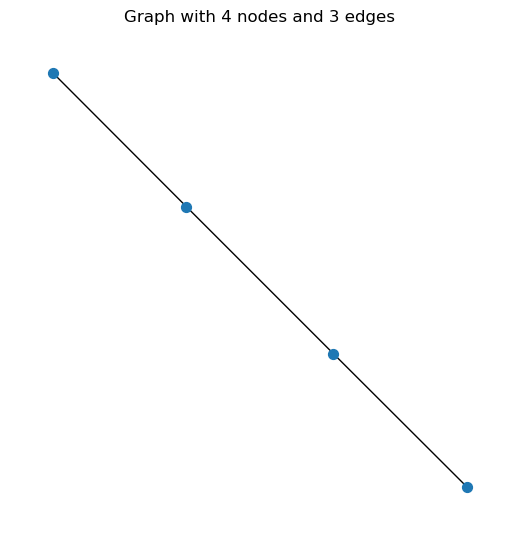

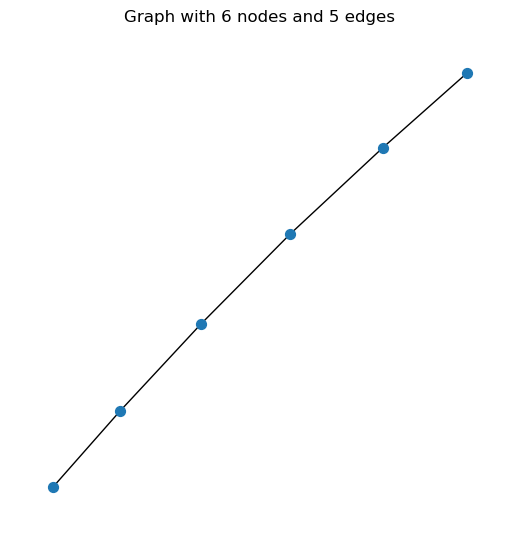

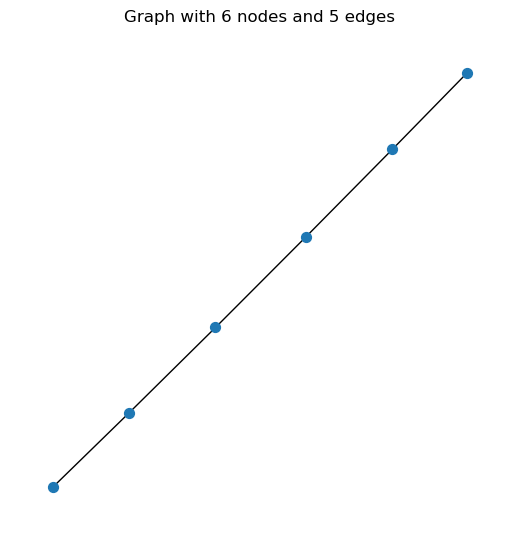

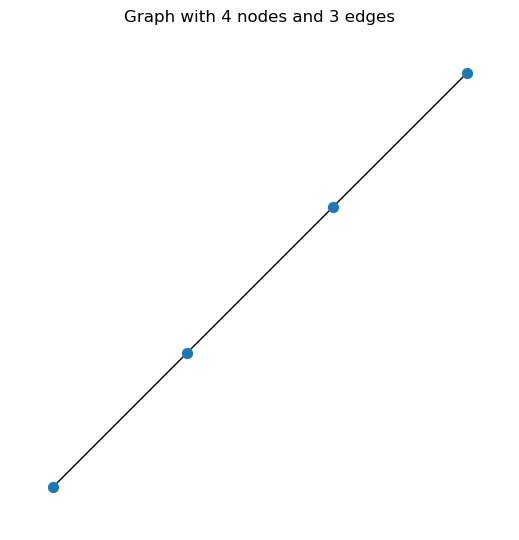

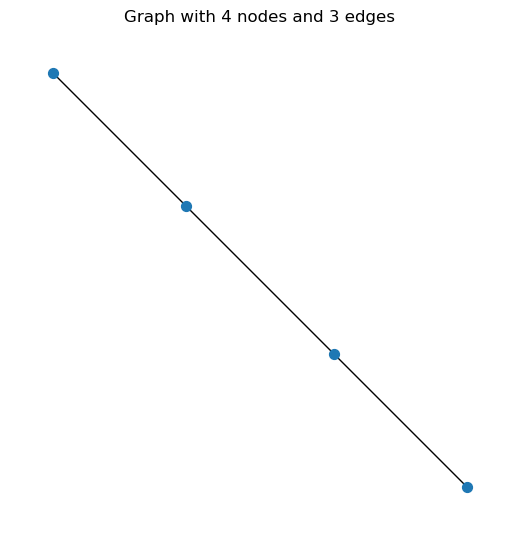

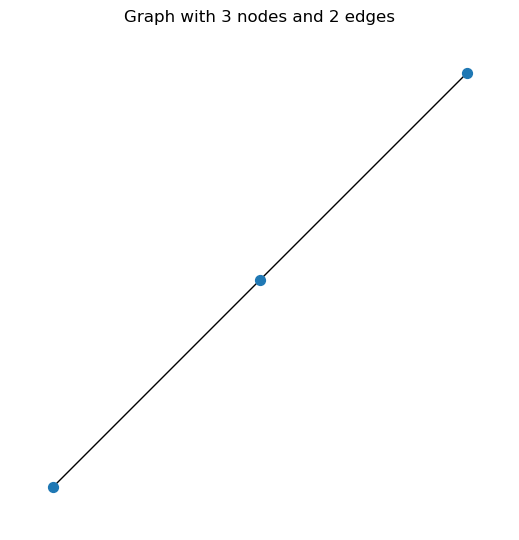

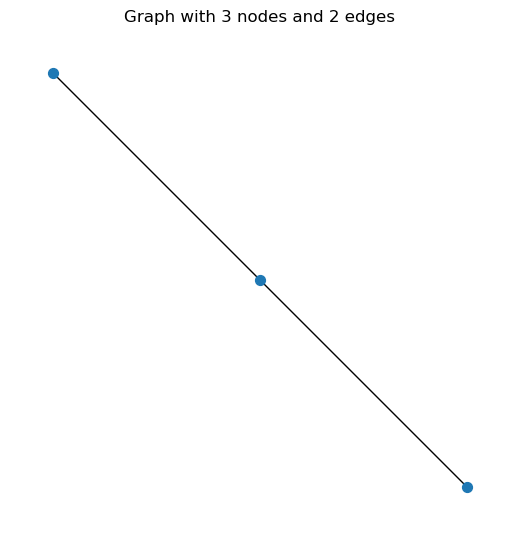

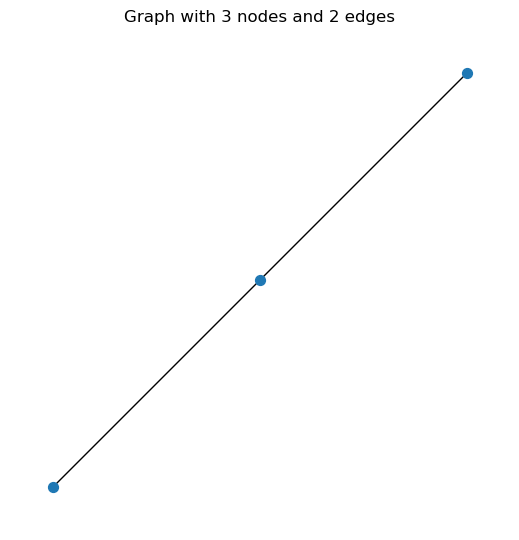

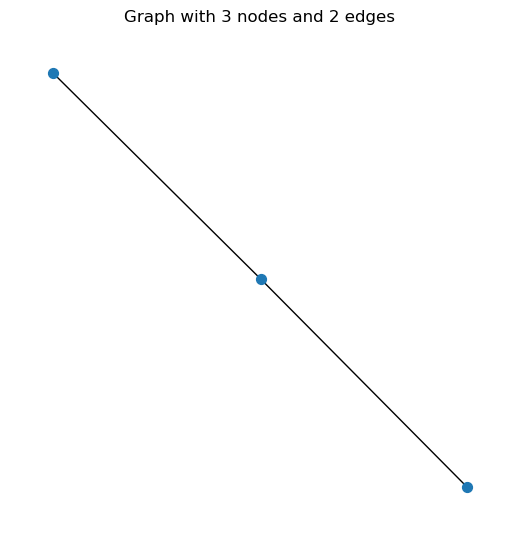

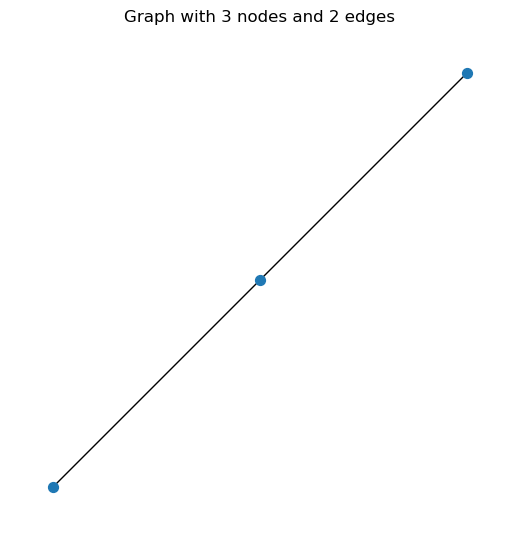

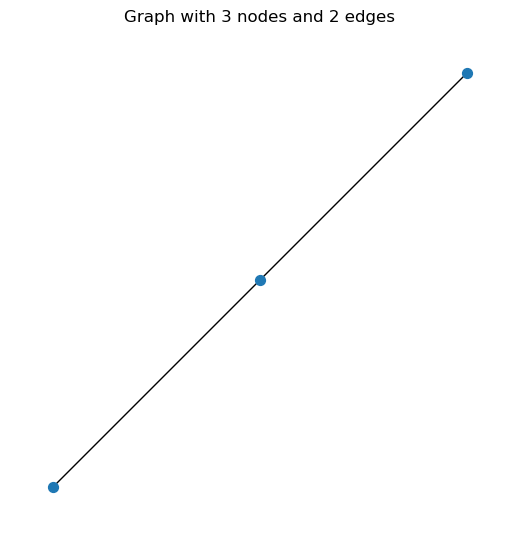

In [39]:
diameters = []
for component in connected_components:
    subgraph = social_network_2.subgraph(component)
    if subgraph.number_of_nodes() > 2:
        plt.figure(figsize=(5, 5))
        pos = nx.spring_layout(subgraph)  # Use a spring layout for visualization
        nx.draw(subgraph, node_size=50, with_labels=False)
        plt.title(subgraph)
        plt.show()
        #print(subgraph)
    if nx.is_connected(subgraph):  # Ensure the subgraph is connected
        diameters.append(nx.diameter(subgraph))

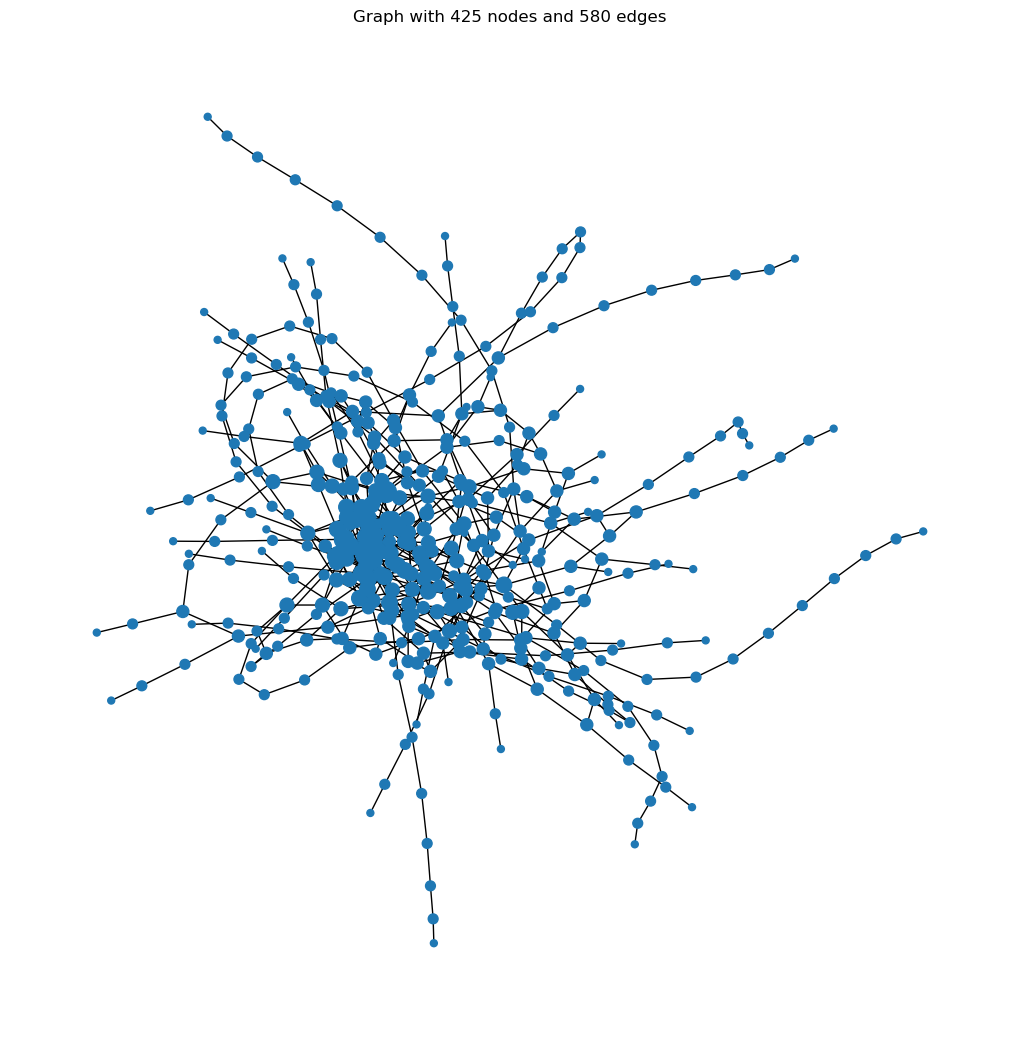

In [40]:
for component in connected_components:
    subgraph = social_network_2.subgraph(component)
    if subgraph.number_of_nodes() > 20:
        plt.figure(figsize=(10, 10))
        degrees = dict(subgraph.degree())
        node_size = [v * 25 for v in degrees.values()]
        nx.draw(subgraph, pos = nx.spring_layout(subgraph), node_size=node_size, with_labels=False) # spectral_layout, spring_layout, kamada_kawai_layout
        plt.title(subgraph)
        plt.savefig('../../reports/figures/network_structure/biggest_component_SN2.png')
        plt.show()

In [41]:
network_data['diameter_connected_components']['SN2'] = collections.Counter(diameters)
collections.Counter(diameters)

Counter({0: 309, 1: 94, 2: 7, 5: 4, 3: 3, 4: 2, 34: 1, 10: 1})

In [42]:
density = nx.density(social_network_2)
network_data['density']['SN2'] = density
density

0.0014714714714714715

In [43]:
degree_centrality = nx.degree_centrality(social_network_2)
degree_centrality

{0: 0.0,
 1: 0.003003003003003003,
 2: 0.001001001001001001,
 3: 0.003003003003003003,
 4: 0.001001001001001001,
 5: 0.002002002002002002,
 6: 0.0,
 7: 0.0,
 8: 0.005005005005005005,
 9: 0.003003003003003003,
 10: 0.0,
 11: 0.004004004004004004,
 12: 0.002002002002002002,
 13: 0.0,
 14: 0.001001001001001001,
 15: 0.0,
 16: 0.002002002002002002,
 17: 0.002002002002002002,
 18: 0.002002002002002002,
 19: 0.0,
 20: 0.001001001001001001,
 21: 0.0,
 22: 0.003003003003003003,
 23: 0.004004004004004004,
 24: 0.001001001001001001,
 25: 0.002002002002002002,
 26: 0.0,
 27: 0.001001001001001001,
 28: 0.004004004004004004,
 29: 0.004004004004004004,
 30: 0.001001001001001001,
 31: 0.001001001001001001,
 32: 0.0,
 33: 0.001001001001001001,
 34: 0.0,
 35: 0.001001001001001001,
 36: 0.002002002002002002,
 37: 0.002002002002002002,
 38: 0.0,
 39: 0.0,
 40: 0.002002002002002002,
 41: 0.003003003003003003,
 42: 0.0,
 43: 0.003003003003003003,
 44: 0.0,
 45: 0.002002002002002002,
 46: 0.0020020020020020

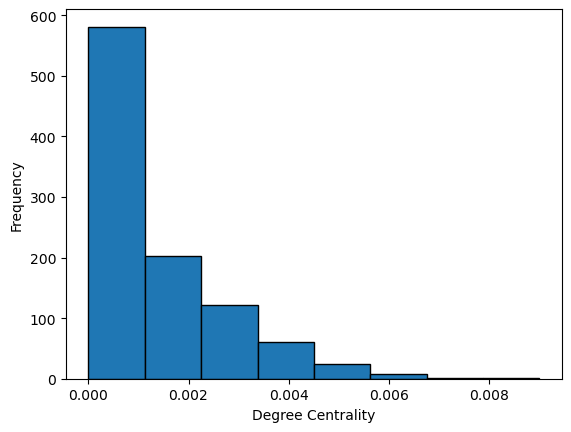

In [44]:
# Extract the values from the dictionary
values = list(degree_centrality.values())

# Create the histogram
plt.hist(values, bins=8, edgecolor='black')  # You can adjust the number of bins as needed

# Add labels and title
plt.xlabel('Degree Centrality')
plt.ylabel('Frequency')

plt.savefig('../../reports/figures/network_structure/degree_centrality_distribution_SN2.png')
# Show the plot
plt.show()

In [45]:
betweenness_centrality = nx.betweenness_centrality(social_network_2)
betweenness_centrality

{0: 0.0,
 1: 0.0034060365723692404,
 2: 0.0,
 3: 0.002890819668820113,
 4: 0.0,
 5: 0.0022253716642494197,
 6: 0.0,
 7: 0.0,
 8: 0.008786882584477778,
 9: 0.005791789180789404,
 10: 0.0,
 11: 0.0037838676282230042,
 12: 0.006676014692046756,
 13: 0.0,
 14: 0.0,
 15: 0.0,
 16: 0.00026850497792381563,
 17: 0.0005719765684138871,
 18: 0.0004361989944265605,
 19: 0.0,
 20: 0.0,
 21: 0.0,
 22: 0.005249375723657621,
 23: 0.0007267582139548304,
 24: 0.0,
 25: 8.024056120248505e-06,
 26: 0.0,
 27: 0.0,
 28: 0.0024230469732585067,
 29: 0.008751367307368203,
 30: 0.0,
 31: 0.0,
 32: 0.0,
 33: 0.0,
 34: 0.0,
 35: 0.0,
 36: 0.0025335957199684655,
 37: 0.0016930758413724347,
 38: 0.0,
 39: 0.0,
 40: 0.0008485439347162794,
 41: 0.006774108867183909,
 42: 0.0,
 43: 0.003298926623353252,
 44: 0.0,
 45: 0.0016930758413724347,
 46: 0.0025335957199684655,
 47: 0.007276116433319739,
 48: 0.0,
 49: 0.007791044731592492,
 50: 0.0,
 51: 0.0012370825831079675,
 52: 0.005006174528552617,
 53: 0.0,
 54: 0.0,
 5

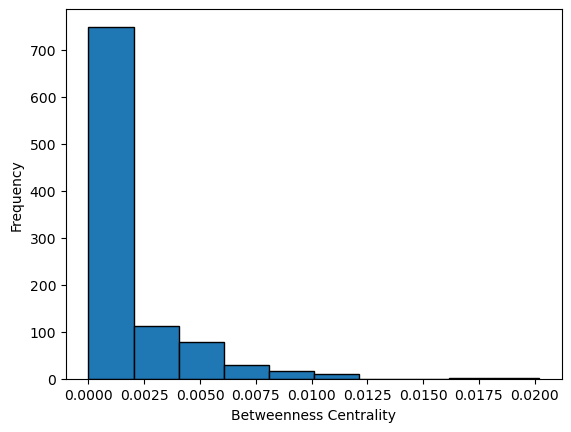

In [46]:
# Extract the values from the dictionary
values = list(betweenness_centrality.values())

# Create the histogram
plt.hist(values, bins=10, edgecolor='black')  # You can adjust the number of bins as needed

# Add labels and title
plt.xlabel('Betweenness Centrality')
plt.ylabel('Frequency')

plt.savefig('../../reports/figures/network_structure/betweenness_centrality_distribution_SN2.png')
# Show the plot
plt.show()

In [47]:
network_data

,nr_nodes,nr_edges,avg_degree,avg_clustering,density,nr_connected_components,diameter_connected_components
SN1,1000,729,1.458,0.002848,0.001459,418,"{27: 1, 1: 101, 0: 304, 3: 3, 12: 1, 8: 1, 9: ..."
SN2,1000,735,1.47,0.005042,0.001471,421,"{0: 309, 34: 1, 1: 94, 5: 4, 4: 2, 2: 7, 10: 1..."
SN3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SN4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SN5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
empirical,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Social Network 3

In [48]:
# network structure related
max_nr_connections = 10
perc_until_what_nr_conn = 0.8
most_conn_below = 4
nr_households = 1000

In [49]:
pdf, x_linspace = get_connections_distribution_halfnormal(perc_until_what_nr_conn, most_conn_below, max_nr_connections)
social_network_3, degrees_3 = construct_network(pdf, max_nr_connections, nr_households)

# if not enough nodes, add a random, unconnected node
if social_network_3.number_of_nodes() < nr_households:
    nodes_missing = nr_households - social_network_3.number_of_nodes()
    for n in range(nodes_missing):
        social_network_3.add_node(social_network_3.number_of_nodes()+1)
if social_network_3.number_of_nodes() != nr_households:
    raise ValueError('The number of households and number of nodes of the network are not equal.')
print(social_network_3)

# Rewire the graph
rewire_for_preferential_attachment(social_network_3)

Graph with 1000 nodes and 1013 edges


In [50]:
network_data['nr_nodes']['SN3'] = social_network_3.number_of_nodes()
network_data['nr_edges']['SN3'] = social_network_3.number_of_edges()
network_data

,nr_nodes,nr_edges,avg_degree,avg_clustering,density,nr_connected_components,diameter_connected_components
SN1,1000,729,1.458,0.002848,0.001459,418,"{27: 1, 1: 101, 0: 304, 3: 3, 12: 1, 8: 1, 9: ..."
SN2,1000,735,1.47,0.005042,0.001471,421,"{0: 309, 34: 1, 1: 94, 5: 4, 4: 2, 2: 7, 10: 1..."
SN3,1000,1005,NaN,NaN,NaN,NaN,NaN
SN4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SN5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
empirical,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
nx.write_graphml(social_network_3, "../../data/processed/network_structures/social_network3.graphml")

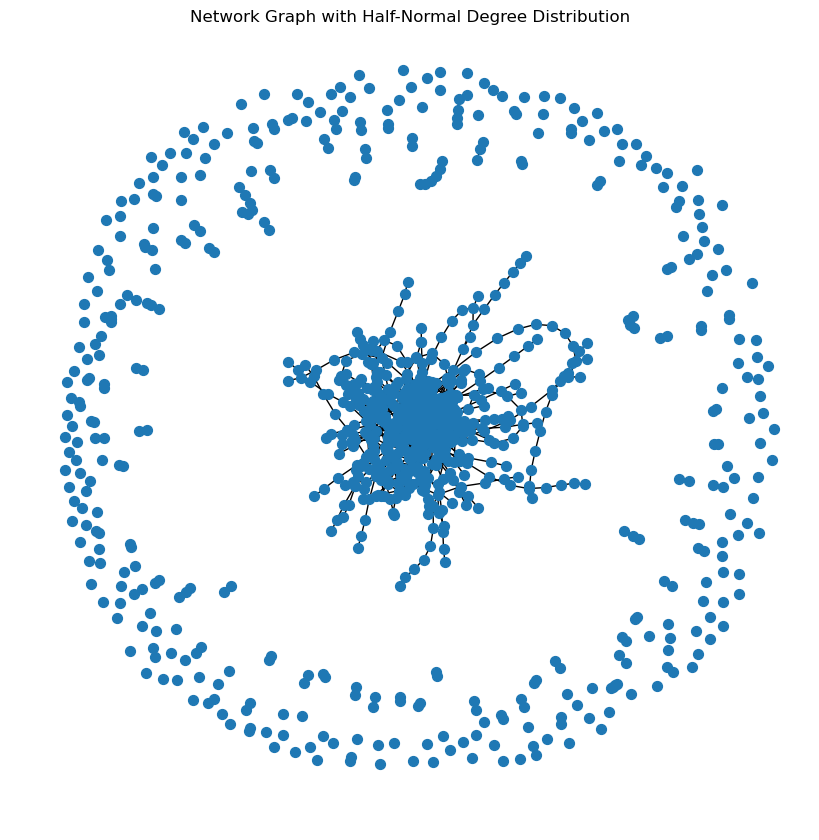

In [53]:
''' Plot of network structure'''
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(social_network_3)  # Use a spring layout for visualization
nx.draw(social_network_3, pos, node_size=50, with_labels=False)
plt.title("Network Graph with Half-Normal Degree Distribution")
plt.show()

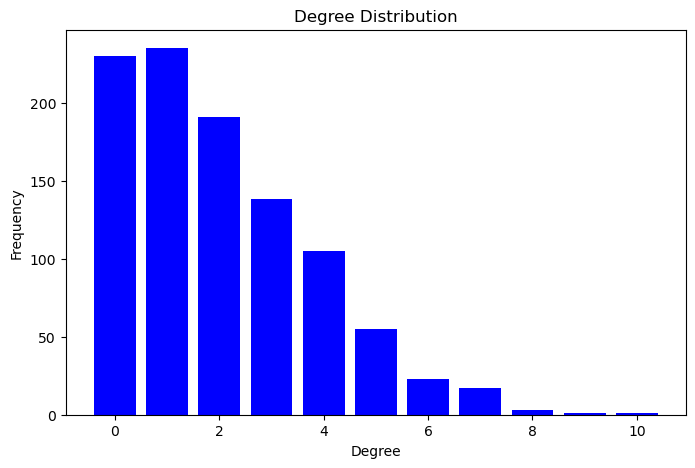

In [54]:
''' Plot of degree distribution'''
plt.figure(figsize=(8, 5))
degree_count = collections.Counter(degrees_3)
degrees_3, counts = zip(*degree_count.items())
plt.bar(degrees_3, counts, color = 'b')
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.savefig('../../reports/figures/network_structure/degree_distribution_SN3.png')

plt.show()

In [55]:
num_nodes = social_network_3.number_of_nodes()
num_edges = social_network_3.number_of_edges()
is_directed = nx.is_directed(social_network_3)

In [56]:
num_connected_components = nx.number_connected_components(social_network_3) if not is_directed else nx.number_strongly_connected_components(social_network_1)
network_data['nr_connected_components']['SN3'] = num_connected_components

num_connected_components

312

In [57]:
connected_components = list(nx.connected_components(social_network_3)) if not is_directed else list(nx.strongly_connected_components(social_network_1))
connected_components

[{0, 699},
 {1,
  2,
  3,
  4,
  6,
  8,
  9,
  10,
  12,
  13,
  14,
  15,
  17,
  18,
  19,
  21,
  22,
  23,
  24,
  26,
  31,
  32,
  34,
  35,
  36,
  37,
  39,
  42,
  45,
  48,
  49,
  50,
  52,
  53,
  57,
  58,
  62,
  65,
  66,
  67,
  68,
  69,
  70,
  72,
  74,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  85,
  86,
  87,
  88,
  91,
  92,
  96,
  97,
  98,
  99,
  101,
  102,
  104,
  105,
  106,
  107,
  109,
  111,
  113,
  114,
  116,
  117,
  118,
  119,
  120,
  121,
  122,
  123,
  125,
  126,
  127,
  129,
  131,
  133,
  134,
  135,
  137,
  139,
  143,
  144,
  145,
  146,
  147,
  151,
  152,
  153,
  154,
  155,
  156,
  158,
  159,
  160,
  161,
  165,
  167,
  168,
  169,
  172,
  173,
  175,
  177,
  178,
  179,
  181,
  182,
  184,
  187,
  188,
  189,
  190,
  194,
  196,
  197,
  198,
  204,
  205,
  210,
  211,
  212,
  216,
  217,
  219,
  220,
  221,
  222,
  224,
  225,
  226,
  227,
  228,
  230,
  231,
  233,
  236,
  237,
  238,
  239,
  240,
  241,
 

In [58]:
degree_sequence = [d for n, d in social_network_3.degree()]
avg_degree = sum(degree_sequence) / num_nodes
network_data['avg_degree']['SN3'] = avg_degree

avg_degree

2.01

In [59]:
avg_clustering = nx.average_clustering(social_network_3)
network_data['avg_clustering']['SN3'] = avg_clustering

avg_clustering

0.003076984126984127

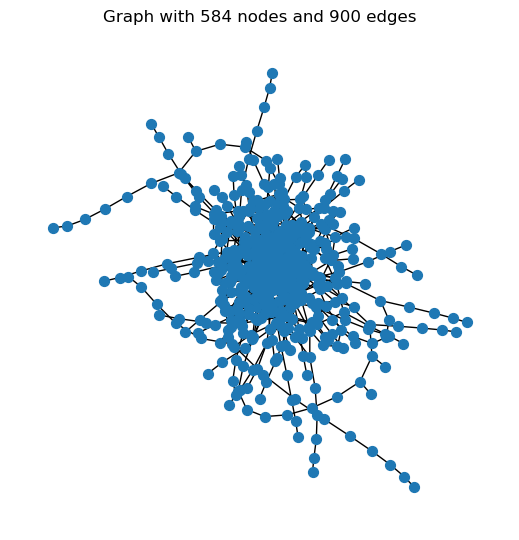

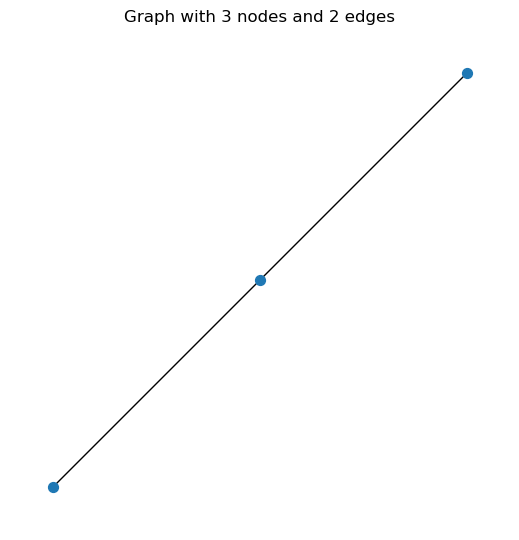

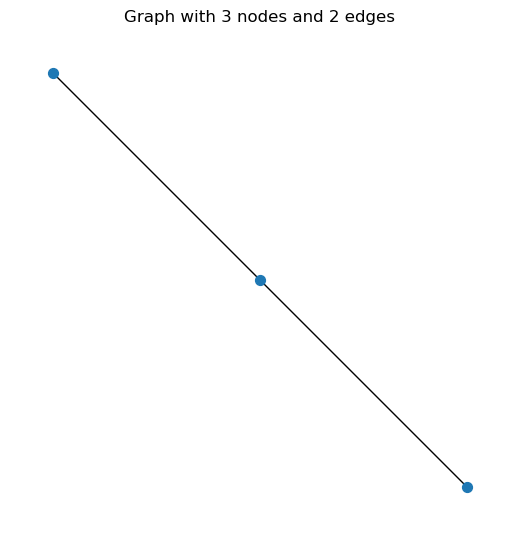

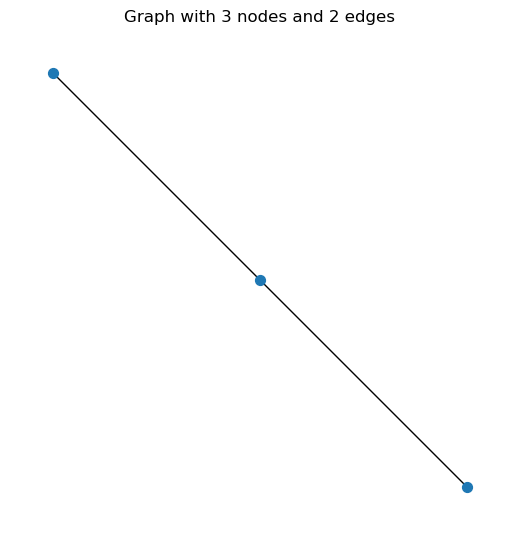

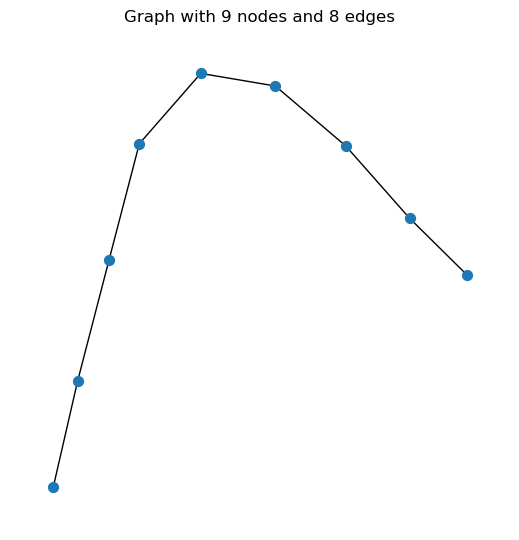

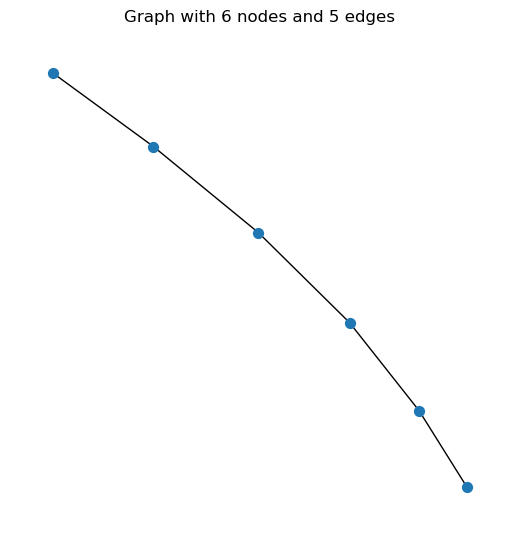

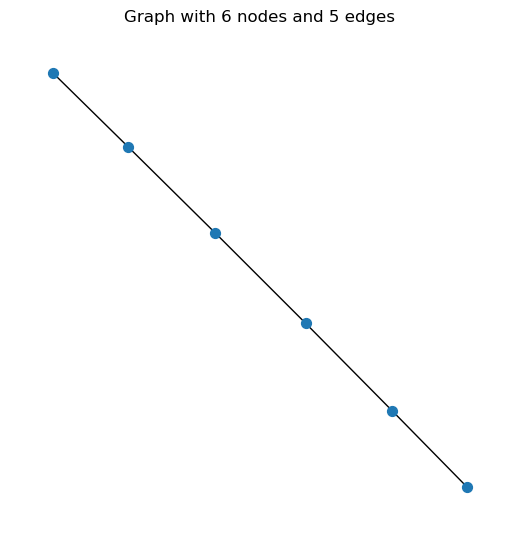

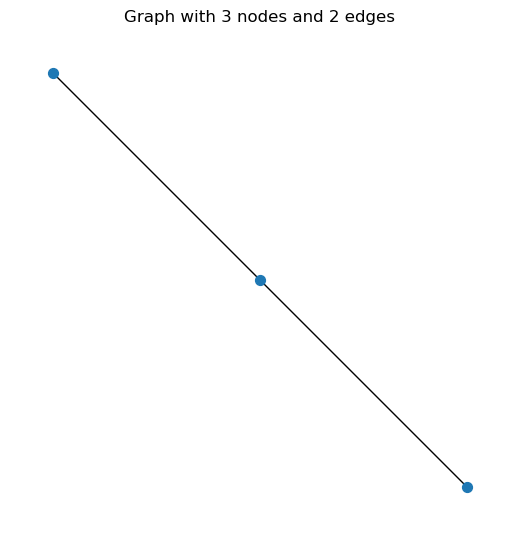

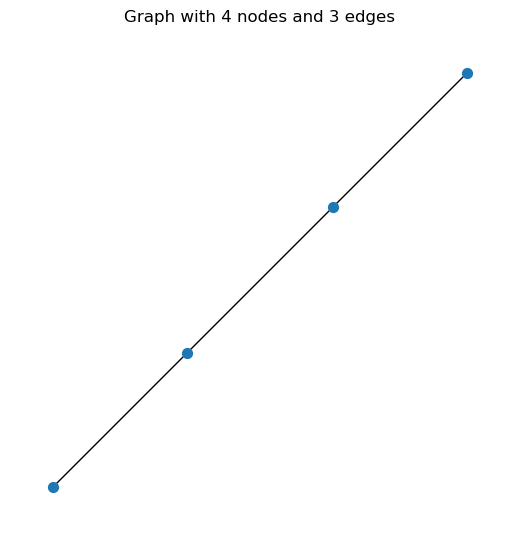

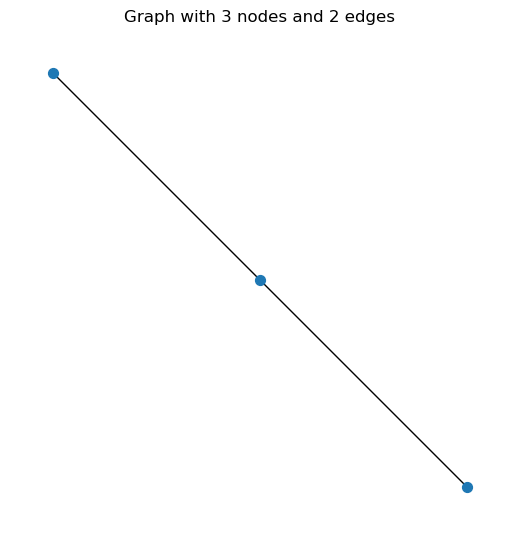

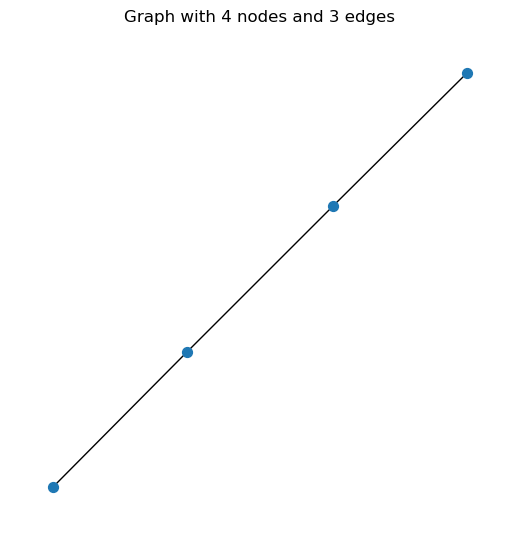

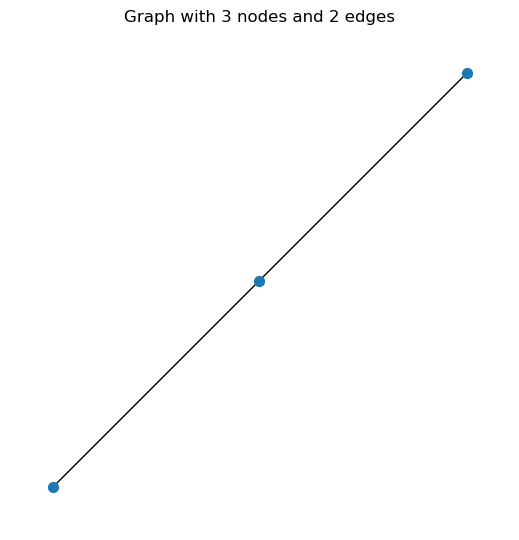

In [60]:
diameters = []
for component in connected_components:
    subgraph = social_network_3.subgraph(component)
    if subgraph.number_of_nodes() > 2:
        plt.figure(figsize=(5, 5))
        pos = nx.spring_layout(subgraph)  # Use a spring layout for visualization
        nx.draw(subgraph, node_size=50, with_labels=False)
        plt.title(subgraph)
        plt.show()
        #print(subgraph)
    if nx.is_connected(subgraph):  # Ensure the subgraph is connected
        diameters.append(nx.diameter(subgraph))

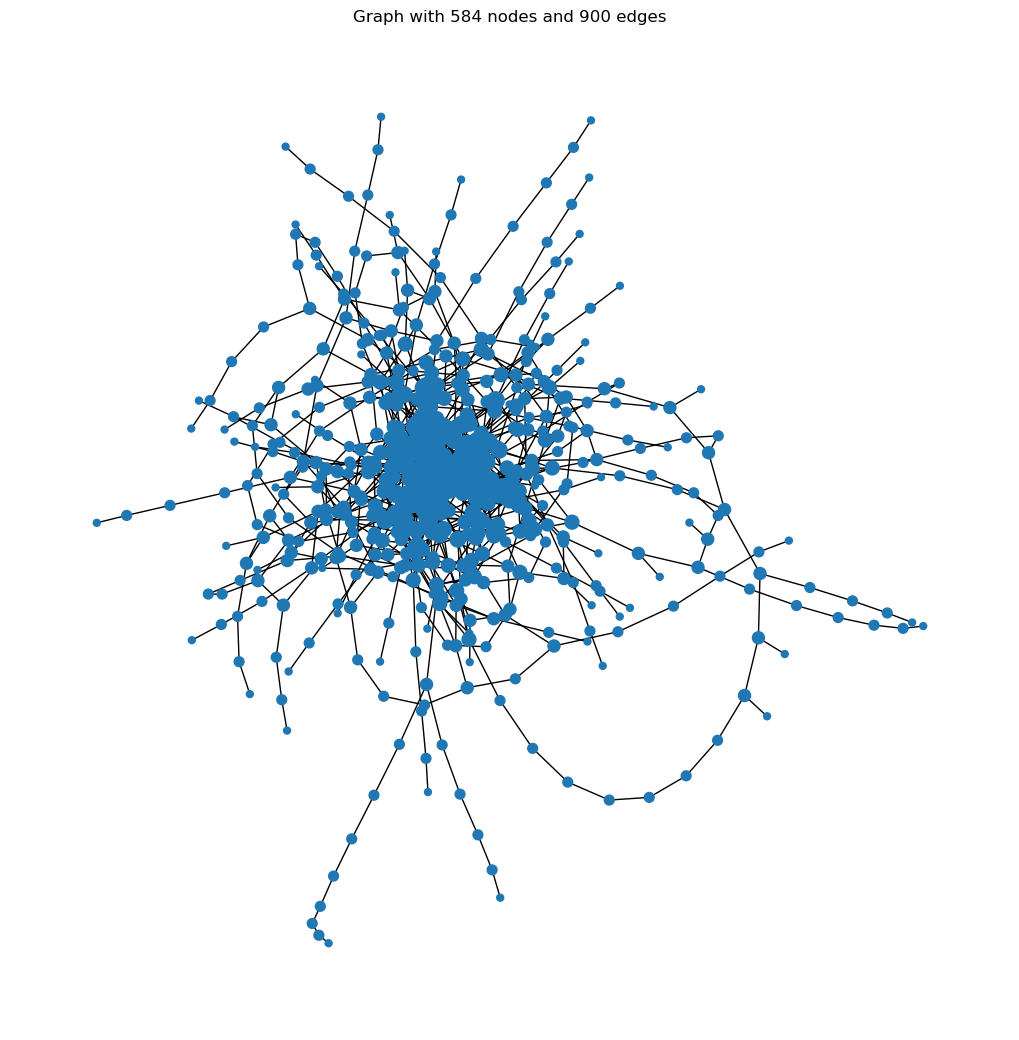

In [61]:
for component in connected_components:
    subgraph = social_network_3.subgraph(component)
    if subgraph.number_of_nodes() > 20:
        plt.figure(figsize=(10, 10))
        degrees = dict(subgraph.degree())
        node_size = [v * 25 for v in degrees.values()]
        nx.draw(subgraph, pos = nx.spring_layout(subgraph), node_size=node_size, with_labels=False) # spectral_layout, spring_layout, kamada_kawai_layout
        plt.title(subgraph)
        plt.savefig('../../reports/figures/network_structure/biggest_component_SN3.png')

        plt.show()

In [62]:
network_data['diameter_connected_components']['SN3'] = collections.Counter(diameters)
collections.Counter(diameters)

Counter({0: 231, 1: 69, 2: 6, 5: 2, 3: 2, 24: 1, 8: 1})

In [63]:
density = nx.density(social_network_3)
network_data['density']['SN3'] = density
density

0.002012012012012012

In [64]:
degree_centrality = nx.degree_centrality(social_network_3)
degree_centrality

{0: 0.001001001001001001,
 1: 0.002002002002002002,
 2: 0.001001001001001001,
 3: 0.002002002002002002,
 4: 0.001001001001001001,
 5: 0.001001001001001001,
 6: 0.002002002002002002,
 7: 0.0,
 8: 0.003003003003003003,
 9: 0.004004004004004004,
 10: 0.004004004004004004,
 11: 0.0,
 12: 0.002002002002002002,
 13: 0.001001001001001001,
 14: 0.002002002002002002,
 15: 0.004004004004004004,
 16: 0.001001001001001001,
 17: 0.008008008008008008,
 18: 0.002002002002002002,
 19: 0.002002002002002002,
 20: 0.002002002002002002,
 21: 0.003003003003003003,
 22: 0.005005005005005005,
 23: 0.002002002002002002,
 24: 0.004004004004004004,
 25: 0.001001001001001001,
 26: 0.004004004004004004,
 27: 0.0,
 28: 0.0,
 29: 0.0,
 30: 0.001001001001001001,
 31: 0.004004004004004004,
 32: 0.002002002002002002,
 33: 0.001001001001001001,
 34: 0.004004004004004004,
 35: 0.006006006006006006,
 36: 0.003003003003003003,
 37: 0.002002002002002002,
 38: 0.0,
 39: 0.006006006006006006,
 40: 0.0,
 41: 0.002002002002002

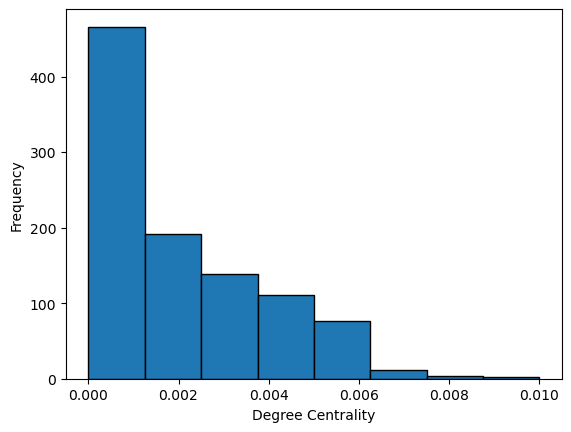

In [65]:
# Extract the values from the dictionary
values = list(degree_centrality.values())

# Create the histogram
plt.hist(values, bins=8, edgecolor='black')  # You can adjust the number of bins as needed

# Add labels and title
plt.xlabel('Degree Centrality')
plt.ylabel('Frequency')

plt.savefig('../../reports/figures/network_structure/degree_centrality_distribution_SN3.png')
# Show the plot
plt.show()

In [66]:
betweenness_centrality = nx.betweenness_centrality(social_network_3)
betweenness_centrality

{0: 0.0,
 1: 0.0006986142516462416,
 2: 0.0,
 3: 0.0034904644123080995,
 4: 0.0,
 5: 0.0,
 6: 0.0011499254206891697,
 7: 0.0,
 8: 0.0030224765361705863,
 9: 0.011100310760897866,
 10: 0.0022773640060846055,
 11: 0.0,
 12: 0.0034904644123080995,
 13: 0.0,
 14: 0.002823950330073686,
 15: 0.0022755978055465907,
 16: 0.0,
 17: 0.009107692646525277,
 18: 0.0023309883029321906,
 19: 0.0003557611902871391,
 20: 2.0060140300621263e-06,
 21: 0.010177705818695412,
 22: 0.005973192965753946,
 23: 0.0011675001654961575,
 24: 0.0046495833410075856,
 25: 0.0,
 26: 0.0034567622934989477,
 27: 0.0,
 28: 0.0,
 29: 0.0,
 30: 0.0,
 31: 0.007459870462110466,
 32: 0.0022731762614693223,
 33: 0.0,
 34: 0.0031313960850594008,
 35: 0.016780725200873613,
 36: 0.0016601160413294502,
 37: 0.0011675001654961575,
 38: 0.0,
 39: 0.008634326242857714,
 40: 0.0,
 41: 2.0060140300621263e-06,
 42: 0.0034904644123080995,
 43: 0.0,
 44: 0.0,
 45: 0.0023309883029321906,
 46: 0.0,
 47: 0.0,
 48: 0.0024940180898295966,
 49:

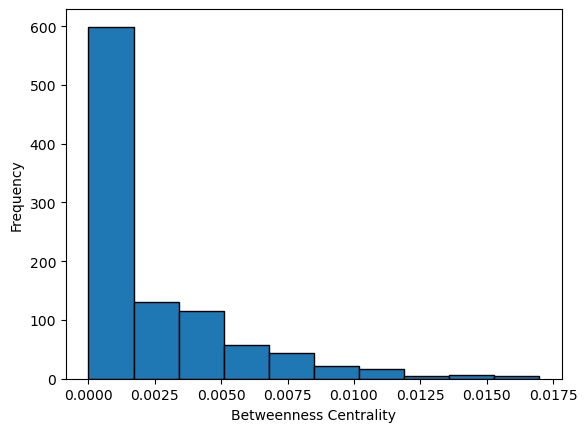

In [67]:
# Extract the values from the dictionary
values = list(betweenness_centrality.values())

# Create the histogram
plt.hist(values, bins=10, edgecolor='black')  # You can adjust the number of bins as needed

# Add labels and title
plt.xlabel('Betweenness Centrality')
plt.ylabel('Frequency')

plt.savefig('../../reports/figures/network_structure/betweenness_centrality_distribution_SN3.png')
# Show the plot
plt.show()

## Social Network 4

In [68]:
# network structure related
max_nr_connections = 6
perc_until_what_nr_conn = 0.5
most_conn_below = 2
nr_households = 1000

In [69]:
pdf, x_linspace = get_connections_distribution_halfnormal(perc_until_what_nr_conn, most_conn_below, max_nr_connections)
social_network_4, degrees_4 = construct_network(pdf, max_nr_connections, nr_households)

# if not enough nodes, add a random, unconnected node
if social_network_4.number_of_nodes() < nr_households:
    nodes_missing = nr_households - social_network_4.number_of_nodes()
    for n in range(nodes_missing):
        social_network_4.add_node(social_network_4.number_of_nodes()+1)
if social_network_4.number_of_nodes() != nr_households:
    raise ValueError('The number of households and number of nodes of the network are not equal.')
print(social_network_4)

# Rewire the graph
rewire_for_preferential_attachment(social_network_4)

Graph with 1000 nodes and 857 edges


In [70]:
network_data['nr_nodes']['SN4'] = social_network_4.number_of_nodes()
network_data['nr_edges']['SN4'] = social_network_4.number_of_edges()
network_data

,nr_nodes,nr_edges,avg_degree,avg_clustering,density,nr_connected_components,diameter_connected_components
SN1,1000,729,1.458,0.002848,0.001459,418,"{27: 1, 1: 101, 0: 304, 3: 3, 12: 1, 8: 1, 9: ..."
SN2,1000,735,1.47,0.005042,0.001471,421,"{0: 309, 34: 1, 1: 94, 5: 4, 4: 2, 2: 7, 10: 1..."
SN3,1000,1005,2.01,0.003077,0.002012,312,"{1: 69, 24: 1, 0: 231, 2: 6, 8: 1, 5: 2, 3: 2}"
SN4,1000,854,NaN,NaN,NaN,NaN,NaN
SN5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
empirical,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [71]:
nx.write_graphml(social_network_4, "../../data/processed/network_structures/social_network4.graphml")

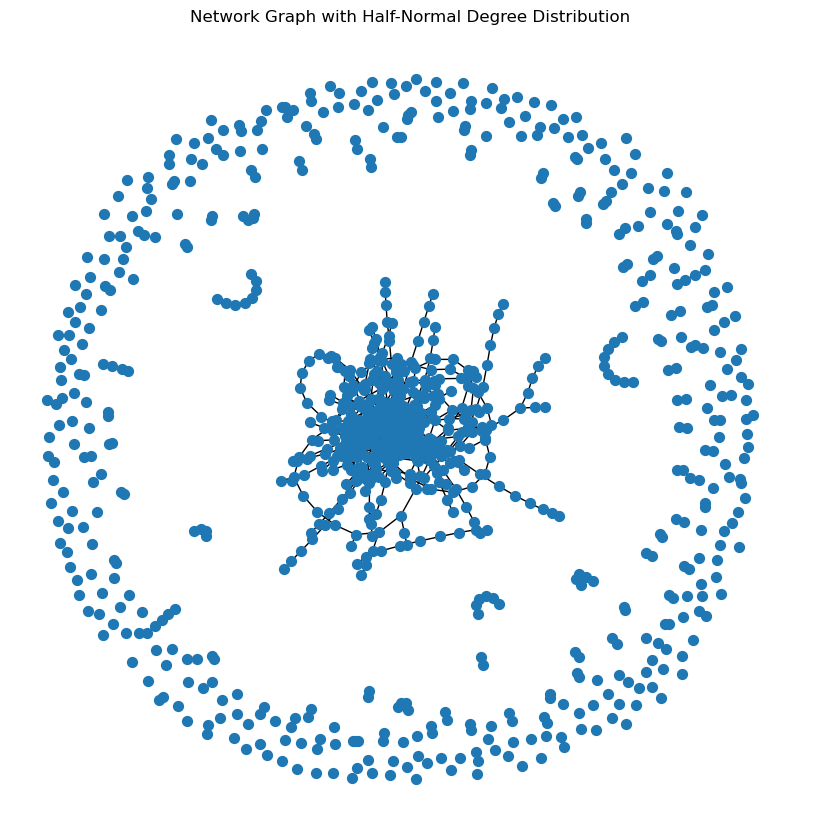

In [72]:
''' Plot of network structure'''
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(social_network_4)  # Use a spring layout for visualization
nx.draw(social_network_4, pos, node_size=50, with_labels=False)
plt.title("Network Graph with Half-Normal Degree Distribution")
plt.show()

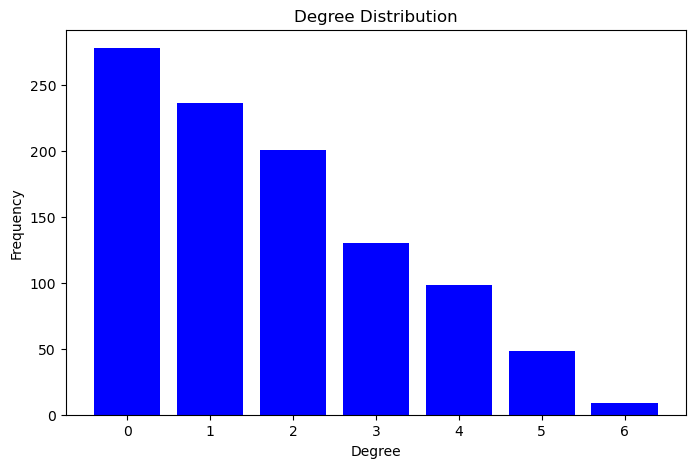

In [73]:
''' Plot of degree distribution'''
plt.figure(figsize=(8, 5))
degree_count = collections.Counter(degrees_4)
degrees_4, counts = zip(*degree_count.items())
plt.bar(degrees_4, counts, color = 'b')
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.savefig('../../reports/figures/network_structure/degree_distribution_SN4.png')

plt.show()

In [74]:
num_nodes = social_network_4.number_of_nodes()
num_edges = social_network_4.number_of_edges()
is_directed = nx.is_directed(social_network_4)

In [75]:
num_connected_components = nx.number_connected_components(social_network_4) if not is_directed else nx.number_strongly_connected_components(social_network_4)
network_data['nr_connected_components']['SN4'] = num_connected_components
num_connected_components

368

In [76]:
connected_components = list(nx.connected_components(social_network_4)) if not is_directed else list(nx.strongly_connected_components(social_network_4))
connected_components

[{0,
  3,
  4,
  5,
  7,
  10,
  13,
  14,
  17,
  22,
  23,
  25,
  27,
  28,
  29,
  30,
  31,
  33,
  34,
  35,
  36,
  37,
  39,
  40,
  42,
  43,
  44,
  45,
  46,
  47,
  49,
  51,
  53,
  54,
  55,
  61,
  64,
  65,
  68,
  72,
  74,
  76,
  78,
  80,
  81,
  85,
  87,
  92,
  94,
  96,
  98,
  99,
  101,
  103,
  108,
  109,
  111,
  113,
  118,
  122,
  124,
  125,
  130,
  131,
  132,
  134,
  135,
  137,
  138,
  140,
  142,
  143,
  144,
  146,
  148,
  149,
  151,
  153,
  154,
  157,
  161,
  162,
  164,
  166,
  169,
  171,
  172,
  174,
  179,
  181,
  186,
  189,
  191,
  192,
  194,
  200,
  202,
  203,
  204,
  207,
  211,
  213,
  215,
  216,
  218,
  219,
  222,
  224,
  225,
  227,
  228,
  229,
  232,
  233,
  235,
  236,
  238,
  241,
  245,
  249,
  251,
  258,
  259,
  261,
  262,
  263,
  264,
  270,
  275,
  277,
  279,
  282,
  283,
  284,
  285,
  288,
  289,
  292,
  296,
  297,
  299,
  302,
  304,
  309,
  311,
  312,
  313,
  315,
  317,
  318,
  324,


In [77]:
degree_sequence = [d for n, d in social_network_4.degree()]
avg_degree = sum(degree_sequence) / num_nodes
network_data['avg_degree']['SN4'] = avg_degree
avg_degree

1.708

In [78]:
avg_clustering = nx.average_clustering(social_network_4)
network_data['avg_clustering']['SN4'] = avg_clustering

avg_clustering

0.0019666666666666665

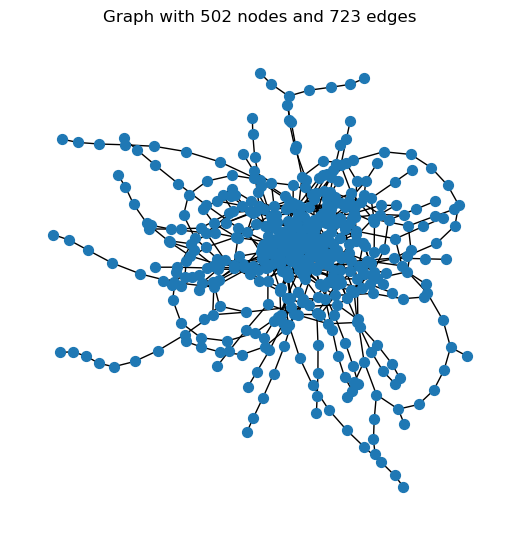

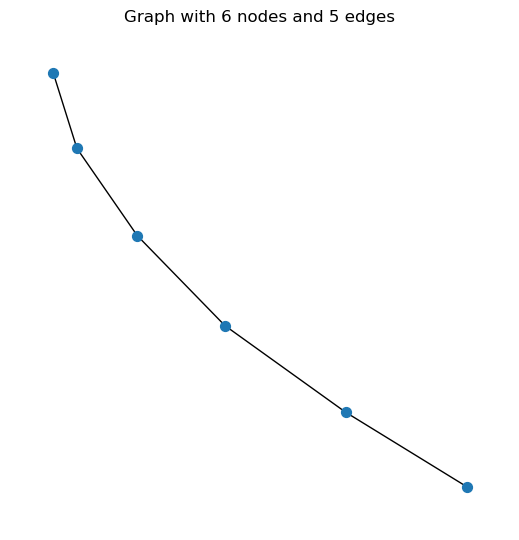

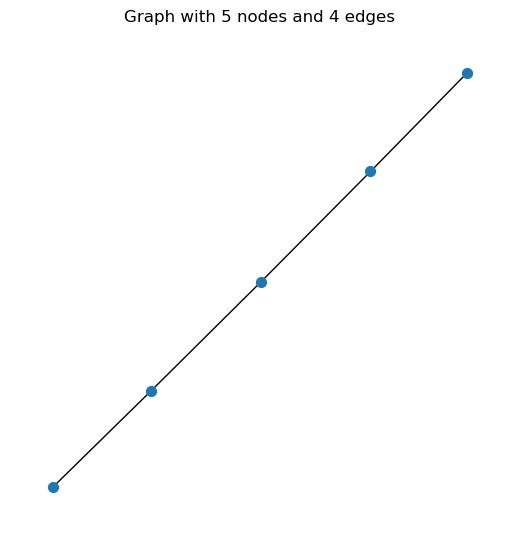

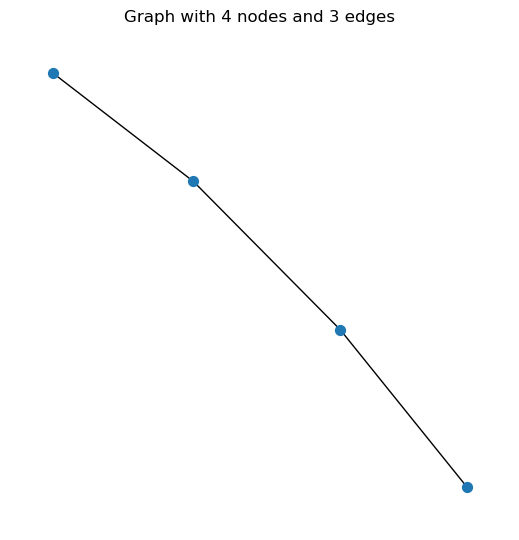

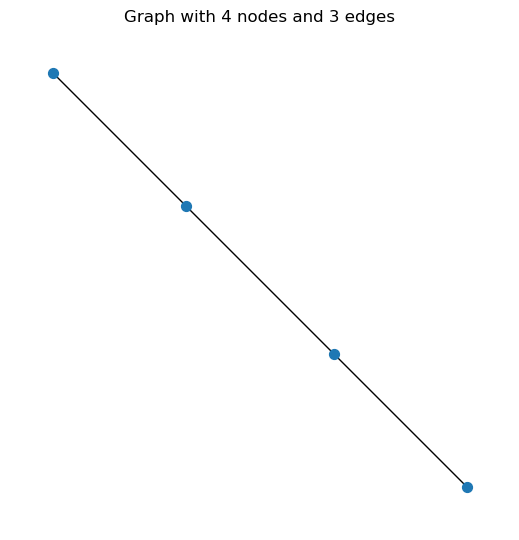

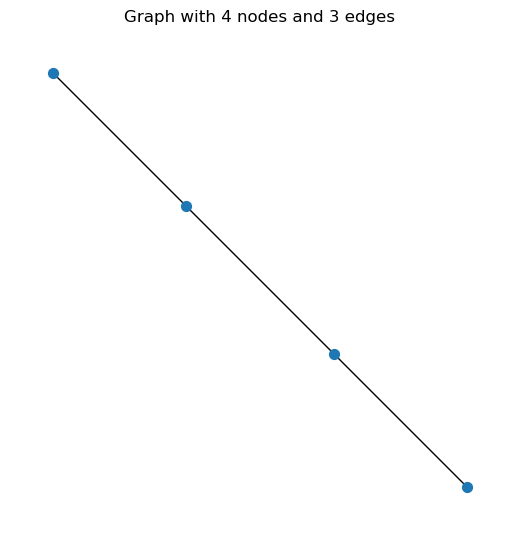

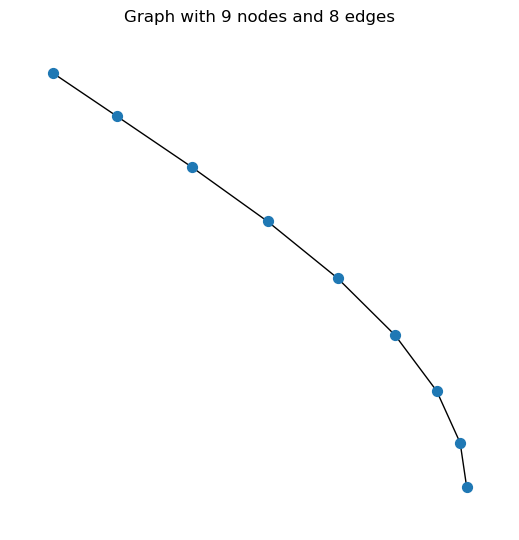

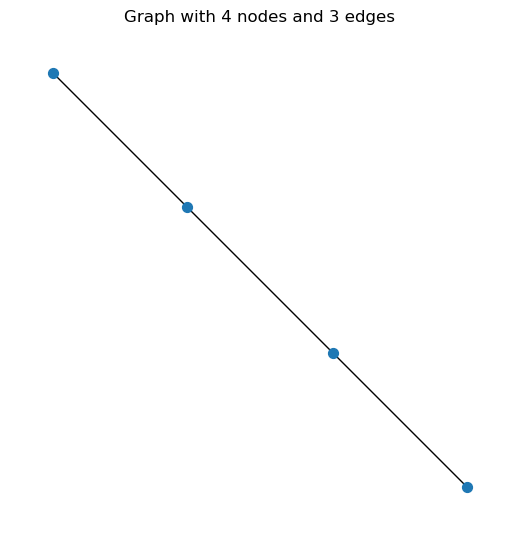

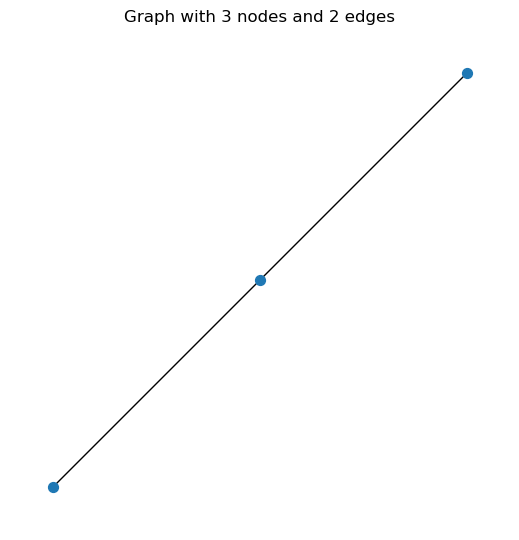

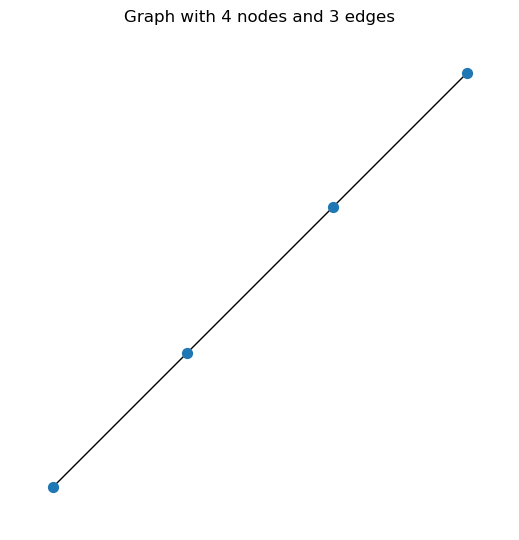

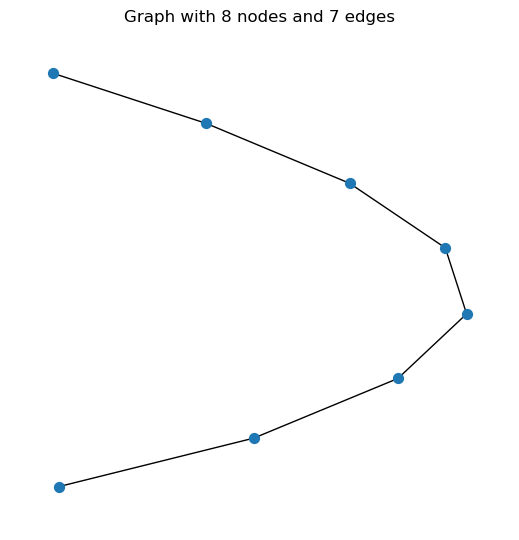

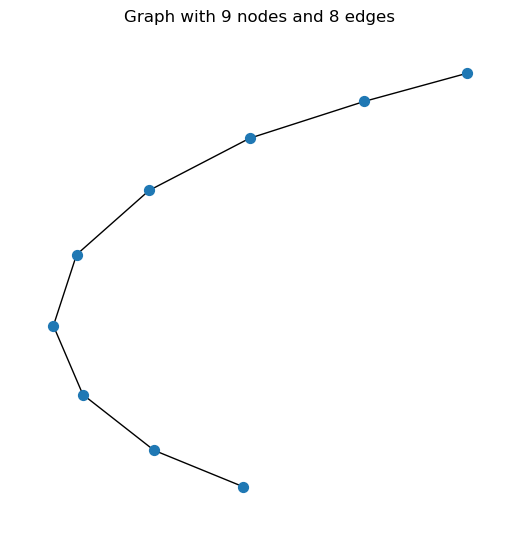

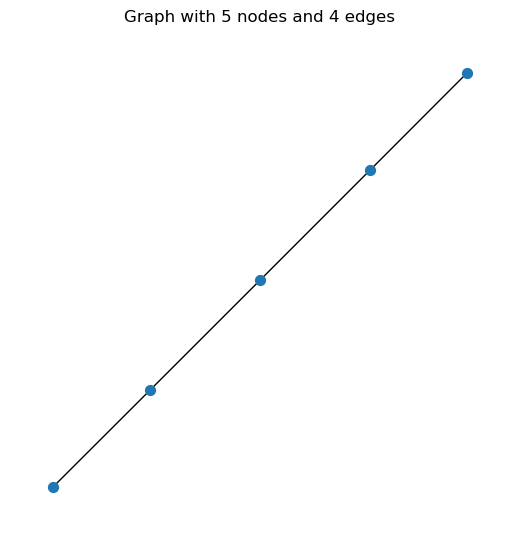

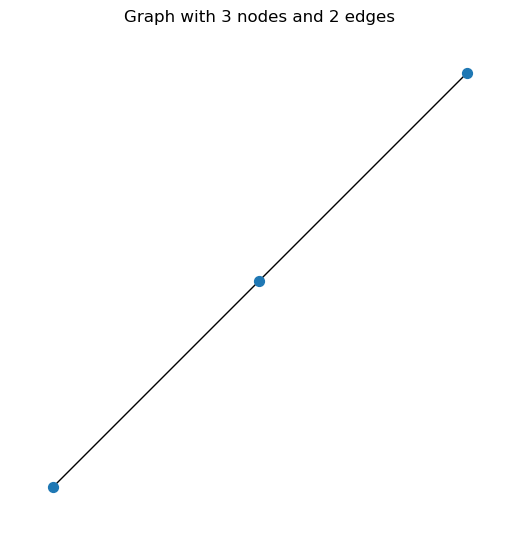

In [79]:
diameters = []
for component in connected_components:
    subgraph = social_network_4.subgraph(component)
    if subgraph.number_of_nodes() > 2:
        plt.figure(figsize=(5, 5))
        pos = nx.spring_layout(subgraph)  # Use a spring layout for visualization
        nx.draw(subgraph, node_size=50, with_labels=False)
        plt.title(subgraph)
        plt.show()
        #print(subgraph)
    if nx.is_connected(subgraph):  # Ensure the subgraph is connected
        diameters.append(nx.diameter(subgraph))

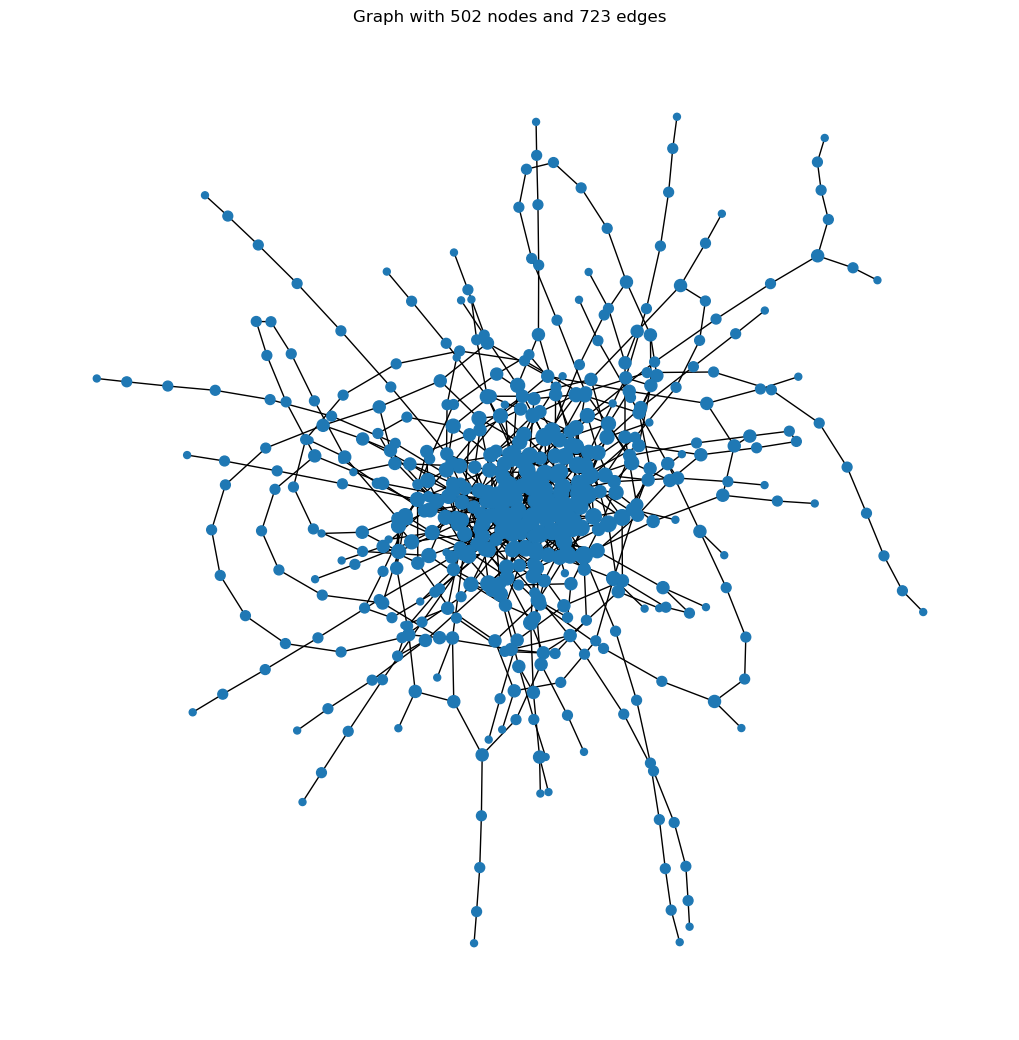

In [80]:
for component in connected_components:
    subgraph = social_network_4.subgraph(component)
    if subgraph.number_of_nodes() > 20:
        plt.figure(figsize=(10, 10))
        degrees = dict(subgraph.degree())
        node_size = [v * 25 for v in degrees.values()]
        nx.draw(subgraph, pos = nx.spring_layout(subgraph), node_size=node_size, with_labels=False) # spectral_layout, spring_layout, kamada_kawai_layout
        plt.title(subgraph)
        plt.savefig('../../reports/figures/network_structure/biggest_component_SN4.png')
       
        plt.show()

In [81]:
network_data['diameter_connected_components']['SN4'] = collections.Counter(diameters)

collections.Counter(diameters)

Counter({0: 278, 1: 76, 3: 5, 4: 2, 8: 2, 2: 2, 24: 1, 5: 1, 7: 1})

In [82]:
density = nx.density(social_network_4)
network_data['density']['SN4'] = density

density

0.0017097097097097096

In [83]:
degree_centrality = nx.degree_centrality(social_network_4)
degree_centrality

{0: 0.001001001001001001,
 1: 0.0,
 2: 0.002002002002002002,
 3: 0.002002002002002002,
 4: 0.001001001001001001,
 5: 0.003003003003003003,
 6: 0.0,
 7: 0.001001001001001001,
 8: 0.001001001001001001,
 9: 0.0,
 10: 0.003003003003003003,
 11: 0.0,
 12: 0.0,
 13: 0.002002002002002002,
 14: 0.002002002002002002,
 15: 0.0,
 16: 0.001001001001001001,
 17: 0.001001001001001001,
 18: 0.0,
 19: 0.0,
 20: 0.001001001001001001,
 21: 0.0,
 22: 0.003003003003003003,
 23: 0.002002002002002002,
 24: 0.0,
 25: 0.002002002002002002,
 26: 0.0,
 27: 0.004004004004004004,
 28: 0.004004004004004004,
 29: 0.004004004004004004,
 30: 0.002002002002002002,
 31: 0.004004004004004004,
 32: 0.0,
 33: 0.002002002002002002,
 34: 0.004004004004004004,
 35: 0.001001001001001001,
 36: 0.003003003003003003,
 37: 0.001001001001001001,
 38: 0.001001001001001001,
 39: 0.003003003003003003,
 40: 0.004004004004004004,
 41: 0.0,
 42: 0.004004004004004004,
 43: 0.003003003003003003,
 44: 0.003003003003003003,
 45: 0.003003003

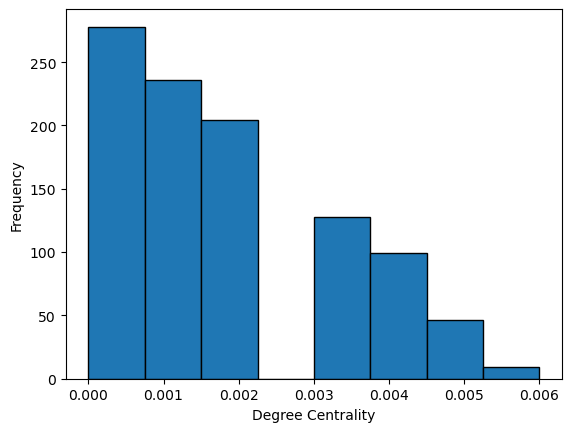

In [84]:
# Extract the values from the dictionary
values = list(degree_centrality.values())

# Create the histogram
plt.hist(values, bins=8, edgecolor='black')  # You can adjust the number of bins as needed

# Add labels and title
plt.xlabel('Degree Centrality')
plt.ylabel('Frequency')

plt.savefig('../../reports/figures/network_structure/degree_centrality_distribution_SN4.png')

# Show the plot
plt.show()

In [85]:
betweenness_centrality = nx.betweenness_centrality(social_network_4)
betweenness_centrality

{0: 0.0,
 1: 0.0,
 2: 1.2036084180372757e-05,
 3: 0.0003829170328836326,
 4: 0.0,
 5: 0.0016129014594038868,
 6: 0.0,
 7: 0.0,
 8: 0.0,
 9: 0.0,
 10: 0.0017218115039488748,
 11: 0.0,
 12: 0.0,
 13: 0.0012615241740158239,
 14: 0.0005077603607997729,
 15: 0.0,
 16: 0.0,
 17: 0.0,
 18: 0.0,
 19: 0.0,
 20: 0.0,
 21: 0.0,
 22: 0.004663666643181229,
 23: 0.001194544420702619,
 24: 0.0,
 25: 0.0013900851130866725,
 26: 0.0,
 27: 0.007415618549705883,
 28: 0.004636730184721597,
 29: 0.004941366963430237,
 30: 0.0010030070150310632,
 31: 0.004523594189036185,
 32: 0.0,
 33: 0.0007854731023290362,
 34: 0.005913988659295235,
 35: 0.0,
 36: 0.0013763371216667902,
 37: 0.0,
 38: 0.0,
 39: 0.00440963067326906,
 40: 0.005269929235335107,
 41: 0.0,
 42: 0.006049303018240895,
 43: 0.004229693978800036,
 44: 0.006879823028296445,
 45: 0.0038572450182707725,
 46: 0.002005268143099361,
 47: 0.0,
 48: 8.024056120248505e-06,
 49: 0.0010030070150310632,
 50: 0.0,
 51: 0.0,
 52: 0.0,
 53: 0.002363280658760509

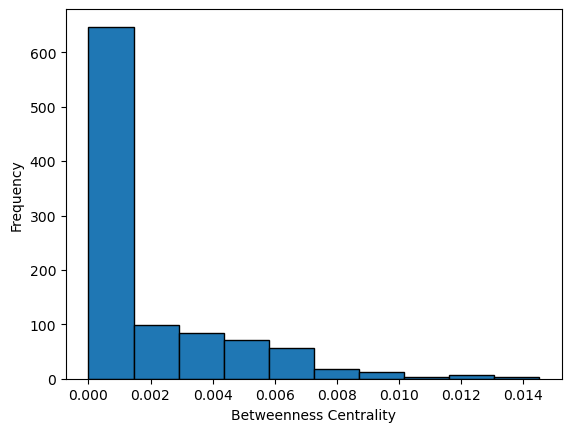

In [86]:
# Extract the values from the dictionary
values = list(betweenness_centrality.values())

# Create the histogram
plt.hist(values, bins=10, edgecolor='black')  # You can adjust the number of bins as needed

# Add labels and title
plt.xlabel('Betweenness Centrality')
plt.ylabel('Frequency')

plt.savefig('../../reports/figures/network_structure/betweenness_centrality_distribution_SN4.png')
# Show the plot
plt.show()

In [87]:
network_data

,nr_nodes,nr_edges,avg_degree,avg_clustering,density,nr_connected_components,diameter_connected_components
SN1,1000,729,1.458,0.002848,0.001459,418,"{27: 1, 1: 101, 0: 304, 3: 3, 12: 1, 8: 1, 9: ..."
SN2,1000,735,1.47,0.005042,0.001471,421,"{0: 309, 34: 1, 1: 94, 5: 4, 4: 2, 2: 7, 10: 1..."
SN3,1000,1005,2.01,0.003077,0.002012,312,"{1: 69, 24: 1, 0: 231, 2: 6, 8: 1, 5: 2, 3: 2}"
SN4,1000,854,1.708,0.001967,0.00171,368,"{24: 1, 0: 278, 5: 1, 1: 76, 4: 2, 3: 5, 8: 2,..."
SN5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
empirical,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Social Network 5

In [88]:
# network structure related
max_nr_connections = 30
perc_until_what_nr_conn = 0.8
most_conn_below = 3
nr_households = 1000

In [89]:
pdf, x_linspace = get_connections_distribution_halfnormal(perc_until_what_nr_conn, most_conn_below, max_nr_connections)
social_network_5, degrees_5 = construct_network(pdf, max_nr_connections, nr_households)

# if not enough nodes, add a random, unconnected node
if social_network_5.number_of_nodes() < nr_households:
    nodes_missing = nr_households - social_network_5.number_of_nodes()
    for n in range(nodes_missing):
        social_network_5.add_node(social_network_5.number_of_nodes()+1)
if social_network_5.number_of_nodes() != nr_households:
    raise ValueError('The number of households and number of nodes of the network are not equal.')
print(social_network_5)

# Rewire the graph
rewire_for_preferential_attachment(social_network_5)

Graph with 1000 nodes and 788 edges


In [90]:
network_data['nr_nodes']['SN5'] = social_network_5.number_of_nodes()
network_data['nr_edges']['SN5'] = social_network_5.number_of_edges()
network_data

,nr_nodes,nr_edges,avg_degree,avg_clustering,density,nr_connected_components,diameter_connected_components
SN1,1000,729,1.458,0.002848,0.001459,418,"{27: 1, 1: 101, 0: 304, 3: 3, 12: 1, 8: 1, 9: ..."
SN2,1000,735,1.47,0.005042,0.001471,421,"{0: 309, 34: 1, 1: 94, 5: 4, 4: 2, 2: 7, 10: 1..."
SN3,1000,1005,2.01,0.003077,0.002012,312,"{1: 69, 24: 1, 0: 231, 2: 6, 8: 1, 5: 2, 3: 2}"
SN4,1000,854,1.708,0.001967,0.00171,368,"{24: 1, 0: 278, 5: 1, 1: 76, 4: 2, 3: 5, 8: 2,..."
SN5,1000,783,NaN,NaN,NaN,NaN,NaN
empirical,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [91]:
nx.write_graphml(social_network_5, "../../data/processed/network_structures/social_network5.graphml")

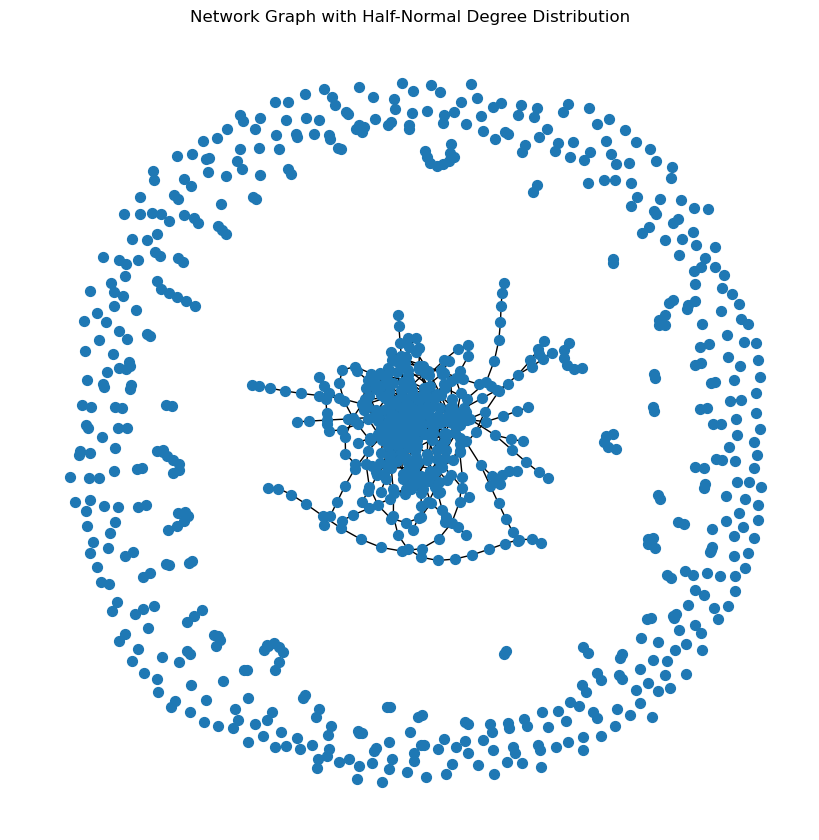

In [92]:
''' Plot of network structure'''
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(social_network_5)  # Use a spring layout for visualization
nx.draw(social_network_5, pos, node_size=50, with_labels=False)
plt.title("Network Graph with Half-Normal Degree Distribution")
plt.show()

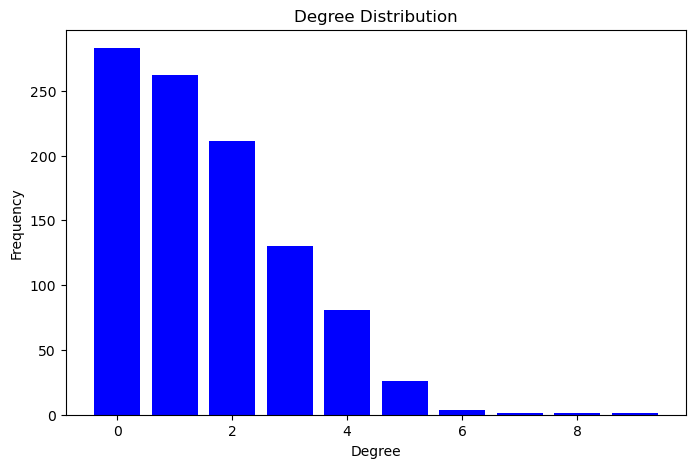

In [93]:
''' Plot of degree distribution'''
plt.figure(figsize=(8, 5))
degree_count = collections.Counter(degrees_5)
degrees_5, counts = zip(*degree_count.items())
plt.bar(degrees_5, counts, color = 'b')
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.savefig('../../reports/figures/network_structure/degree_distribution_SN5.png')
plt.show()

In [94]:
num_nodes = social_network_5.number_of_nodes()
num_edges = social_network_5.number_of_edges()
is_directed = nx.is_directed(social_network_5)

In [95]:
num_connected_components = nx.number_connected_components(social_network_5) if not is_directed else nx.number_strongly_connected_components(social_network_5)
network_data['nr_connected_components']['SN5'] = num_connected_components

num_connected_components

395

In [96]:
connected_components = list(nx.connected_components(social_network_5)) if not is_directed else list(nx.strongly_connected_components(social_network_5))

connected_components

[{0,
  6,
  7,
  15,
  23,
  24,
  25,
  26,
  27,
  32,
  33,
  35,
  38,
  44,
  47,
  50,
  52,
  56,
  61,
  66,
  67,
  70,
  73,
  75,
  76,
  79,
  86,
  88,
  89,
  91,
  93,
  94,
  97,
  98,
  99,
  100,
  103,
  104,
  107,
  108,
  110,
  112,
  113,
  115,
  119,
  120,
  124,
  126,
  128,
  133,
  134,
  137,
  138,
  139,
  145,
  147,
  148,
  150,
  154,
  156,
  159,
  162,
  163,
  164,
  167,
  168,
  169,
  170,
  171,
  172,
  175,
  176,
  177,
  179,
  180,
  181,
  182,
  184,
  186,
  187,
  189,
  190,
  191,
  192,
  194,
  197,
  205,
  206,
  207,
  208,
  210,
  211,
  213,
  215,
  217,
  219,
  225,
  228,
  230,
  232,
  237,
  239,
  242,
  243,
  248,
  250,
  251,
  257,
  260,
  266,
  269,
  271,
  276,
  278,
  279,
  281,
  282,
  283,
  285,
  286,
  287,
  290,
  299,
  300,
  303,
  304,
  305,
  306,
  310,
  311,
  314,
  319,
  320,
  325,
  327,
  329,
  331,
  332,
  335,
  336,
  338,
  339,
  342,
  343,
  345,
  347,
  348,
  351,
  

In [97]:
degree_sequence = [d for n, d in social_network_5.degree()]
avg_degree = sum(degree_sequence) / num_nodes
network_data['avg_degree']['SN5'] = avg_degree

avg_degree

1.566

In [98]:
avg_clustering = nx.average_clustering(social_network_5)
network_data['avg_clustering']['SN5'] = avg_clustering

avg_clustering

0.0031904761904761906

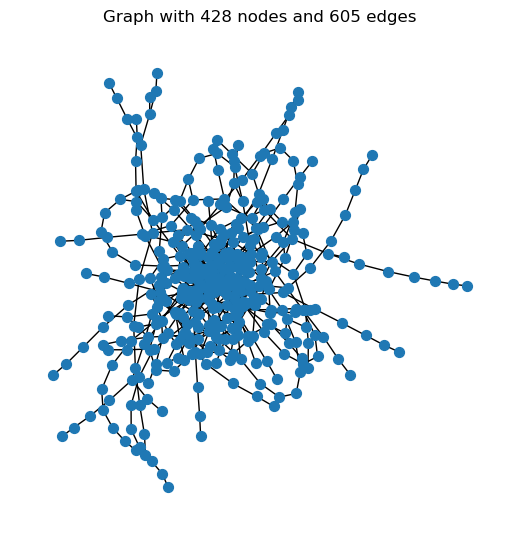

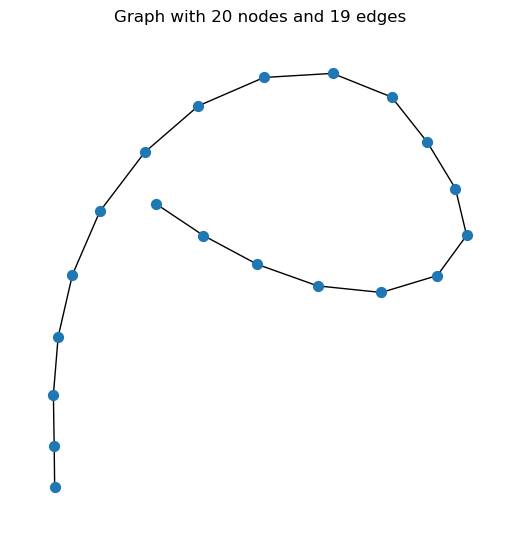

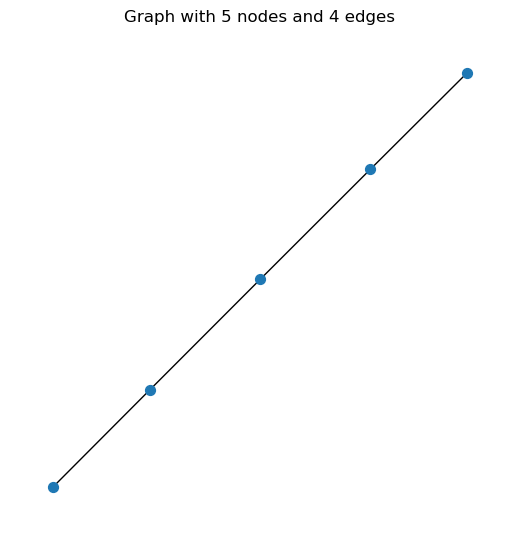

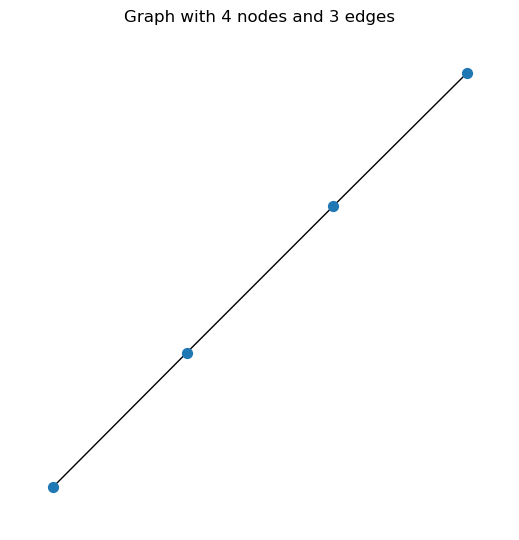

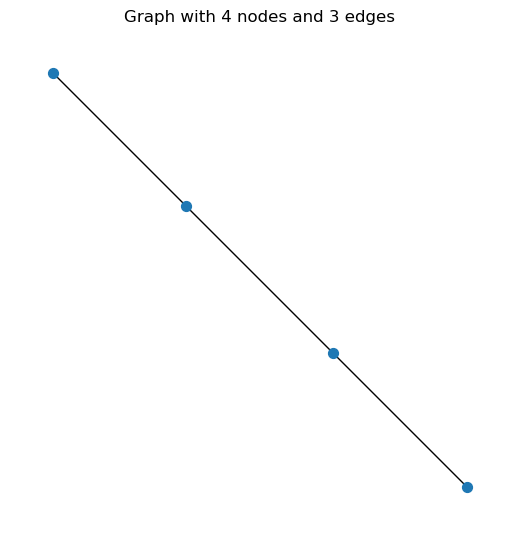

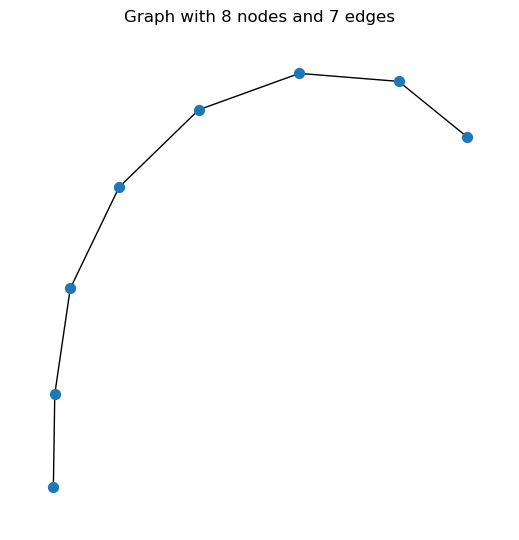

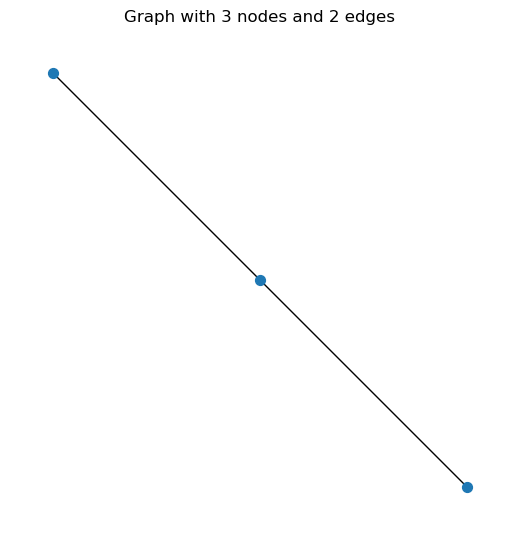

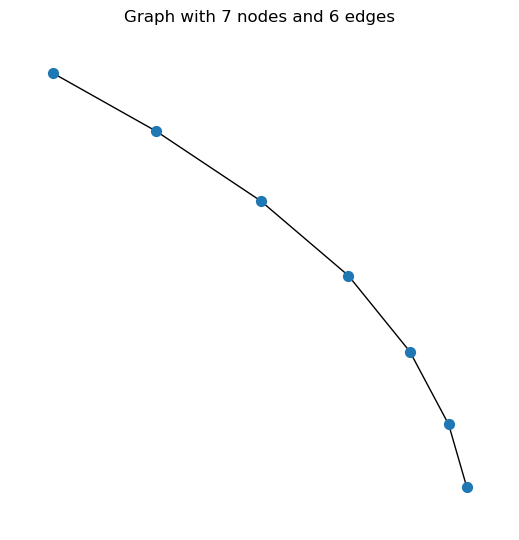

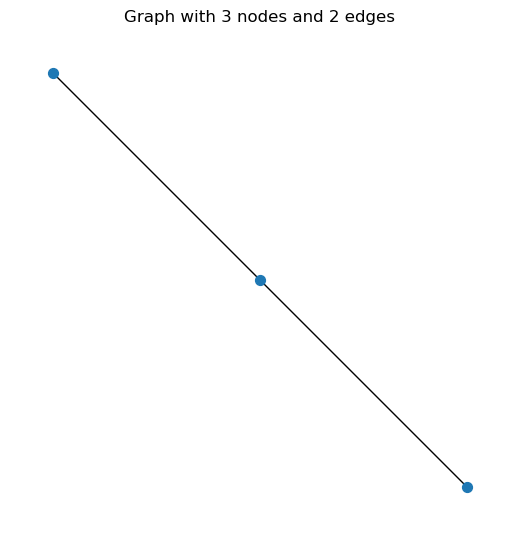

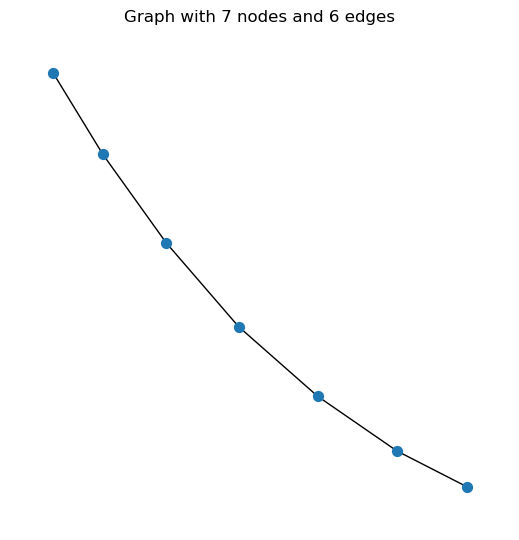

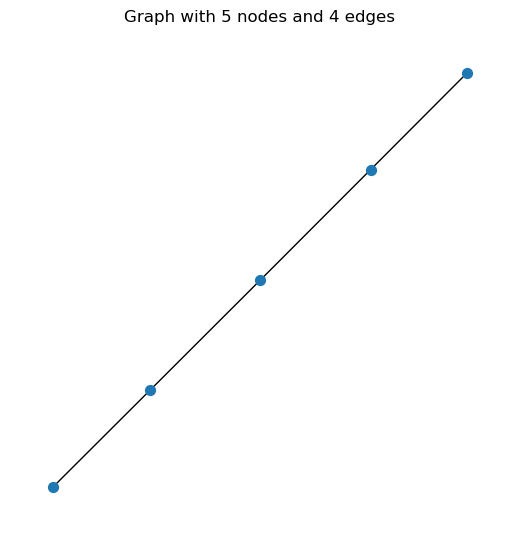

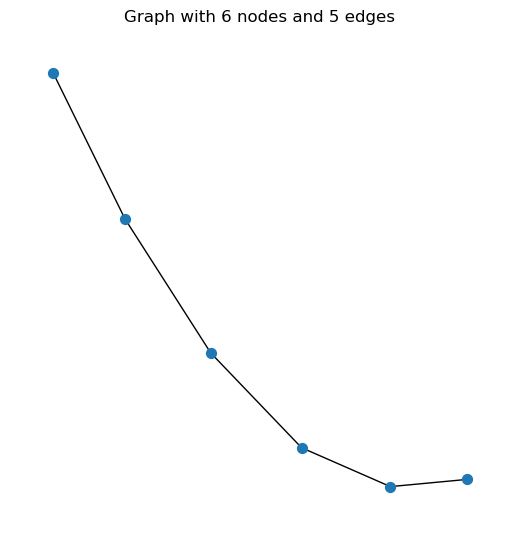

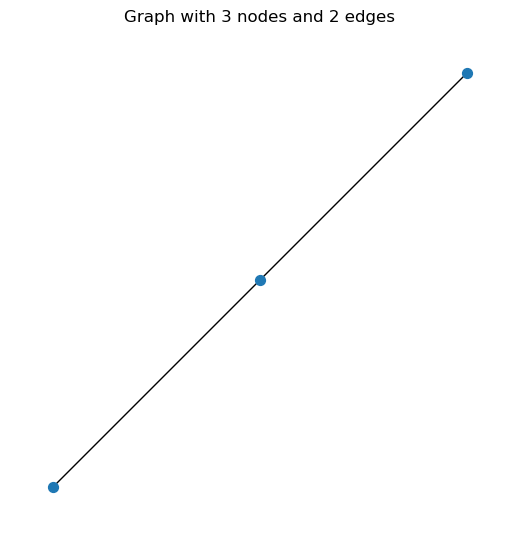

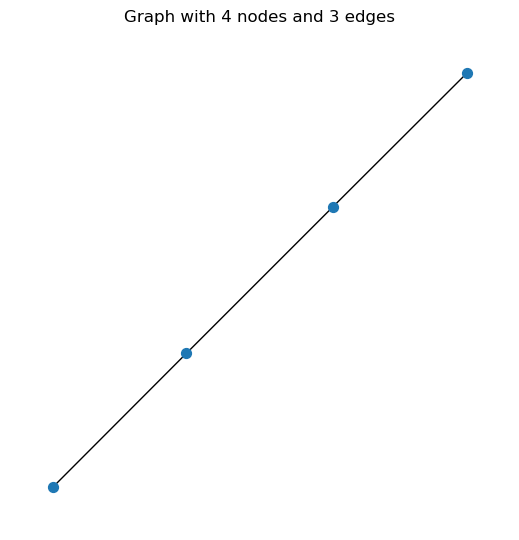

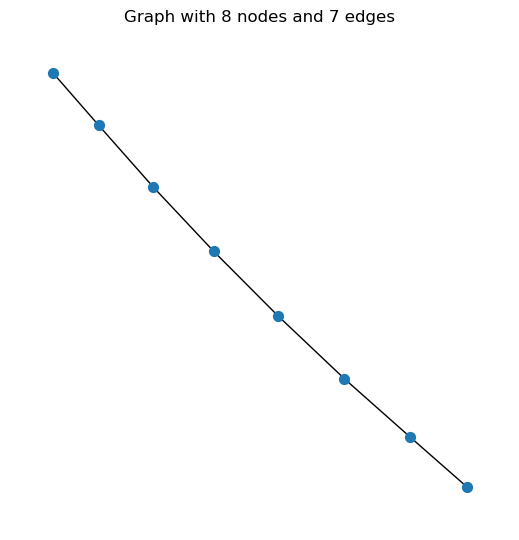

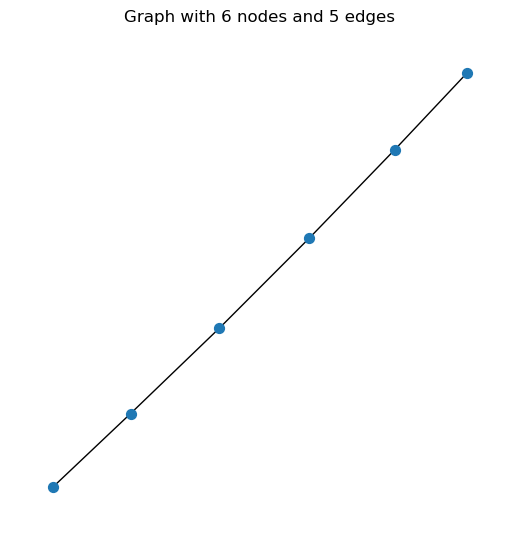

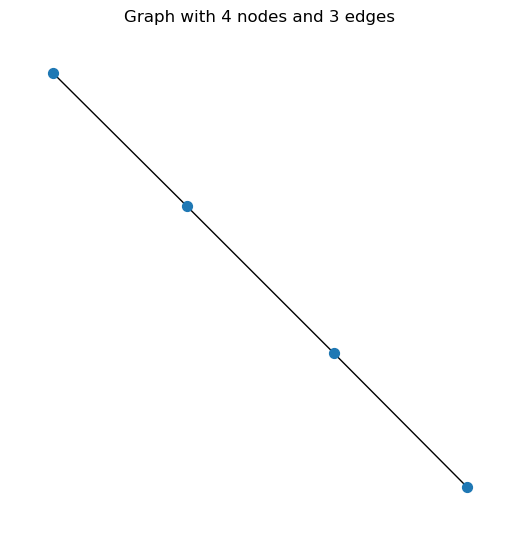

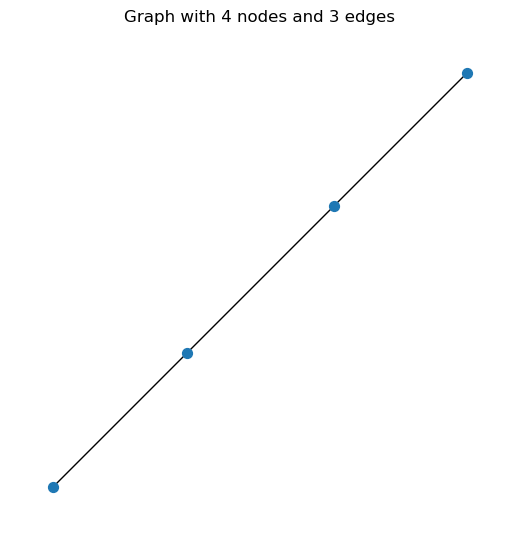

In [99]:
diameters = []
for component in connected_components:
    subgraph = social_network_5.subgraph(component)
    if subgraph.number_of_nodes() > 2:
        plt.figure(figsize=(5, 5))
        pos = nx.spring_layout(subgraph)  # Use a spring layout for visualization
        nx.draw(subgraph, node_size=50, with_labels=False)
        plt.title(subgraph)
        plt.show()
        #print(subgraph)
    if nx.is_connected(subgraph):  # Ensure the subgraph is connected
        diameters.append(nx.diameter(subgraph))

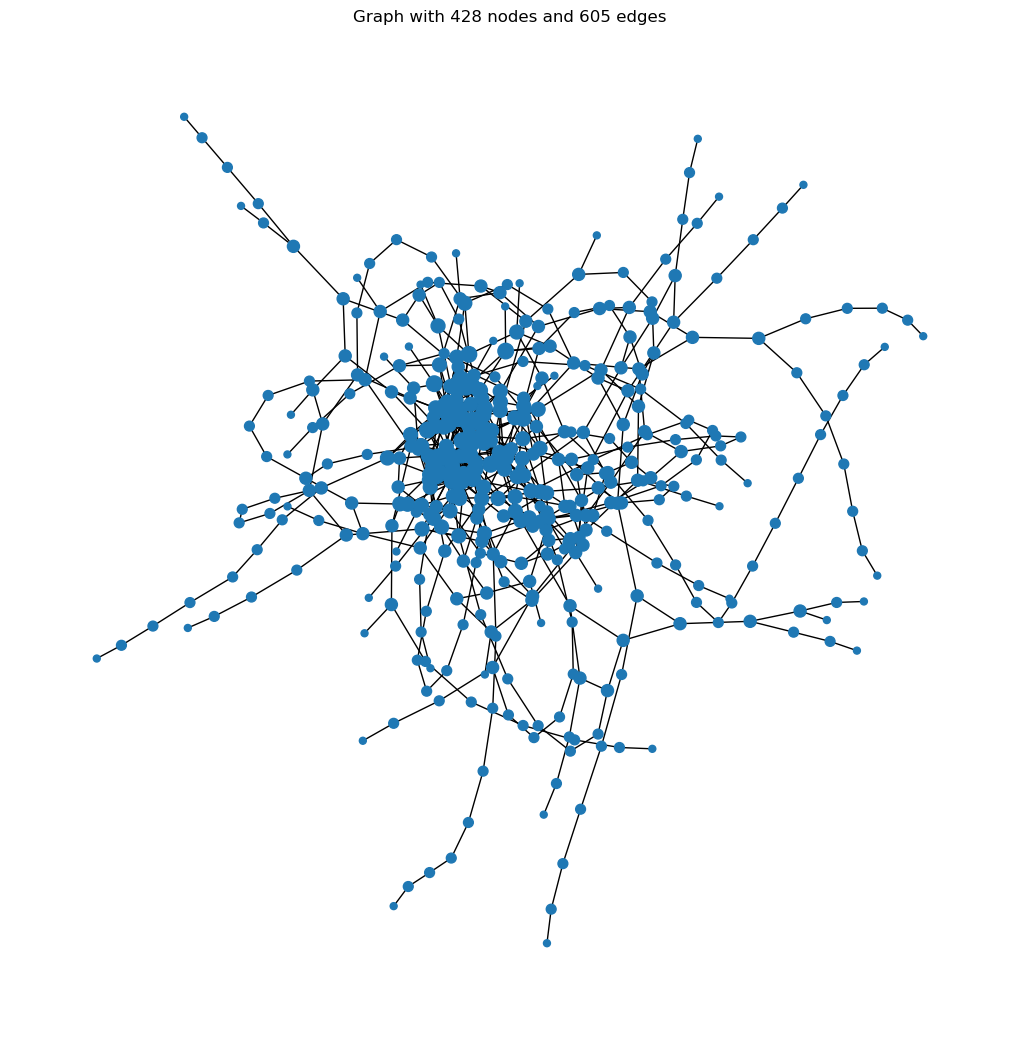

In [100]:
for component in connected_components:
    subgraph = social_network_5.subgraph(component)
    if subgraph.number_of_nodes() > 20:
        plt.figure(figsize=(10, 10))
        degrees = dict(subgraph.degree())
        node_size = [v * 25 for v in degrees.values()]
        nx.draw(subgraph, pos = nx.spring_layout(subgraph), node_size=node_size, with_labels=False) # spectral_layout, spring_layout, kamada_kawai_layout
        plt.title(subgraph)
        plt.savefig('../../reports/figures/network_structure/biggest_component_SN5.png')

        plt.show()

In [101]:
network_data['diameter_connected_components']['SN5'] = collections.Counter(diameters)

collections.Counter(diameters)

Counter({0: 283, 1: 94, 3: 5, 2: 3, 4: 2, 7: 2, 6: 2, 5: 2, 27: 1, 19: 1})

In [102]:
density = nx.density(social_network_5)
network_data['density']['SN5'] = density

density

0.0015675675675675676

In [103]:
degree_centrality = nx.degree_centrality(social_network_5)
degree_centrality

{0: 0.003003003003003003,
 1: 0.0,
 2: 0.0,
 3: 0.0,
 4: 0.001001001001001001,
 5: 0.001001001001001001,
 6: 0.003003003003003003,
 7: 0.001001001001001001,
 8: 0.001001001001001001,
 9: 0.0,
 10: 0.0,
 11: 0.0,
 12: 0.0,
 13: 0.001001001001001001,
 14: 0.0,
 15: 0.003003003003003003,
 16: 0.001001001001001001,
 17: 0.0,
 18: 0.0,
 19: 0.0,
 20: 0.001001001001001001,
 21: 0.002002002002002002,
 22: 0.0,
 23: 0.001001001001001001,
 24: 0.002002002002002002,
 25: 0.004004004004004004,
 26: 0.003003003003003003,
 27: 0.002002002002002002,
 28: 0.0,
 29: 0.0,
 30: 0.001001001001001001,
 31: 0.0,
 32: 0.004004004004004004,
 33: 0.001001001001001001,
 34: 0.0,
 35: 0.004004004004004004,
 36: 0.001001001001001001,
 37: 0.0,
 38: 0.004004004004004004,
 39: 0.0,
 40: 0.001001001001001001,
 41: 0.002002002002002002,
 42: 0.001001001001001001,
 43: 0.001001001001001001,
 44: 0.004004004004004004,
 45: 0.001001001001001001,
 46: 0.0,
 47: 0.003003003003003003,
 48: 0.001001001001001001,
 49: 0.0,


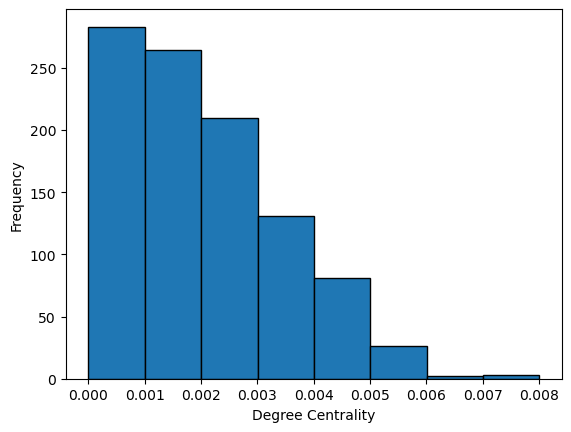

In [104]:
# Extract the values from the dictionary
values = list(degree_centrality.values())

# Create the histogram
plt.hist(values, bins=8, edgecolor='black')  # You can adjust the number of bins as needed

# Add labels and title
plt.xlabel('Degree Centrality')
plt.ylabel('Frequency')

plt.savefig('../../reports/figures/network_structure/degree_centrality_distribution_SN5.png')

# Show the plot
plt.show()

In [105]:
betweenness_centrality = nx.betweenness_centrality(social_network_5)
betweenness_centrality

{0: 0.0013003576714331559,
 1: 0.0,
 2: 0.0,
 3: 0.0,
 4: 0.0,
 5: 0.0,
 6: 0.0034701927793666823,
 7: 0.0,
 8: 0.0,
 9: 0.0,
 10: 0.0,
 11: 0.0,
 12: 0.0,
 13: 0.0,
 14: 0.0,
 15: 0.0065669995251380255,
 16: 0.0,
 17: 0.0,
 18: 0.0,
 19: 0.0,
 20: 0.0,
 21: 3.6108252541118274e-05,
 22: 0.0,
 23: 0.0,
 24: 0.0005345281286051716,
 25: 0.004124928225907957,
 26: 0.004153996828234194,
 27: 0.0005354146970713439,
 28: 0.0,
 29: 0.0,
 30: 0.0,
 31: 0.0,
 32: 0.00546980438708339,
 33: 0.0,
 34: 0.0,
 35: 0.002974139755873156,
 36: 0.0,
 37: 0.0,
 38: 0.013526433633052096,
 39: 0.0,
 40: 0.0,
 41: 8.024056120248505e-06,
 42: 0.0,
 43: 0.0,
 44: 0.006825806280270763,
 45: 0.0,
 46: 0.0,
 47: 0.001587914724154525,
 48: 0.0,
 49: 0.0,
 50: 0.0,
 51: 0.0,
 52: 0.0008545619768064658,
 53: 0.0,
 54: 0.0,
 55: 0.0,
 56: 0.0035020946849505913,
 57: 0.0,
 58: 0.0,
 59: 0.0,
 60: 0.0,
 61: 0.007372817514997302,
 62: 0.0,
 63: 0.0,
 64: 0.0,
 65: 0.0,
 66: 0.0,
 67: 0.008830934784737824,
 68: 0.0,
 69: 

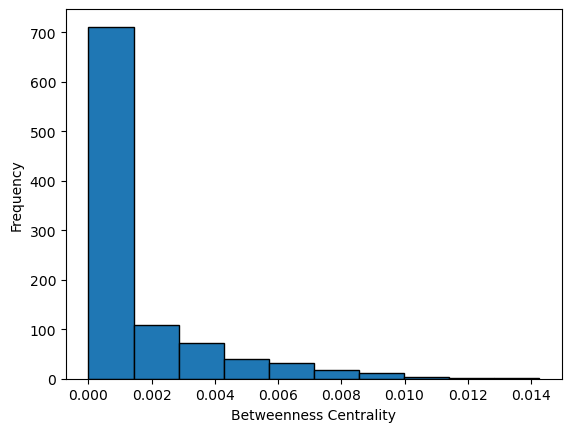

In [106]:
# Extract the values from the dictionary
values = list(betweenness_centrality.values())

# Create the histogram
plt.hist(values, bins=10, edgecolor='black')  # You can adjust the number of bins as needed

# Add labels and title
plt.xlabel('Betweenness Centrality')
plt.ylabel('Frequency')

plt.savefig('../../reports/figures/network_structure/betweenness_centrality_distribution_SN5.png')

# Show the plot
plt.show()

In [107]:
network_data

,nr_nodes,nr_edges,avg_degree,avg_clustering,density,nr_connected_components,diameter_connected_components
SN1,1000,729,1.458,0.002848,0.001459,418,"{27: 1, 1: 101, 0: 304, 3: 3, 12: 1, 8: 1, 9: ..."
SN2,1000,735,1.47,0.005042,0.001471,421,"{0: 309, 34: 1, 1: 94, 5: 4, 4: 2, 2: 7, 10: 1..."
SN3,1000,1005,2.01,0.003077,0.002012,312,"{1: 69, 24: 1, 0: 231, 2: 6, 8: 1, 5: 2, 3: 2}"
SN4,1000,854,1.708,0.001967,0.00171,368,"{24: 1, 0: 278, 5: 1, 1: 76, 4: 2, 3: 5, 8: 2,..."
SN5,1000,783,1.566,0.00319,0.001568,395,"{27: 1, 0: 283, 1: 94, 19: 1, 4: 2, 3: 5, 7: 2..."
empirical,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Social Network 6 - survey data directly

In [5]:
data_UK = pd.read_csv('../../data/raw/SCALAR_Coastal_Study_new_respondents_Wave_Five_UK.csv')
data_UK.head()

,ID,Q0_place_UK,Q1_home_NL_UK,Q4_home_size_UK,Q5_home_tenure,Q5b_home_sell,Q6_home_costs,Q7_move_in,Q8_move_out,Q12_neighborhood_trust,...,Q29h_com_what_other_p2,Q29h_com_what_other_p3,Q35_responsibility_citizens,Q35_responsibility_business,Q35_responsibility_ngo_local,Q35_responsibility_ngo_international,Q35_responsibility_gov_local,Q35_responsibility_gov_national,Q35_responsibility_w_authorities,Q35_responsibility_other
0,0,5456,4,2,2,350000,300,2015,4,3,...,NaN,NaN,0,0,0,0,0,100,0,0
1,1,5451,3,2,2,350000,3000,1998,4,4,...,NaN,NaN,0,0,0,0,50,0,50,0
2,2,6170,3,5,2,265000,300,2012,98,5,...,NaN,NaN,10,0,0,10,50,0,30,0
3,3,6101,3,6,2,550000,3000,2019,3,3,...,NaN,NaN,0,0,0,0,100,0,0,0
4,4,6160,4,6,2,385000,280,2000,2,4,...,NaN,NaN,0,0,0,0,30,35,35,0


In [6]:
connections = list(data_UK['Q27_fl_convo_people'])
connections = pd.to_numeric(connections, downcast = 'integer', errors = 'coerce')
connections

array([ nan,   5.,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,   2.,  nan,   2.,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        10.,  nan,   0.,   0.,  nan,   2.,   5.,  nan,  nan,  nan,  nan,
        nan,   1.,  nan,  20.,  nan,  nan,   0.,   0.,  nan,  nan,   7.,
        nan,  nan,  nan,   1.,  nan,  nan,   2.,  nan,  nan,  nan,   3.,
        nan,  nan,  nan,  nan,  nan,   1.,  nan,   0.,  nan,  nan, 100.,
        nan,   1.,  nan,   3.,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,   5.,   2.,  nan,
         4.,   2.,  30.,   5.,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,   0.,  nan,  nan,  10.,   1.,  nan,  nan,   1.,   5.,
        nan,  nan,  nan,   1.,  nan,  nan,  nan,   2.,  nan,   3.,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  10.,  nan,   4.,  nan,  12.,
        nan,  nan,   3.,  nan,  nan,  nan,  nan,   2.,  nan,  nan,   3.,
        nan,   1.,  nan,  nan,   1.,  nan,  nan,   

In [7]:
connections = [0 if math.isnan(x) else x for x in connections]
connections_outliers_removed = [i for i in connections if i < 100]
connections_outliers_removed = [int(x) for x in connections_outliers_removed]
connections_outliers_removed

[0,
 5,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 2,
 0,
 2,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 10,
 0,
 0,
 0,
 0,
 2,
 5,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 20,
 0,
 0,
 0,
 0,
 0,
 0,
 7,
 0,
 0,
 0,
 1,
 0,
 0,
 2,
 0,
 0,
 0,
 3,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 3,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 5,
 2,
 0,
 4,
 2,
 30,
 5,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 10,
 1,
 0,
 0,
 1,
 5,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 2,
 0,
 3,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 10,
 0,
 4,
 0,
 12,
 0,
 0,
 3,
 0,
 0,
 0,
 0,
 2,
 0,
 0,
 3,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 3,
 0,
 0,
 0,
 0,
 0,
 0,
 3,
 0,
 2,
 2,
 2,
 5,
 0,
 0,
 0,
 0,
 0,
 2,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 11,
 0,
 1,
 6,
 10,
 2,
 0,
 0,
 4,
 2,
 0,
 0,
 0,
 0,
 1,
 0,
 7,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 5,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 20,
 5,
 0,
 0,
 0,
 55,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 5,
 0,
 4,
 0,
 3,
 0,
 0,
 4,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0

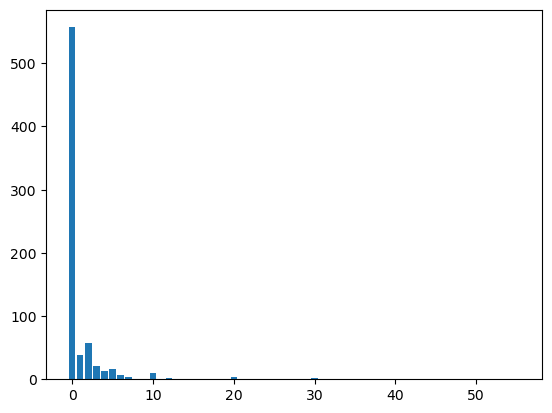

In [8]:
sorted_list = sorted(connections_outliers_removed)
sorted_counted = collections.Counter(sorted_list)

range_length = list(range(max(connections_outliers_removed))) # Get the largest value to get the range.
data_series = {}

for i in range_length:
    data_series[i] = 0 # Initialize series so that we have a template and we just have to fill in the values.

for key, value in sorted_counted.items():
    data_series[key] = value

data_series = pd.Series(data_series)
x_values = data_series.index

# you can customize the limits of the x-axis
#plt.xlim(0, 25)
#plt.ylim(0, 60)
plt.bar(x_values, data_series.values)
plt.show() 

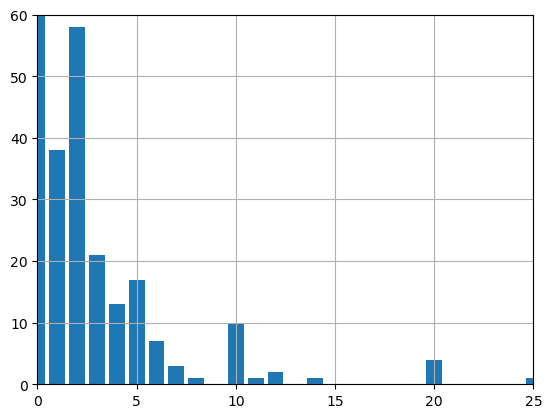

In [9]:
plt.xlim(0, 25)
plt.ylim(0, 60)
plt.grid()
plt.bar(x_values, data_series.values)
plt.show() 

In [10]:
len(connections_outliers_removed)

739

#### 1000 nodes

In [114]:
# expanding this list to have 1000 entries
nr_hh = 1000
entries_to_add = nr_hh - len(connections_outliers_removed)

extended_list = connections_outliers_removed.copy()
# Sample 250 additional entries randomly (with replacement)
extended_list += random.choices(connections_outliers_removed, k=entries_to_add)

# Verify length
print(len(extended_list))  

1000


In [115]:
# if the sum of extended list is uneven, substract 1 from the highest odd number to make it even
# this is needed for the configuration_model
if sum(extended_list) %2 != 0:
    print(sum(extended_list))
    odd_numbers = [num for num in extended_list if num % 2 != 0]
    #print(odd_numbers)
    highest_odd = max(odd_numbers)
    #print(highest_odd)
    for i in range(len(extended_list)):
        if extended_list[i] == highest_odd:
            extended_list[i] -= 1
            break
print(sum(extended_list))

1176


In [116]:
# generate network graph
network_empirical = nx.configuration_model(extended_list)
network_empirical = nx.Graph(network_empirical)
network_empirical.remove_edges_from(nx.selfloop_edges(network_empirical))
actual_degrees = [d for _, d in network_empirical.degree()]
print(network_empirical)

Graph with 1000 nodes and 539 edges


In [117]:
# rewire for preferential attachment
rewire_for_preferential_attachment(network_empirical)
print(network_empirical)

Graph with 1000 nodes and 393 edges


In [118]:
network_data['nr_nodes']['empirical'] = network_empirical.number_of_nodes()
network_data['nr_edges']['empirical'] = network_empirical.number_of_edges()
network_data

,nr_nodes,nr_edges,avg_degree,avg_clustering,density,nr_connected_components,diameter_connected_components
SN1,1000,729,1.458,0.002848,0.001459,418,"{27: 1, 1: 101, 0: 304, 3: 3, 12: 1, 8: 1, 9: ..."
SN2,1000,735,1.47,0.005042,0.001471,421,"{0: 309, 34: 1, 1: 94, 5: 4, 4: 2, 2: 7, 10: 1..."
SN3,1000,1005,2.01,0.003077,0.002012,312,"{1: 69, 24: 1, 0: 231, 2: 6, 8: 1, 5: 2, 3: 2}"
SN4,1000,854,1.708,0.001967,0.00171,368,"{24: 1, 0: 278, 5: 1, 1: 76, 4: 2, 3: 5, 8: 2,..."
SN5,1000,783,1.566,0.00319,0.001568,395,"{27: 1, 0: 283, 1: 94, 19: 1, 4: 2, 3: 5, 7: 2..."
empirical,1000,393,NaN,NaN,NaN,NaN,NaN


In [119]:
nx.write_graphml(network_empirical, "../../data/processed/network_structures/network_empirical.graphml")

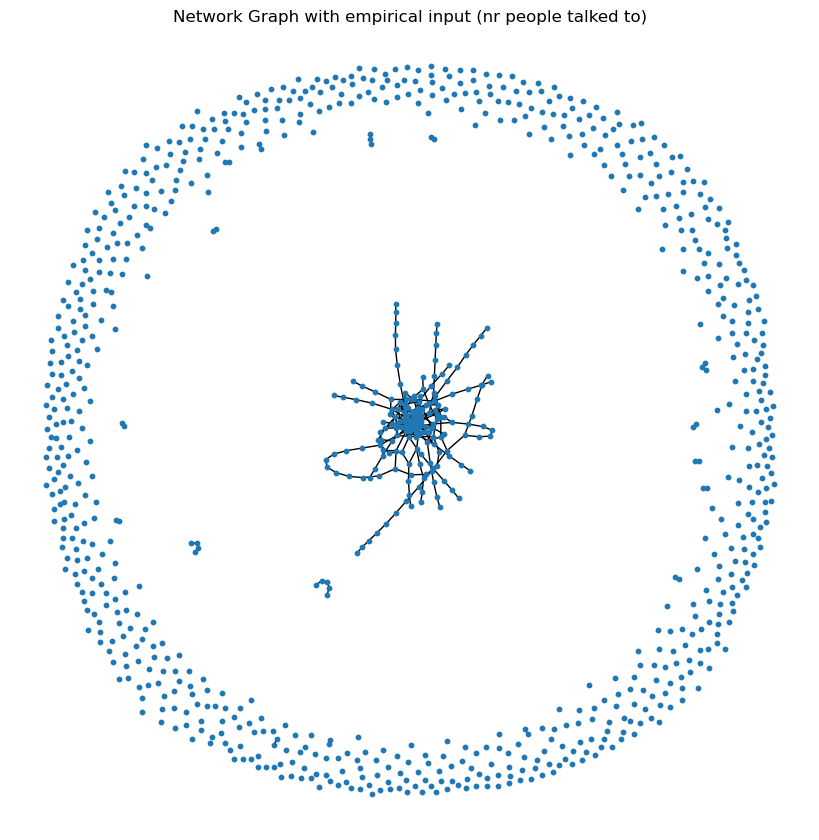

In [120]:
''' Plot of network structure'''
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(network_empirical)  # Use a spring layout for visualization
nx.draw(network_empirical, pos, node_size=10, with_labels=False)
plt.title("Network Graph with empirical input (nr people talked to)")
plt.show()

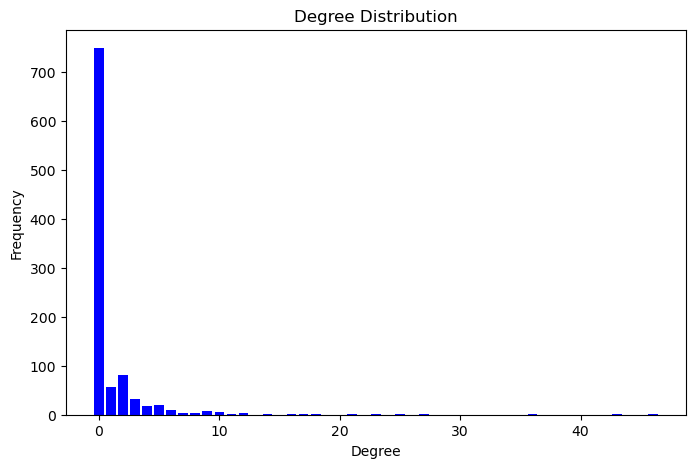

In [121]:
''' Plot of degree distribution'''
plt.figure(figsize=(8, 5))
degree_count = collections.Counter(actual_degrees)
actual_degrees, counts = zip(*degree_count.items())
plt.bar(actual_degrees, counts, color = 'b')
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.savefig('../../reports/figures/network_structure/degree_distribution_empNW.png')
plt.show()

In [122]:
is_directed = nx.is_directed(network_empirical)
num_connected_components = nx.number_connected_components(network_empirical) if not is_directed else nx.number_strongly_connected_components(network_empirical)
network_data['nr_connected_components']['empirical'] = num_connected_components
num_connected_components

768

In [123]:
connected_components = list(nx.connected_components(network_empirical)) if not is_directed else list(nx.strongly_connected_components(network_empirical))
connected_components

[{0},
 {1,
  12,
  14,
  22,
  27,
  28,
  36,
  43,
  47,
  54,
  66,
  68,
  84,
  85,
  87,
  89,
  90,
  103,
  108,
  116,
  118,
  126,
  128,
  130,
  133,
  138,
  141,
  146,
  150,
  157,
  159,
  160,
  161,
  162,
  168,
  182,
  185,
  186,
  187,
  190,
  196,
  198,
  206,
  216,
  218,
  219,
  223,
  232,
  234,
  236,
  239,
  248,
  249,
  261,
  267,
  268,
  275,
  286,
  291,
  294,
  296,
  299,
  308,
  310,
  312,
  314,
  318,
  323,
  333,
  336,
  347,
  352,
  363,
  366,
  371,
  379,
  383,
  385,
  389,
  399,
  408,
  411,
  414,
  418,
  421,
  424,
  433,
  434,
  437,
  441,
  457,
  458,
  467,
  470,
  475,
  476,
  478,
  486,
  492,
  510,
  511,
  516,
  522,
  523,
  524,
  536,
  538,
  539,
  542,
  557,
  562,
  564,
  566,
  569,
  571,
  572,
  574,
  577,
  582,
  589,
  600,
  602,
  604,
  605,
  607,
  613,
  619,
  620,
  622,
  627,
  639,
  641,
  643,
  652,
  653,
  654,
  658,
  675,
  676,
  689,
  690,
  697,
  698,
  706,
  71

In [124]:
degree_sequence = [d for n, d in network_empirical.degree()]
avg_degree = sum(degree_sequence) / network_empirical.number_of_nodes()
network_data['avg_degree']['empirical'] = avg_degree
avg_degree

0.786

In [125]:
avg_clustering = nx.average_clustering(network_empirical)
network_data['avg_clustering']['empirical'] = avg_clustering
avg_clustering

0.007721428571428572

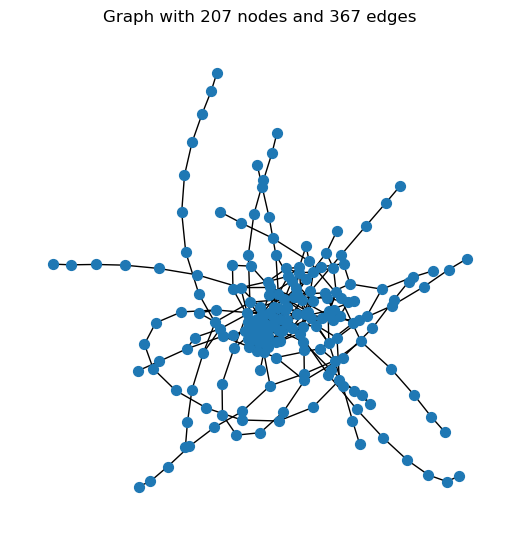

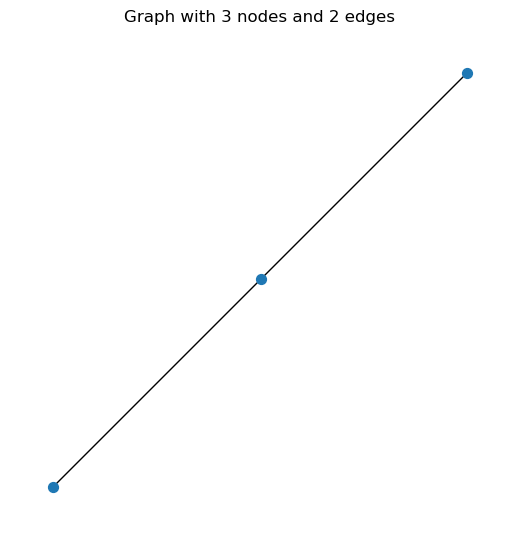

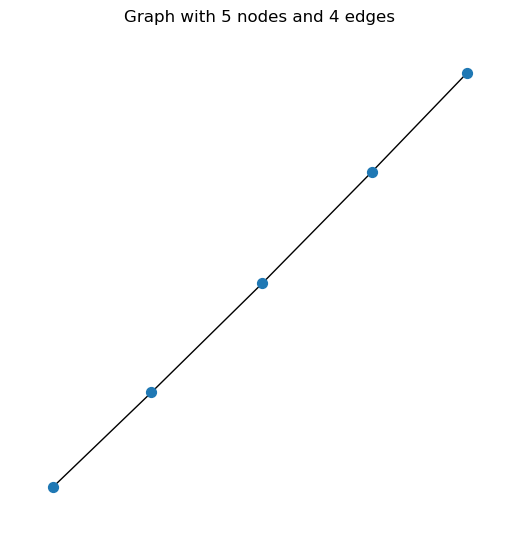

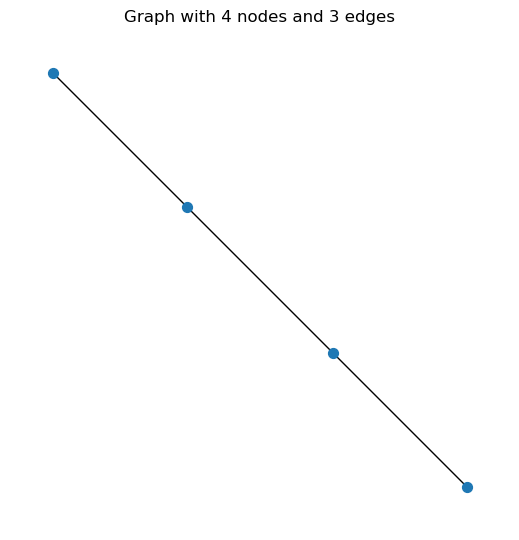

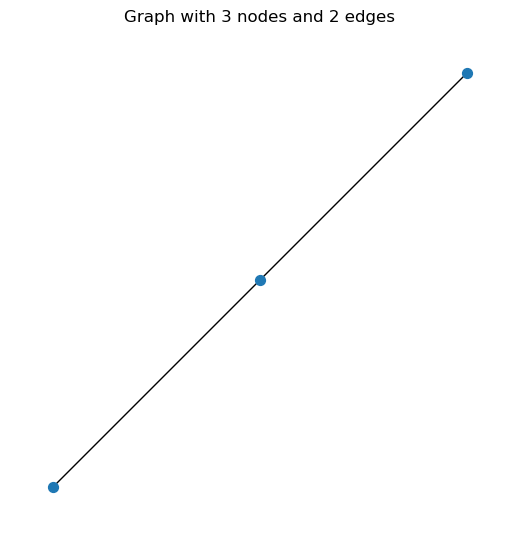

In [126]:
diameters = []
for component in connected_components:
    subgraph = network_empirical.subgraph(component)
    if subgraph.number_of_nodes() > 2:
        plt.figure(figsize=(5, 5))
        pos = nx.spring_layout(subgraph)  # Use a spring layout for visualization
        nx.draw(subgraph, node_size=50, with_labels=False)
        plt.title(subgraph)
        plt.show()
        #print(subgraph)
    if nx.is_connected(subgraph):  # Ensure the subgraph is connected
        diameters.append(nx.diameter(subgraph))

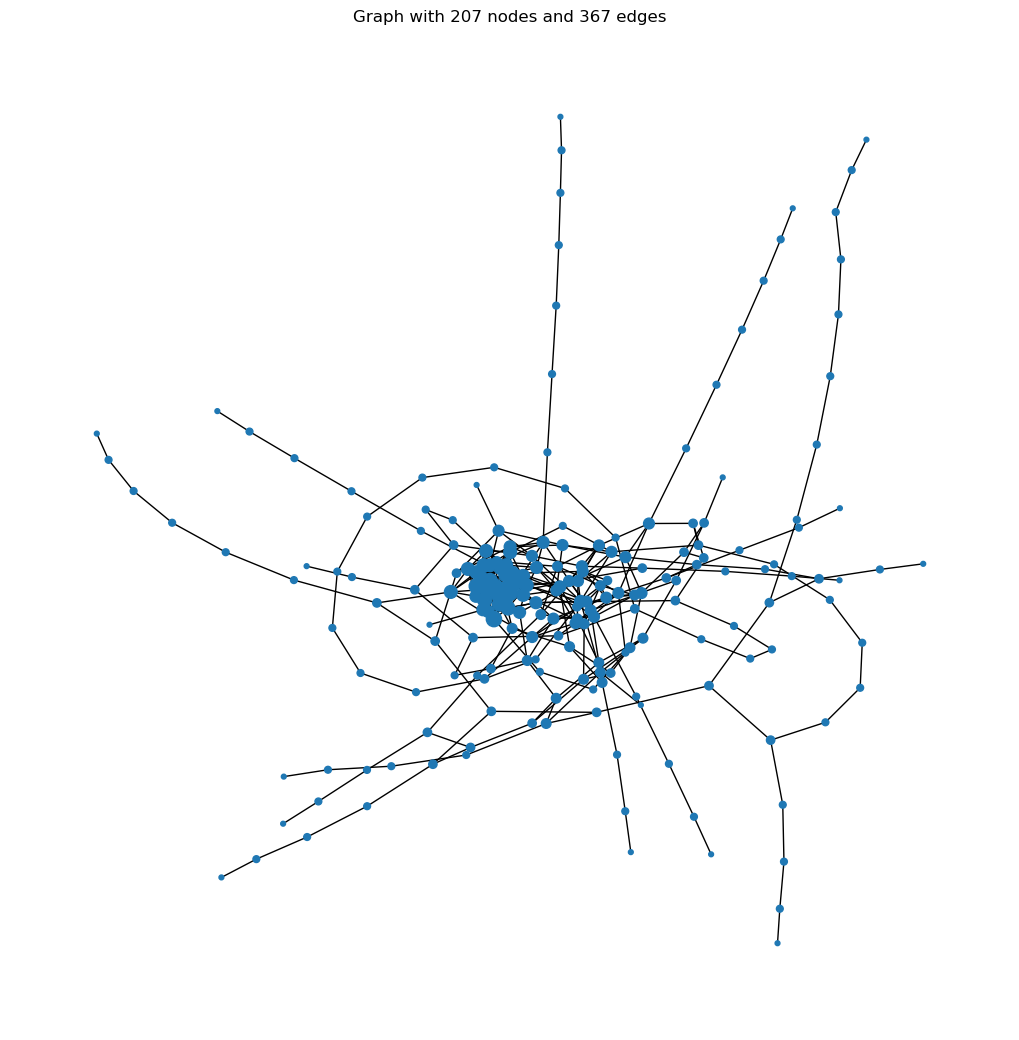

In [127]:
for component in connected_components:
    subgraph = network_empirical.subgraph(component)
    if subgraph.number_of_nodes() > 20:
        biggest_subgraph = subgraph
        plt.figure(figsize=(10, 10))
        degrees = dict(subgraph.degree())
        node_size = [v * 12 for v in degrees.values()]
        nx.draw(subgraph, pos = nx.spring_layout(subgraph), node_size=node_size, with_labels=False) # spectral_layout, spring_layout, kamada_kawai_layout
        plt.title(subgraph)
        plt.savefig('../../reports/figures/network_structure/biggest_component_empNW.png')
        plt.show()

In [128]:
network_data['diameter_connected_components']['empirical'] = collections.Counter(diameters)
collections.Counter(diameters)

Counter({0: 748, 1: 15, 2: 2, 22: 1, 4: 1, 3: 1})

In [129]:
density = nx.density(network_empirical)
network_data['density']['empirical'] = density
density

0.0007867867867867868

In [130]:
degree_centrality = nx.degree_centrality(network_empirical)
degree_centrality

{0: 0.0,
 1: 0.005005005005005005,
 2: 0.0,
 3: 0.0,
 4: 0.0,
 5: 0.0,
 6: 0.0,
 7: 0.0,
 8: 0.0,
 9: 0.0,
 10: 0.0,
 11: 0.0,
 12: 0.002002002002002002,
 13: 0.0,
 14: 0.002002002002002002,
 15: 0.0,
 16: 0.0,
 17: 0.0,
 18: 0.0,
 19: 0.0,
 20: 0.0,
 21: 0.0,
 22: 0.006006006006006006,
 23: 0.0,
 24: 0.0,
 25: 0.0,
 26: 0.0,
 27: 0.002002002002002002,
 28: 0.004004004004004004,
 29: 0.0,
 30: 0.0,
 31: 0.0,
 32: 0.0,
 33: 0.0,
 34: 0.001001001001001001,
 35: 0.0,
 36: 0.01001001001001001,
 37: 0.0,
 38: 0.0,
 39: 0.0,
 40: 0.0,
 41: 0.0,
 42: 0.0,
 43: 0.005005005005005005,
 44: 0.0,
 45: 0.0,
 46: 0.0,
 47: 0.001001001001001001,
 48: 0.0,
 49: 0.0,
 50: 0.001001001001001001,
 51: 0.0,
 52: 0.0,
 53: 0.0,
 54: 0.003003003003003003,
 55: 0.0,
 56: 0.0,
 57: 0.0,
 58: 0.0,
 59: 0.0,
 60: 0.001001001001001001,
 61: 0.0,
 62: 0.0,
 63: 0.0,
 64: 0.0,
 65: 0.0,
 66: 0.001001001001001001,
 67: 0.0,
 68: 0.003003003003003003,
 69: 0.0,
 70: 0.0,
 71: 0.0,
 72: 0.0,
 73: 0.0,
 74: 0.0,
 75: 0

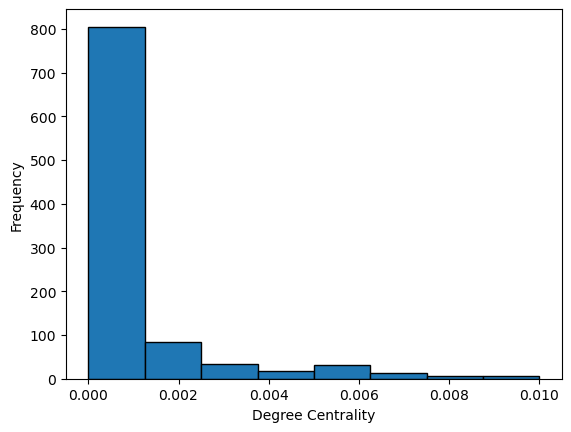

In [131]:
# Extract the values from the dictionary
values = list(degree_centrality.values())

# Create the histogram
plt.hist(values, bins=8, edgecolor='black')  # You can adjust the number of bins as needed

# Add labels and title
plt.xlabel('Degree Centrality')
plt.ylabel('Frequency')

plt.savefig('../../reports/figures/network_structure/degree_centrality_distribution_empNW.png')
# Show the plot
plt.show()

In [132]:
betweenness_centrality = nx.betweenness_centrality(network_empirical)
betweenness_centrality

{0: 0.0,
 1: 0.0017135033919270194,
 2: 0.0,
 3: 0.0,
 4: 0.0,
 5: 0.0,
 6: 0.0,
 7: 0.0,
 8: 0.0,
 9: 0.0,
 10: 0.0,
 11: 0.0,
 12: 0.0004112328761627359,
 13: 0.0,
 14: 0.001620859336290198,
 15: 0.0,
 16: 0.0,
 17: 0.0,
 18: 0.0,
 19: 0.0,
 20: 0.0,
 21: 0.0,
 22: 0.0012287999936851735,
 23: 0.0,
 24: 0.0,
 25: 0.0,
 26: 0.0,
 27: 0.001063756970013928,
 28: 0.0011034040593158837,
 29: 0.0,
 30: 0.0,
 31: 0.0,
 32: 0.0,
 33: 0.0,
 34: 0.0,
 35: 0.0,
 36: 0.000786014523882417,
 37: 0.0,
 38: 0.0,
 39: 0.0,
 40: 0.0,
 41: 0.0,
 42: 0.0,
 43: 0.001531117327329636,
 44: 0.0,
 45: 0.0,
 46: 0.0,
 47: 0.0,
 48: 0.0,
 49: 0.0,
 50: 0.0,
 51: 0.0,
 52: 0.0,
 53: 0.0,
 54: 0.000736700982469587,
 55: 0.0,
 56: 0.0,
 57: 0.0,
 58: 0.0,
 59: 0.0,
 60: 0.0,
 61: 0.0,
 62: 0.0,
 63: 0.0,
 64: 0.0,
 65: 0.0,
 66: 0.0,
 67: 0.0,
 68: 0.0015699835895783341,
 69: 0.0,
 70: 0.0,
 71: 0.0,
 72: 0.0,
 73: 0.0,
 74: 0.0,
 75: 0.0,
 76: 0.0,
 77: 0.0,
 78: 0.0,
 79: 0.0,
 80: 0.0,
 81: 0.0,
 82: 0.0,
 83: 

In [133]:
betweenness_values = []
for i in betweenness_centrality:
    betweenness_values.append(betweenness_centrality[i])

betweenness_centrality_non_0 = [x for x in betweenness_values if x != 0]
print(len(betweenness_values), len(betweenness_centrality_non_0))

1000 195


In [134]:
print('max', max(betweenness_centrality_non_0))
print('min', min(betweenness_centrality_non_0))
print('avg', mean(betweenness_centrality_non_0))
print('median', median(betweenness_centrality_non_0))


max 0.004659077257066644
min 2.0060140300621263e-06
avg 0.0012347067791289568
median 0.0008532170742866646


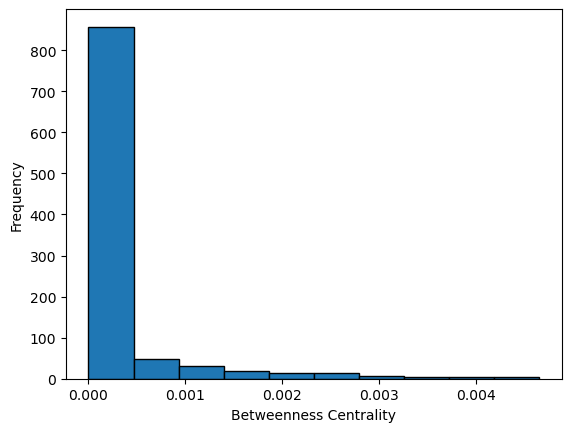

In [135]:
# Extract the values from the dictionary
values = list(betweenness_centrality.values())

# Create the histogram
plt.hist(values, bins=10, edgecolor='black')  # You can adjust the number of bins as needed

# Add labels and title
plt.xlabel('Betweenness Centrality')
plt.ylabel('Frequency')

plt.savefig('../../reports/figures/network_structure/betweenness_centrality_distribution_empNW.png')
# Show the plot
plt.show()

In [136]:
# degree assortivity
r = nx.degree_pearson_correlation_coefficient(network_empirical)
r

0.8489584667811113

#### 500 nodes

In [11]:
# shrinking this list to have 500 entries
nr_hh = 500
entries_to_remove = abs(nr_hh - len(connections_outliers_removed))

shortened_list = connections_outliers_removed.copy()
# Remove random entries
indices_to_remove = random.sample(range(len(shortened_list)), entries_to_remove)

for index in sorted(indices_to_remove, reverse=True):
    del shortened_list[index]

# Verify length
print(len(shortened_list))  

500


In [12]:
# if the sum of extended list is uneven, substract 1 from the highest odd number to make it even
# this is needed for the configuration_model
if sum(shortened_list) %2 != 0:
    print(sum(shortened_list))
    odd_numbers = [num for num in shortened_list if num % 2 != 0]
    #print(odd_numbers)
    highest_odd = max(odd_numbers)
    #print(highest_odd)
    for i in range(len(shortened_list)):
        if shortened_list[i] == highest_odd:
            shortened_list[i] -= 1
            break
print(sum(shortened_list))

614


In [13]:
# generate network graph
network_empirical_500 = nx.configuration_model(shortened_list)
network_empirical_500 = nx.Graph(network_empirical_500)
network_empirical_500.remove_edges_from(nx.selfloop_edges(network_empirical_500))
actual_degrees = [d for _, d in network_empirical_500.degree()]
print(network_empirical_500)

Graph with 500 nodes and 262 edges


In [14]:
# rewire for preferential attachment
rewire_for_preferential_attachment(network_empirical_500)
print(network_empirical_500)

Graph with 500 nodes and 173 edges


In [15]:
nx.write_graphml(network_empirical_500, "../../data/processed/network_structures/network_empirical_500.graphml")

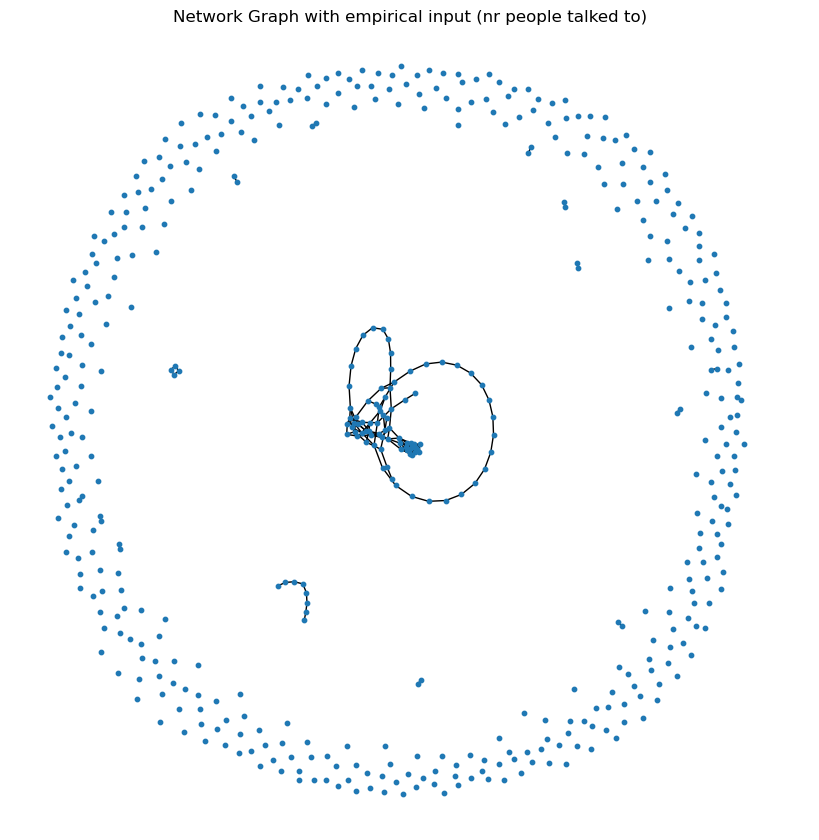

In [16]:
''' Plot of network structure'''
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(network_empirical_500)  # Use a spring layout for visualization
nx.draw(network_empirical_500, pos, node_size=10, with_labels=False)
plt.title("Network Graph with empirical input (nr people talked to)")
plt.show()

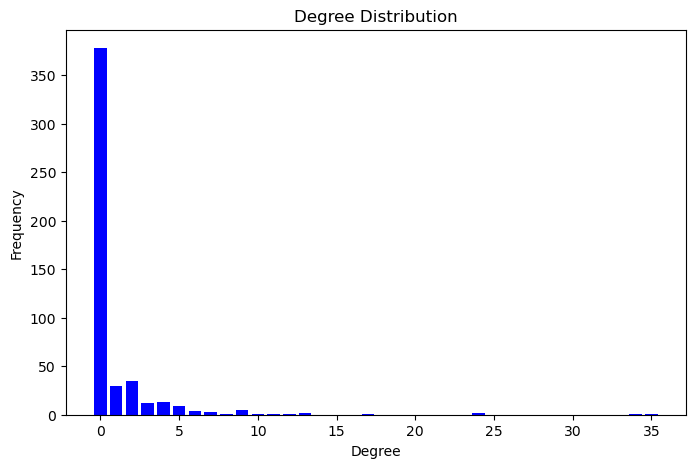

In [17]:
''' Plot of degree distribution'''
plt.figure(figsize=(8, 5))
degree_count = collections.Counter(actual_degrees)
actual_degrees, counts = zip(*degree_count.items())
plt.bar(actual_degrees, counts, color = 'b')
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.savefig('../../reports/figures/network_structure/degree_distribution_empNW_500.png')
plt.show()

In [18]:
is_directed = nx.is_directed(network_empirical_500)
num_connected_components = nx.number_connected_components(network_empirical_500) if not is_directed else nx.number_strongly_connected_components(network_empirical_500)
# network_data['nr_connected_components']['empirical'] = num_connected_components
num_connected_components

394

In [19]:
connected_components = list(nx.connected_components(network_empirical_500)) if not is_directed else list(nx.strongly_connected_components(network_empirical_500))
connected_components

[{0},
 {1,
  6,
  14,
  18,
  27,
  30,
  35,
  45,
  54,
  56,
  58,
  59,
  68,
  78,
  83,
  85,
  87,
  93,
  95,
  107,
  108,
  121,
  122,
  140,
  141,
  143,
  151,
  154,
  173,
  177,
  181,
  195,
  205,
  211,
  214,
  222,
  229,
  231,
  241,
  246,
  250,
  251,
  252,
  256,
  264,
  278,
  281,
  285,
  291,
  301,
  302,
  312,
  316,
  319,
  327,
  344,
  353,
  362,
  363,
  366,
  375,
  379,
  380,
  383,
  384,
  386,
  388,
  392,
  404,
  406,
  409,
  414,
  415,
  419,
  428,
  437,
  441,
  442,
  461,
  462,
  467,
  475,
  486,
  491},
 {2},
 {3},
 {4},
 {5},
 {7},
 {8},
 {9},
 {10},
 {11},
 {12},
 {13},
 {15},
 {16},
 {17},
 {19},
 {20},
 {21, 206},
 {22},
 {23},
 {24},
 {25},
 {26},
 {28},
 {29},
 {31},
 {32},
 {33},
 {34},
 {36},
 {37},
 {38},
 {39},
 {40},
 {41},
 {42},
 {43},
 {44, 496},
 {46},
 {47},
 {48},
 {49},
 {50},
 {51},
 {52},
 {53},
 {55},
 {57, 189, 275, 317},
 {60},
 {61},
 {62},
 {63},
 {64},
 {65},
 {66},
 {67},
 {69, 436},
 {70},
 {71

In [21]:
degree_sequence = [d for n, d in network_empirical_500.degree()]
avg_degree = sum(degree_sequence) / network_empirical_500.number_of_nodes()
# network_data['avg_degree']['empirical'] = avg_degree
avg_degree

0.692

In [22]:
avg_clustering = nx.average_clustering(network_empirical_500)
# network_data['avg_clustering']['empirical'] = avg_clustering
avg_clustering

0.014011111111111111

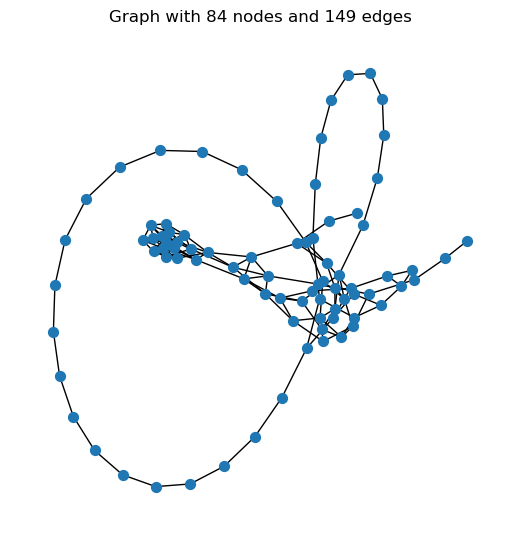

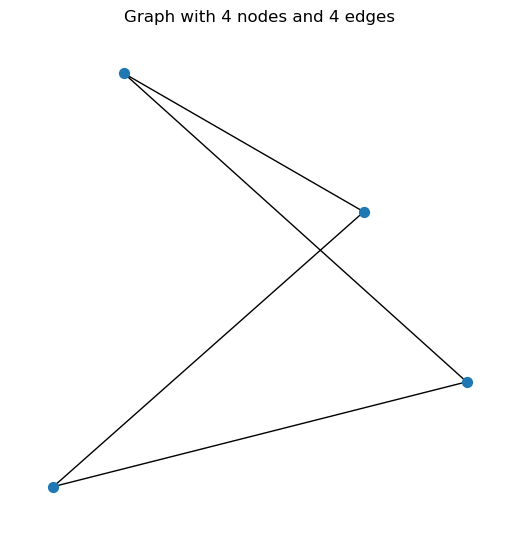

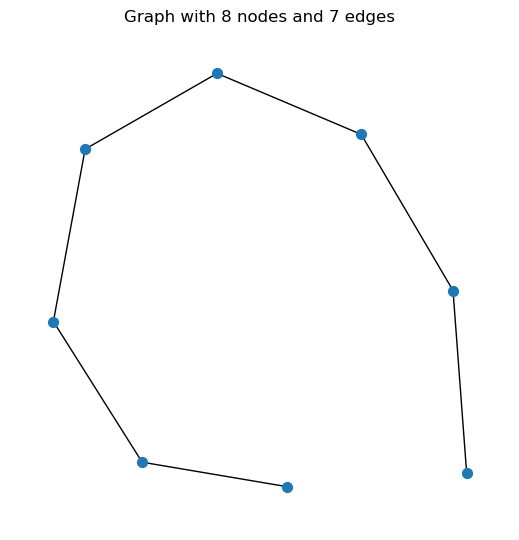

In [23]:
diameters = []
for component in connected_components:
    subgraph = network_empirical_500.subgraph(component)
    if subgraph.number_of_nodes() > 2:
        plt.figure(figsize=(5, 5))
        pos = nx.spring_layout(subgraph)  # Use a spring layout for visualization
        nx.draw(subgraph, node_size=50, with_labels=False)
        plt.title(subgraph)
        plt.show()
        #print(subgraph)
    if nx.is_connected(subgraph):  # Ensure the subgraph is connected
        diameters.append(nx.diameter(subgraph))

In [24]:
# network_data['diameter_connected_components']['empirical'] = collections.Counter(diameters)
collections.Counter(diameters)

Counter({0: 378, 1: 13, 17: 1, 2: 1, 7: 1})

In [26]:
density = nx.density(network_empirical_500)
# network_data['density']['empirical'] = density
density

0.0013867735470941883

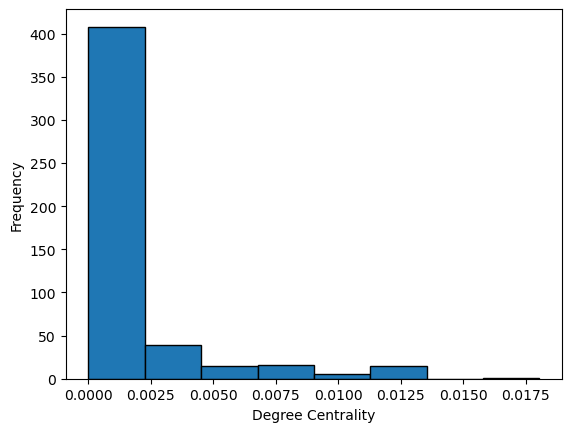

In [28]:
degree_centrality = nx.degree_centrality(network_empirical_500)

# Extract the values from the dictionary
values = list(degree_centrality.values())

# Create the histogram
plt.hist(values, bins=8, edgecolor='black')  # You can adjust the number of bins as needed

# Add labels and title
plt.xlabel('Degree Centrality')
plt.ylabel('Frequency')

plt.savefig('../../reports/figures/network_structure/degree_centrality_distribution_empNW_500.png')
# Show the plot
plt.show()

In [29]:
betweenness_centrality = nx.betweenness_centrality(network_empirical_500)
betweenness_values = []
for i in betweenness_centrality:
    betweenness_values.append(betweenness_centrality[i])

betweenness_centrality_non_0 = [x for x in betweenness_values if x != 0]
print(len(betweenness_values), len(betweenness_centrality_non_0))

500 92


In [30]:
print('max', max(betweenness_centrality_non_0))
print('min', min(betweenness_centrality_non_0))
print('avg', mean(betweenness_centrality_non_0))
print('median', median(betweenness_centrality_non_0))

max 0.007354367209718956
min 4.024112481992097e-06
avg 0.0016488363491431964
median 0.0013471585282278185


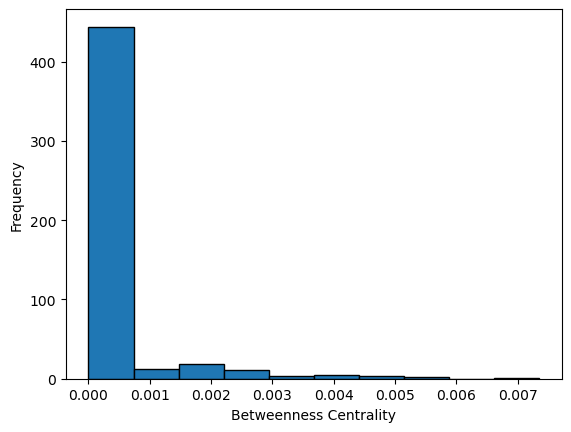

In [31]:
# Extract the values from the dictionary
values = list(betweenness_centrality.values())

# Create the histogram
plt.hist(values, bins=10, edgecolor='black')  # You can adjust the number of bins as needed

# Add labels and title
plt.xlabel('Betweenness Centrality')
plt.ylabel('Frequency')

plt.savefig('../../reports/figures/network_structure/betweenness_centrality_distribution_empNW_500.png')
# Show the plot
plt.show()

In [32]:
# degree assortivity
r = nx.degree_pearson_correlation_coefficient(network_empirical_500)
r

0.8966286679924189

#### 150 nodes

In [33]:
# shrinking this list to have 150 entries
nr_hh = 150
entries_to_remove = abs(nr_hh - len(connections_outliers_removed))

shortened_list = connections_outliers_removed.copy()
# Remove random entries
indices_to_remove = random.sample(range(len(shortened_list)), entries_to_remove)

for index in sorted(indices_to_remove, reverse=True):
    del shortened_list[index]

# Verify length
print(len(shortened_list))  

150


In [34]:
# if the sum of extended list is uneven, substract 1 from the highest odd number to make it even
# this is needed for the configuration_model
if sum(shortened_list) %2 != 0:
    print(sum(shortened_list))
    odd_numbers = [num for num in shortened_list if num % 2 != 0]
    #print(odd_numbers)
    highest_odd = max(odd_numbers)
    #print(highest_odd)
    for i in range(len(shortened_list)):
        if shortened_list[i] == highest_odd:
            shortened_list[i] -= 1
            break
print(sum(shortened_list))

172


In [35]:
# generate network graph
network_empirical_150 = nx.configuration_model(shortened_list)
network_empirical_150 = nx.Graph(network_empirical_150)
network_empirical_150.remove_edges_from(nx.selfloop_edges(network_empirical_150))
actual_degrees = [d for _, d in network_empirical_150.degree()]
print(network_empirical_150)

Graph with 150 nodes and 71 edges


In [36]:
# rewire for preferential attachment
rewire_for_preferential_attachment(network_empirical_150)
print(network_empirical_150)

Graph with 150 nodes and 39 edges


In [37]:
nx.write_graphml(network_empirical_150, "../../data/processed/network_structures/network_empirical_150.graphml")

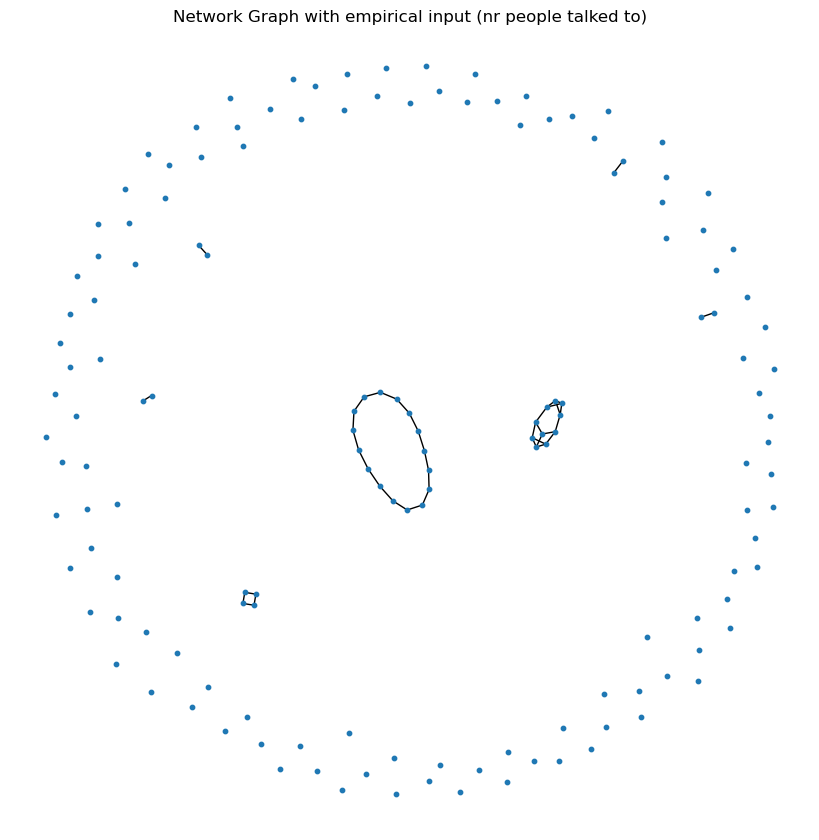

In [39]:
''' Plot of network structure'''
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(network_empirical_150)  # Use a spring layout for visualization
nx.draw(network_empirical_150, pos, node_size=10, with_labels=False)
plt.title("Network Graph with empirical input (nr people talked to)")
plt.show()

### netowkr data

In [137]:
network_data

,nr_nodes,nr_edges,avg_degree,avg_clustering,density,nr_connected_components,diameter_connected_components
SN1,1000,729,1.458,0.002848,0.001459,418,"{27: 1, 1: 101, 0: 304, 3: 3, 12: 1, 8: 1, 9: ..."
SN2,1000,735,1.47,0.005042,0.001471,421,"{0: 309, 34: 1, 1: 94, 5: 4, 4: 2, 2: 7, 10: 1..."
SN3,1000,1005,2.01,0.003077,0.002012,312,"{1: 69, 24: 1, 0: 231, 2: 6, 8: 1, 5: 2, 3: 2}"
SN4,1000,854,1.708,0.001967,0.00171,368,"{24: 1, 0: 278, 5: 1, 1: 76, 4: 2, 3: 5, 8: 2,..."
SN5,1000,783,1.566,0.00319,0.001568,395,"{27: 1, 0: 283, 1: 94, 19: 1, 4: 2, 3: 5, 7: 2..."
empirical,1000,393,0.786,0.007721,0.000787,768,"{0: 748, 22: 1, 1: 15, 2: 2, 4: 1, 3: 1}"


In [138]:
network_data.to_csv('../../reports/tables/network_statistics.csv')

##### Looking at biggest subgraph

In [148]:
print(biggest_subgraph)

Graph with 207 nodes and 367 edges


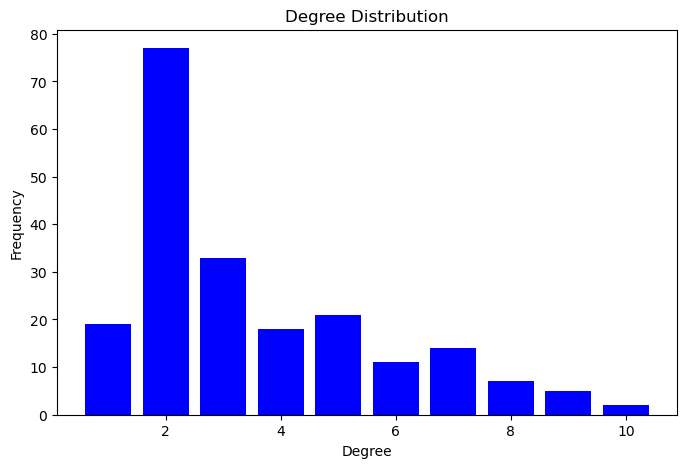

In [149]:
biggest_subgraph_degrees = [d for _, d in biggest_subgraph.degree()]

plt.figure(figsize=(8, 5))
degree_count = collections.Counter(biggest_subgraph_degrees)
biggest_subgraph_degrees, counts = zip(*degree_count.items())
plt.bar(biggest_subgraph_degrees, counts, color = 'b')
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
#plt.savefig('figures/degree_distribution_empNW.png')
plt.show()

In [150]:
degree_sequence = [d for n, d in biggest_subgraph.degree()]
avg_degree = sum(degree_sequence) / biggest_subgraph.number_of_nodes()
avg_degree

3.5458937198067635

In [151]:
avg_clustering = nx.average_clustering(biggest_subgraph)
avg_clustering

0.0373015873015873

In [152]:
diameter = nx.diameter(biggest_subgraph)
diameter

22

In [153]:
density = nx.density(biggest_subgraph)
density

0.01721307630974157

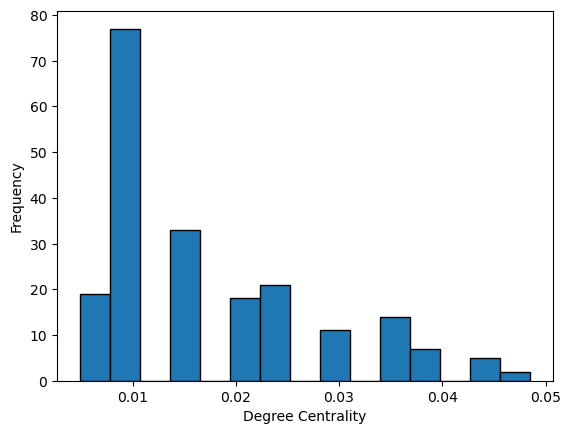

In [157]:
degree_centrality = nx.degree_centrality(biggest_subgraph)
# Extract the values from the dictionary
values = list(degree_centrality.values())

# Create the histogram
plt.hist(values, bins=15, edgecolor='black')  # You can adjust the number of bins as needed

# Add labels and title
plt.xlabel('Degree Centrality')
plt.ylabel('Frequency')

#plt.savefig('figures/degree_centrality_distribution_empNW.png')
# Show the plot
plt.show()

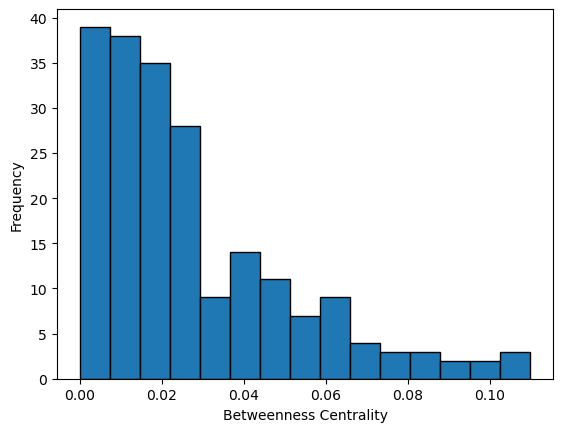

In [159]:
betweenness_centrality = nx.betweenness_centrality(biggest_subgraph)

# Extract the values from the dictionary
values = list(betweenness_centrality.values())

# Create the histogram
plt.hist(values, bins=15, edgecolor='black')  # You can adjust the number of bins as needed

# Add labels and title
plt.xlabel('Betweenness Centrality')
plt.ylabel('Frequency')

#plt.savefig('figures/betweenness_centrality_distribution_empNW.png')
# Show the plot
plt.show()

In [160]:
# degree assortivity
r = nx.degree_pearson_correlation_coefficient(biggest_subgraph)
r

0.8285152565085916

0.8489584667811113